<a href="https://colab.research.google.com/github/roman-burdakov/MIT-HandsOnDeepLearning/blob/main/final_project/box_office_prediction_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 15.773 Hands-on Deep Learning — Spring 2026  
#### Roman Burdakov, Abdul Rehman, Lindsay Yu, Daniel Menard, Vipin Myneni

## Box Office Prediction v2: Multimodal Forecasting of Opening Weekend Revenue

This notebook presents a deep learning project on forecasting **U.S. domestic opening weekend box office** before release using a combination of structured movie metadata and pre-release social-media signals.

The project draws on ideas discussed in class, especially:
- **transfer learning** for text representation,
- **multimodal modeling** across tabular and text inputs,
- **Transformer-based modeling** for selected text and late-fusion architectures,
- **hyperparameter tuning and model comparison** to refine performance across candidate approaches,
- and retrieval-inspired similarity features based on comparable historical movies

It is designed to run in both **Google Colab** and **local notebook environments**.

Data for this project was collected through [Box Office Mojo](https://www.boxofficemojo.com/) website scraping, the [TMDB API](https://www.themoviedb.org/documentation/api), and the [YouTube Data API v3](https://developers.google.com/youtube/v3).

## Problem Statement

The goal of this project is to forecast **domestic opening weekend box office** for movies before release using pre-release audience signals from YouTube and related movie metadata (we also experimented with getting Reddit threads, but didn't complete that part, so left it aside for now)

The motivation is that traditional forecasting approaches based only on historical comparables and structured metadata can miss real-time shifts in audience awareness, engagement, and intent. Social and trailer-related signals may capture these dynamics earlier and more directly.

We frame this as a supervised regression problem and study whether social text and engagement features materially improve predictive accuracy over a metadata-only baseline. Model performance is evaluated on a held-out test set, with **R² and MAE in log space used as the primary comparison metrics**, and dollar-space error metrics used as a secondary calibration check.

## Approach

Our approach combines multiple sources of pre-release information into a unified modeling pipeline.

### 1. Structured movie metadata
We use structured features describing each film, such as release timing, genre, distributor, language, runtime, and other pre-release metadata that may influence opening weekend performance.

### 2. Trailer and text-based features
We incorporate textual information derived from movie descriptions, trailer metadata, and related text fields. Pre-trained text embeddings are used to capture semantic content without relying only on manual feature engineering.

### 3. YouTube comment and engagement signals
We use YouTube-based pre-release signals to approximate audience attention and reaction before theatrical release. These include engagement indicators as well as sentiment-oriented summaries derived from user comments.

### 4. Retrieval-inspired similarity features
To complement raw metadata and text, we construct similarity-based features intended to reflect how a new movie relates to historically comparable titles. These features serve as lightweight retrieval-augmented signals.

### 5. Transformer architectures and multimodal learning
In addition to standard baselines, we experiment with **Transformer-based architectures** to model richer interactions across text-derived inputs. We also compare multimodal neural networks that combine tabular and text features through separate branches and late-fusion designs.

### 6. Hyperparameter tuning and model comparison
We use targeted **hyperparameter tuning** to refine model settings across neural and tree-based approaches, including architecture size, regularization, learning rate, and batch size. This allows us to compare model families systematically and identify which combinations of features and modeling choices are most effective.

The overall goal is to understand not only which model performs best, but also which categories of features contribute the most useful predictive signal for pre-release box office forecasting.


## 1. Environment Setup & Install Dependencies (Colab only)



In [ ]:
# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("🌐 Running in Google Colab")
except:
    IN_COLAB = False
    print("💻 Running locally")

if IN_COLAB:
    print("Installing required packages...")
    import sys, subprocess
    packages = [
        "sentence-transformers",
        "transformers",
        "datasets",
        "accelerate",
        "tensorflow",
        "torch",
        "pandas",
        "numpy",
        "matplotlib",
        "seaborn",
        "scikit-learn",
        "xgboost",
        "vaderSentiment",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
    print("✓ Packages installed")
else:
    print("Skipping installation (local environment)")
    print("Ensure you have: sentence-transformers, transformers, datasets, tensorflow, torch")

COMMENT_EMBED_DEFAULTS = {
    True: {   # Colab / GPU-friendly
        "k": 32,
        "max_scan": 1500,
        "max_comment_chars_for_embed": 256,
        "max_comment_chars_for_sent": 192,
        "embed_batch_size": 128,
        "sent_infer_batch_size": 256,
        "description_batch_size": 256,
    },
    False: {  # laptop / CPU-friendly
        "k": 12,
        "max_scan": 400,
        "max_comment_chars_for_embed": 160,
        "max_comment_chars_for_sent": 128,
        "embed_batch_size": 8,
        "sent_infer_batch_size": 16,
        "description_batch_size": 32,
    },
}

def get_comment_embed_defaults(in_colab=None):
    if in_colab is None:
        in_colab = IN_COLAB
    return COMMENT_EMBED_DEFAULTS[bool(in_colab)].copy()

def get_embed_dim(embedder, fallback_dim=None):
    try:
        dim = embedder.get_sentence_embedding_dimension()
        if dim is not None:
            return int(dim)
    except Exception:
        pass
    return int(fallback_dim if fallback_dim is not None else EMB_DIM)

def zero_embedding(embedder, fallback_dim=None):
    return np.zeros(get_embed_dim(embedder, fallback_dim), dtype=np.float32)

def safe_ts_sort_value(ts):
    s = to_epoch_seconds(ts)
    if s is None:
        return 10**18
    return int(s)

🌐 Running in Google Colab
Installing required packages...
✓ Packages installed


## 2. Imports & Data Loading Setup. Flexible for Colab/Local



In [ ]:
import os, sys, gc, re, gzip
import random, hashlib, json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from datetime import datetime, timezone, timedelta
import math, ast
from scipy.stats import wilcoxon, spearmanr
from glob import glob
from typing import Optional
from tqdm.notebook import tqdm
import heapq
from heapq import nsmallest
from itertools import product

# Deep Learning
import torch
from datasets import Dataset
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
import tensorflow as tf
from tensorflow import keras
from keras import layers, models, callbacks, regularizers
from keras.optimizers import Adam

# NLP & Embeddings
from sentence_transformers import SentenceTransformer
from transformers import pipeline

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.model_selection import RepeatedKFold, ParameterSampler, TimeSeriesSplit
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, RidgeCV, ElasticNetCV
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')
from pprint import pprint
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", 200)

tf.get_logger().setLevel("ERROR")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

try:
    import torch
    if not torch.cuda.is_available():
        torch.set_num_threads(1)
except Exception:
    pass

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False
    XGBRegressor = None

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    _sent = SentimentIntensityAnalyzer()
except Exception:
    _sent = None

ST_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
cfg = get_comment_embed_defaults()

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✓ Imports complete")


if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # IMPORTANT!: Update these paths to your Drive location
    DB_PATH = '/content/drive/MyDrive/EMBA/15.773 Hands-on Deep Learning/FinalProject/data/hodl.db'
    CSV_PATH = '/content/drive/MyDrive/EMBA/15.773 Hands-on Deep Learning/FinalProject/data/hodl_movies_db_dump.csv'
    COMMENTS_DIR = Path('/content/drive/MyDrive/EMBA/15.773 Hands-on Deep Learning/FinalProject/data/youtube/comments')
    VIDEOS_DIR = Path('/content/drive/MyDrive/EMBA/15.773 Hands-on Deep Learning/FinalProject/data/youtube/videos')
else:
    DB_PATH = '../data/hodl.db'
    CSV_PATH = '../data/hodl_movies_db_dump.csv'
    COMMENTS_DIR = Path('../data/raw/youtube/comments')
    VIDEOS_DIR = Path('../data/raw/youtube//videos')

print(f"Database: {DB_PATH}")
print(f"CSV: {CSV_PATH}")
print(f"Videos: {VIDEOS_DIR}")
print(f"Comments: {COMMENTS_DIR}")

if not os.path.exists(DB_PATH):
    print(f"⚠️  Database not found at {DB_PATH}")
    print("Please update DB_PATH to point to your hodl.db file")
else:
    print("✓ Database found")

if not os.path.exists(CSV_PATH):
    print(f"⚠️  CSV Import not found at {CSV_PATH}")
    print("Please update CSV_PATH to point to your csv file")
else:
    print("✓ CSV File found")

TensorFlow: 2.19.0
Keras: 3.13.2
XGBoost available: True
✓ Imports complete
Mounted at /content/drive
Database: /content/drive/MyDrive/EMBA/15.773 Hands-on Deep Learning/FinalProject/data/hodl.db
CSV: /content/drive/MyDrive/EMBA/15.773 Hands-on Deep Learning/FinalProject/data/hodl_movies_db_dump.csv
Videos: /content/drive/MyDrive/EMBA/15.773 Hands-on Deep Learning/FinalProject/data/youtube/videos
Comments: /content/drive/MyDrive/EMBA/15.773 Hands-on Deep Learning/FinalProject/data/youtube/comments
✓ Database found
✓ CSV File found


## 3. Loading movies and enrichment from youtube data dump

### 3.1 Priority is to load from CSV, otherwise default to loading from sql

SQL Lite db dump file is prefered for experiments however it contains some incomplete data, hence, for final run using frozen csv dump is prefered.

### 3.2 Load YouTube JSONL and build features

Each JSONL file is expected to be named `<youtube_id>.jsonl`.

Supported shapes:
- A single line with `kind: youtube#video` (video metadata + stats)
- Multiple lines of comment objects with keys like `videoId`, `textDisplay`, `likeCount`, `publishedAt`
- A mixture (video metadata first, then comments)


In [ ]:
# Prefer CSV first; fall back to SQLite if CSV is unavailable or missing needed columns
REQUIRED_COLS = [
    "tmdb_id",
    "title",
    "release_date_us",
    "distributor",
    "original_language",
    "genres",
    "rating",
    "metadata_json",
    "opening_weekend_domestic_usd",
    "total_domestic_gross_usd",
    "opening_weekend_theaters",
    "youtube_id",
    "youtube_url",
    "youtube_candidate_title",
    "youtube_published_at",
    "signals_json",
]

def load_movies_df_from_csv_or_db(csv_path, db_path):
    df_local = None

    # 1) Try CSV first
    if csv_path and os.path.exists(csv_path):
        try:
            df_csv = pd.read_csv(csv_path, low_memory=False)

            missing_cols = [c for c in REQUIRED_COLS if c not in df_csv.columns]
            if missing_cols:
                print(f"[INFO] CSV found but missing required columns: {missing_cols}")
                print("[INFO] Falling back to SQLite DB.")
            else:
                df_local = df_csv.copy()
                print(f"[INFO] Loaded from CSV: {csv_path}")
        except Exception as e:
            print(f"[INFO] Failed to load CSV ({csv_path}): {e}")
            print("[INFO] Falling back to SQLite DB.")

    # 2) Fallback to DB
    if df_local is None:
        conn = sqlite3.connect(db_path)

        query = """
        SELECT
            m.tmdb_id,
            m.title,
            m.release_date_us,
            m.distributor,
            m.original_language,
            m.genres,
            m.rating,
            m.metadata_json,
            l.opening_weekend_domestic_usd,
            l.total_domestic_gross_usd,
            l.opening_weekend_theaters,
            c.content_id AS youtube_id,
            c.url AS youtube_url,
            c.title AS youtube_candidate_title,
            c.published_at AS youtube_published_at,
            c.signals_json
        FROM movies m
        JOIN labels l ON m.tmdb_id = l.tmdb_id
        JOIN candidates c ON m.tmdb_id = c.tmdb_id
        WHERE
            l.opening_weekend_domestic_usd IS NOT NULL
            AND l.total_domestic_gross_usd IS NOT NULL
            AND m.distributor IS NOT NULL AND TRIM(m.distributor) <> ''
            AND m.original_language IS NOT NULL AND TRIM(m.original_language) <> ''
            AND m.genres IS NOT NULL AND TRIM(m.genres) <> ''
            AND m.rating IS NOT NULL AND TRIM(m.rating) <> ''
            AND c.provider = 'youtube'
            AND c.is_primary = 1
        ORDER BY m.release_date_us DESC, m.tmdb_id
        """

        df_local = pd.read_sql_query(query, conn)
        conn.close()
        print(f"[INFO] Loaded from SQLite DB: {db_path}")

    # Apply the same filtering logic regardless of source
    df_local["tmdb_id"] = pd.to_numeric(df_local["tmdb_id"], errors="coerce").astype("Int64")
    df_local["opening_weekend_domestic_usd"] = pd.to_numeric(
        df_local["opening_weekend_domestic_usd"], errors="coerce"
    )
    df_local["total_domestic_gross_usd"] = pd.to_numeric(
        df_local["total_domestic_gross_usd"], errors="coerce"
    )
    df_local["opening_weekend_theaters"] = pd.to_numeric(
        df_local["opening_weekend_theaters"], errors="coerce"
    )

    # Reproduce SQL WHERE conditions in case data came from CSV
    df_local = df_local[
        df_local["opening_weekend_domestic_usd"].notna()
        & df_local["total_domestic_gross_usd"].notna()
        & df_local["distributor"].fillna("").astype(str).str.strip().ne("")
        & df_local["original_language"].fillna("").astype(str).str.strip().ne("")
        & df_local["genres"].fillna("").astype(str).str.strip().ne("")
        & df_local["rating"].fillna("").astype(str).str.strip().ne("")
    ].copy()

    # Sort same way as SQL
    df_local["release_date_us"] = pd.to_datetime(df_local["release_date_us"], errors="coerce")
    df_local = df_local.sort_values(
        ["release_date_us", "tmdb_id"], ascending=[False, True]
    ).reset_index(drop=True)

    return df_local

df = load_movies_df_from_csv_or_db(CSV_PATH, DB_PATH)

EXCLUDED_TMDB_IDS = {}
before_exclude_n = len(df)
df = df[~df["tmdb_id"].isin(EXCLUDED_TMDB_IDS)].copy()
excluded_n = before_exclude_n - len(df)

print(f"Excluded {excluded_n} movies by tmdb_id: {sorted(EXCLUDED_TMDB_IDS)}")
print(f"Loaded {len(df)} movies with labels")

# parse signals_json into numeric fallback stats
def _signals_to_cols(s):
    if not isinstance(s, str) or not s.strip():
        return {}
    try:
        d = json.loads(s)
        return {
            "cand_viewCount": pd.to_numeric(d.get("viewCount"), errors="coerce"),
            "cand_likeCount": pd.to_numeric(d.get("likeCount"), errors="coerce"),
            "cand_commentCount": pd.to_numeric(d.get("commentCount"), errors="coerce"),
            "cand_channelTitle": d.get("channelTitle"),
            "cand_channelId": d.get("channelId"),
        }
    except Exception:
        return {}

if "signals_json" in df.columns:
    sig_df = pd.DataFrame([_signals_to_cols(s) for s in df["signals_json"]], index=df.index)

    for col in sig_df.columns:
        if col in df.columns:
            df[col] = df[col].combine_first(sig_df[col])
        else:
            df[col] = sig_df[col]

    df = df.drop(columns=["signals_json"], errors="ignore")
else:
    print("[INFO] df has no signals_json column — nothing to parse.")

print("df rows:", len(df))
print("rows with youtube_id:", df["youtube_id"].notna().sum() if "youtube_id" in df.columns else 0)

show_cols = [
    c for c in [
        "tmdb_id",
        "title",
        "youtube_id",
        "youtube_url",
        "cand_viewCount",
        "cand_likeCount",
        "cand_commentCount",
    ]
    if c in df.columns
]
df[show_cols].head(5)

[INFO] Loaded from CSV: /content/drive/MyDrive/EMBA/15.773 Hands-on Deep Learning/FinalProject/data/hodl_movies_db_dump.csv
Excluded 0 movies by tmdb_id: []
Loaded 344 movies with labels
df rows: 344
rows with youtube_id: 344


,tmdb_id,title,youtube_id,youtube_url,cand_viewCount,cand_likeCount,cand_commentCount
0,1371185,Song Sung Blue,ssZU6xUM-YI,https://www.youtube.com/watch?v=ssZU6xUM-YI,11879611,2019,214
1,1234731,Anaconda,az8M5Mai0X4,https://www.youtube.com/watch?v=az8M5Mai0X4,10738190,120644,10512
2,1368166,The Housemaid,kdDdlY2VPxw,https://www.youtube.com/watch?v=kdDdlY2VPxw,1054210,1574,118
3,83533,Avatar: Fire and Ash,Ma1x7ikpid8,https://www.youtube.com/watch?v=Ma1x7ikpid8,17073619,235323,14964
4,991494,The SpongeBob Movie: Search for SquarePants,wCg1Ky2COoA,https://www.youtube.com/watch?v=wCg1Ky2COoA,1431724,620,122


In [ ]:
# Sentiment (optional). If vaderSentiment isn't installed, sentiment features will be NaN.
_YT_ID_RE = re.compile(r'([0-9A-Za-z_-]{11})')

def _infer_youtube_id_from_path(fp: str) -> Optional[str]:
    m = _YT_ID_RE.search(Path(fp).name)
    return m.group(1) if m else None

def _open_text(fp: str):
    if str(fp).endswith(".gz"):
        return gzip.open(fp, "rt", encoding="utf-8", errors="ignore")
    return open(fp, "r", encoding="utf-8", errors="ignore")

def _iter_json_records(fp: str):
    fp = str(fp)

    if fp.endswith(".jsonl") or fp.endswith(".jsonl.gz"):
        with _open_text(fp) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    yield json.loads(line)
                except Exception:
                    continue
        return

    with _open_text(fp) as f:
        obj = json.load(f)

    if isinstance(obj, dict) and isinstance(obj.get("items"), list):
        for it in obj["items"]:
            yield it
    elif isinstance(obj, list):
        for it in obj:
            yield it
    else:
        yield obj

def _ytb_safe_get(d, *keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur

def parse_youtube_video_file(fp: str) -> dict:
    if not fp:
        return {}

    for obj in _iter_json_records(fp):
        if not isinstance(obj, dict):
            continue

        # Standard YouTube API shape
        if "snippet" in obj or "statistics" in obj or "contentDetails" in obj:
            stats = obj.get("statistics", {}) or {}
            snip = obj.get("snippet", {}) or {}
            cd = obj.get("contentDetails", {}) or {}

            return {
                "yt_title": snip.get("title", ""),
                "yt_description": snip.get("description", ""),
                "yt_channel_title": snip.get("channelTitle", ""),
                "yt_view_count": pd.to_numeric(stats.get("viewCount"), errors="coerce"),
                "yt_like_count": pd.to_numeric(stats.get("likeCount"), errors="coerce"),
                "yt_favorite_count": pd.to_numeric(stats.get("favoriteCount"), errors="coerce"),
                "yt_comment_count_api": pd.to_numeric(stats.get("commentCount"), errors="coerce"),
                "yt_duration": cd.get("duration", None),
            }

        # Flatter/custom export shape fallback
        if any(k in obj for k in ["title", "description", "view_count", "viewCount", "publishedAt", "published_at"]):
            return {
                "yt_title": obj.get("title", ""),
                "yt_description": obj.get("description", ""),
                "yt_channel_title": obj.get("channelTitle") or obj.get("channel_title", ""),
                "yt_view_count": pd.to_numeric(obj.get("viewCount") or obj.get("view_count"), errors="coerce"),
                "yt_like_count": pd.to_numeric(obj.get("likeCount") or obj.get("like_count"), errors="coerce"),
                "yt_favorite_count": pd.to_numeric(obj.get("favoriteCount") or obj.get("favorite_count"), errors="coerce"),
                "yt_comment_count_api": pd.to_numeric(obj.get("commentCount") or obj.get("comment_count"), errors="coerce"),
                "yt_duration": obj.get("duration"),
            }

    return {}

def parse_youtube_comments_file(fp: str, max_scan: int = 20000, top_k: int = 120) -> dict:
    """
    Streams comments without storing all of them.
    Keeps only Top-K by likeCount (+ running aggregates).
    """
    if not fp:
        return {
            "yt_comment_count_file": 0,
            "yt_comment_like_sum": 0.0,
            "yt_comment_like_mean": np.nan,
            "yt_comment_len_mean": np.nan,
            "yt_comment_sent_mean": np.nan,
            "yt_comment_sent_pos_share": np.nan,
            "yt_comment_sent_neg_share": np.nan,
            "yt_comments_text": "",
            "yt_topk_texts": [],
            "yt_topk_like_sum": 0.0,
        }

    n = 0
    like_sum = 0.0
    len_sum = 0.0

    sent_sum = 0.0
    sent_pos = 0
    sent_neg = 0
    sent_n = 0

    heap = []

    for obj in _iter_json_records(fp):
        if not isinstance(obj, dict):
            continue

        tlc = _ytb_safe_get(obj, "snippet", "topLevelComment", "snippet")
        if isinstance(tlc, dict):
            text = (tlc.get("textDisplay") or tlc.get("textOriginal") or "").strip()
            likes = tlc.get("likeCount", 0) or 0
        else:
            text = (obj.get("textDisplay") or obj.get("textOriginal") or obj.get("text") or "").strip()
            likes = obj.get("likeCount", 0) or 0

        if not text:
            continue

        try:
            likes_int = int(likes)
        except Exception:
            likes_int = 0

        n += 1
        like_sum += float(likes_int)
        len_sum += float(len(text))

        if len(heap) < top_k:
            heapq.heappush(heap, (likes_int, text))
        else:
            if likes_int > heap[0][0]:
                heapq.heapreplace(heap, (likes_int, text))

        if _sent is not None:
            try:
                s = _sent.polarity_scores(text)["compound"]
                sent_sum += float(s)
                sent_n += 1
                sent_pos += int(s > 0.05)
                sent_neg += int(s < -0.05)
            except Exception:
                pass

        if n >= max_scan:
            break

    if n == 0:
        return {
            "yt_comment_count_file": 0,
            "yt_comment_like_sum": 0.0,
            "yt_comment_like_mean": np.nan,
            "yt_comment_len_mean": np.nan,
            "yt_comment_sent_mean": np.nan,
            "yt_comment_sent_pos_share": np.nan,
            "yt_comment_sent_neg_share": np.nan,
            "yt_comments_text": "",
            "yt_topk_texts": [],
            "yt_topk_like_sum": 0.0,
        }

    top = sorted(heap, key=lambda x: x[0], reverse=True)
    top_texts = [t for _, t in top]
    top_like_sum = float(sum(lk for lk, _ in top))

    return {
        "yt_comment_count_file": int(n),
        "yt_comment_like_sum": float(like_sum),
        "yt_comment_like_mean": float(like_sum / n) if n else np.nan,
        "yt_comment_len_mean": float(len_sum / n) if n else np.nan,
        "yt_comment_sent_mean": float(sent_sum / sent_n) if sent_n else np.nan,
        "yt_comment_sent_pos_share": float(sent_pos / sent_n) if sent_n else np.nan,
        "yt_comment_sent_neg_share": float(sent_neg / sent_n) if sent_n else np.nan,
        "yt_comments_text": ("\n".join(top_texts[:200]))[:5000],
        "yt_topk_texts": top_texts,
        "yt_topk_like_sum": top_like_sum,
    }

# --- Index files by youtube_id from disk ---
video_files = []
video_files += glob(str(VIDEOS_DIR / "*.jsonl"))
comment_files = []
comment_files += glob(str(COMMENTS_DIR / "*.jsonl"))

video_file_by_id = {}
for fp in video_files:
    yid = _infer_youtube_id_from_path(fp)
    if yid:
        video_file_by_id[yid] = fp

comment_file_by_id = {}
for fp in comment_files:
    yid = _infer_youtube_id_from_path(fp)
    if yid:
        comment_file_by_id[yid] = fp

print("YouTube video files:", len(video_file_by_id), "in", VIDEOS_DIR)
print("YouTube comment files:", len(comment_file_by_id), "in", COMMENTS_DIR)
print("VADER loaded:", _sent is not None)

# --- Require rows present in df AND having BOTH comment + video files ---
df_ids = set(df["youtube_id"].dropna().astype(str).unique()) if "youtube_id" in df.columns else set()
ids_with_comments = set(comment_file_by_id.keys())
ids_with_videos = set(video_file_by_id.keys())
ids_to_parse = sorted(df_ids & ids_with_comments & ids_with_videos)

print(f"df youtube_ids: {len(df_ids)}")
print(f"ids_to_parse (have video + comment file): {len(ids_to_parse)}")
print(f"missing video files for df ids: {len(df_ids - ids_with_videos)}")
print(f"missing comment files for df ids: {len(df_ids - ids_with_comments)}")

# Keep only movie rows backed by both files
# df = df[df["youtube_id"].astype(str).isin(ids_to_parse)].copy()

# Keep all rows. Missing local files become missingness flags, not row filters.
df["has_video_file"] = df["youtube_id"].astype(str).isin(video_file_by_id).astype(int)
df["has_comment_file"] = df["youtube_id"].astype(str).isin(comment_file_by_id).astype(int)

print(f"rows with video file: {df['has_video_file'].sum()} / {len(df)}")
print(f"rows with comment file: {df['has_comment_file'].sum()} / {len(df)}")

rows = []
bad_video_parse = []
zero_comment_rows = []

for yid in ids_to_parse:
    cfp = comment_file_by_id.get(yid)
    vfp = video_file_by_id.get(yid)

    comment_feats = parse_youtube_comments_file(cfp)

    # Skip if comment file exists but yielded no usable comments
    if comment_feats.get("yt_comment_count_file", 0) == 0:
        zero_comment_rows.append(yid)
        continue

    video_feats = parse_youtube_video_file(vfp)

    # Skip if video file exists but parser could not extract metadata
    if not video_feats:
        bad_video_parse.append(yid)
        continue

    feats = {"youtube_id": yid}
    feats.update(comment_feats)
    feats.update(video_feats)
    rows.append(feats)

df_yt = pd.DataFrame(rows)

if not df_yt.empty:

    for col in ["yt_view_count", "yt_like_count", "yt_favorite_count", "yt_comment_count_api"]:
        if col in df_yt.columns:
            df_yt[col] = pd.to_numeric(df_yt[col], errors="coerce")

    # Drop rows where core video metadata is still fully missing
    core_video_cols = ["yt_title", "yt_description"]
    existing_core_cols = [c for c in core_video_cols if c in df_yt.columns]
    if existing_core_cols:
        df_yt = df_yt.dropna(subset=existing_core_cols, how="all").copy()

print("rows kept in df_yt:", len(df_yt))
print("rows skipped due to zero usable comments:", len(zero_comment_rows))
print("rows skipped due to failed video parse:", len(bad_video_parse))
if bad_video_parse:
    print("sample failed video parse ids:", bad_video_parse[:10])

df_yt.head(5)

# Check missing percentages
missing_pct = (df_yt.isna().mean() * 100).sort_values(ascending=False).round(2)
display(missing_pct.to_frame("missing_pct"))

YouTube video files: 357 in /content/drive/MyDrive/EMBA/15.773 Hands-on Deep Learning/FinalProject/data/youtube/videos
YouTube comment files: 356 in /content/drive/MyDrive/EMBA/15.773 Hands-on Deep Learning/FinalProject/data/youtube/comments
VADER loaded: True
df youtube_ids: 344
ids_to_parse (have video + comment file): 344
missing video files for df ids: 0
missing comment files for df ids: 0
rows with video file: 344 / 344
rows with comment file: 344 / 344
rows kept in df_yt: 309
rows skipped due to zero usable comments: 35
rows skipped due to failed video parse: 0


,missing_pct
youtube_id,0.0
yt_comment_count_file,0.0
yt_comment_like_sum,0.0
yt_comment_like_mean,0.0
yt_comment_len_mean,0.0
yt_comment_sent_mean,0.0
yt_comment_sent_pos_share,0.0
yt_comment_sent_neg_share,0.0
yt_comments_text,0.0
yt_topk_texts,0.0


In [ ]:
# Merge parsed YouTube features onto movies for auditability,
# then immediately drop cumulative / post-hoc popularity fields so they cannot
# leak into modeling or inference by accident.

df = df.merge(df_yt, on="youtube_id", how="left")

leaky_youtube_cols = [
    # cumulative trailer/video popularity
    "yt_view_count",
    "yt_like_count",
    "yt_favorite_count",
    "yt_comment_count_api",
    # full-comment-file aggregates (unsafe because they span beyond release)
    "yt_comment_count_file",
    "yt_comment_like_sum",
    "yt_comment_like_mean",
    "yt_comment_len_mean",
    "yt_comment_sent_mean",
    "yt_comment_sent_pos_share",
    "yt_comment_sent_neg_share",
]

present_leaky_cols = [c for c in leaky_youtube_cols if c in df.columns]
if present_leaky_cols:
    df = df.drop(columns=present_leaky_cols)

print("Dropped leaky YouTube columns:", present_leaky_cols)
print("Remaining yt_* columns (sample):", [c for c in df.columns if c.startswith("yt_")][:20])


Dropped leaky YouTube columns: ['yt_view_count', 'yt_like_count', 'yt_favorite_count', 'yt_comment_count_api', 'yt_comment_count_file', 'yt_comment_like_sum', 'yt_comment_like_mean', 'yt_comment_len_mean', 'yt_comment_sent_mean', 'yt_comment_sent_pos_share', 'yt_comment_sent_neg_share']
Remaining yt_* columns (sample): ['yt_comments_text', 'yt_topk_texts', 'yt_topk_like_sum', 'yt_title', 'yt_description', 'yt_channel_title', 'yt_duration']


In [ ]:
# Build safe trailer/video text + a few static numeric trailer features
def _iso8601_duration_to_seconds(s):
    if not isinstance(s, str) or not s:
        return np.nan
    m = re.fullmatch(r"PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?", s.strip())
    if not m:
        return np.nan
    h = int(m.group(1) or 0)
    mi = int(m.group(2) or 0)
    sec = int(m.group(3) or 0)
    return h * 3600 + mi * 60 + sec

def _clean_video_desc(text, max_chars=1200):
    if not isinstance(text, str):
        return ""
    x = text
    x = re.sub(r"http\S+|www\.\S+", " ", x)
    x = re.sub(r"\bSUBSCRIBE\b.*", " ", x, flags=re.IGNORECASE)
    x = re.sub(r"\bFollow\b.*", " ", x, flags=re.IGNORECASE)
    x = re.sub(r"\bVisit\b.*", " ", x, flags=re.IGNORECASE)
    x = re.sub(r"\s+", " ", x).strip()
    return x[:max_chars]

def parse_video_semantic_fields(fp: str) -> dict:
    if not fp:
        return {
            "yt_tags_text": "",
            "yt_tag_count": 0,
            "yt_duration_sec": np.nan,
            "yt_is_hd": 0,
            "yt_has_caption": 0,
            "yt_video_text": "",
            "yt_title_len": 0,
            "yt_desc_len": 0,
            "yt_title_has_official": 0,
            "yt_title_has_trailer": 0,
            "yt_title_has_teaser": 0,
            "yt_title_has_final": 0,
            "yt_title_has_trailer_num": 0,
            "yt_channel_is_officialish": 0,
            "yt_text_has_imax": 0,
            "yt_text_has_plf": 0,
        }

    for obj in _iter_json_records(fp):
        if not isinstance(obj, dict):
            continue

        snip = obj.get("snippet", {}) or {}
        cd = obj.get("contentDetails", {}) or {}

        title = str(snip.get("title", "") or "").strip()
        desc = _clean_video_desc(str(snip.get("description", "") or ""))
        channel = str(snip.get("channelTitle", "") or "").strip()

        title_clean = title.lower()
        channel_clean = channel.lower()

        yt_title_len = len(title)
        yt_desc_len = len(desc)

        yt_title_has_official = int("official" in title_clean)
        yt_title_has_trailer = int("trailer" in title_clean)
        yt_title_has_teaser = int("teaser" in title_clean)
        yt_title_has_final = int("final trailer" in title_clean or "final" in title_clean)
        yt_title_has_trailer_num = int(bool(re.search(r"\btrailer\s*\d+\b", title_clean)))

        officialish_tokens = [
            "pictures", "studios", "films", "animation", "official",
            "entertainment", "disney", "pixar", "marvel", "warner",
            "universal", "paramount", "sony", "columbia", "a24",
            "lionsgate", "focus", "searchlight", "netflix", "amazon"
        ]
        yt_channel_is_officialish = int(any(tok in channel_clean for tok in officialish_tokens))

        tags = snip.get("tags", [])
        if not isinstance(tags, list):
            tags = []
        tags = [str(t).strip() for t in tags if str(t).strip()]
        tags = tags[:12]

        tag_text = ", ".join(tags)
        duration_sec = _iso8601_duration_to_seconds(cd.get("duration"))
        is_hd = int(str(cd.get("definition", "")).lower() == "hd")

        caption_raw = cd.get("caption", False)
        has_caption = int(str(caption_raw).lower() in {"true", "1"} or caption_raw is True)

        search_blob = " ".join([title, desc, channel, tag_text]).lower()

        yt_text_has_imax = int(bool(re.search(r"\bimax\b", search_blob)))
        yt_text_has_plf = int(bool(re.search(
            r"\b(imax|dolby\s+cinema|screenx|4dx|reald\s*3d|3d)\b",
            search_blob
        )))

        parts = [title, channel, tag_text, desc]
        video_text = " ".join([p for p in parts if p]).strip()
        video_text = re.sub(r"\s+", " ", video_text).strip()

        return {
            "yt_tags_text": tag_text,
            "yt_tag_count": len(tags),
            "yt_duration_sec": duration_sec,
            "yt_is_hd": is_hd,
            "yt_has_caption": has_caption,
            "yt_video_text": video_text[:1600],
            "yt_title_len": yt_title_len,
            "yt_desc_len": yt_desc_len,
            "yt_title_has_official": yt_title_has_official,
            "yt_title_has_trailer": yt_title_has_trailer,
            "yt_title_has_teaser": yt_title_has_teaser,
            "yt_title_has_final": yt_title_has_final,
            "yt_title_has_trailer_num": yt_title_has_trailer_num,
            "yt_channel_is_officialish": yt_channel_is_officialish,
            "yt_text_has_imax": yt_text_has_imax,
            "yt_text_has_plf": yt_text_has_plf,
        }

    return {
        "yt_tags_text": "",
        "yt_tag_count": 0,
        "yt_duration_sec": np.nan,
        "yt_is_hd": 0,
        "yt_has_caption": 0,
        "yt_video_text": "",
        "yt_title_len": 0,
        "yt_desc_len": 0,
        "yt_title_has_official": 0,
        "yt_title_has_trailer": 0,
        "yt_title_has_teaser": 0,
        "yt_title_has_final": 0,
        "yt_title_has_trailer_num": 0,
        "yt_channel_is_officialish": 0,
        "yt_text_has_imax": 0,
        "yt_text_has_plf": 0,
    }

video_sem_rows = []
yt_ids_for_video_sem = sorted(df["youtube_id"].dropna().astype(str).unique())

for yid in yt_ids_for_video_sem:
    fp = video_file_by_id.get(yid)
    rec = parse_video_semantic_fields(fp)
    rec["youtube_id"] = yid
    video_sem_rows.append(rec)

df_video_sem = pd.DataFrame(video_sem_rows)

df = df.merge(df_video_sem, on="youtube_id", how="left")

expected_video_semantic_defaults = {
    "yt_tags_text": "",
    "yt_tag_count": 0,
    "yt_duration_sec": np.nan,
    "yt_is_hd": 0,
    "yt_has_caption": 0,
    "yt_video_text": "",
    "yt_title_len": 0,
    "yt_desc_len": 0,
    "yt_title_has_official": 0,
    "yt_title_has_trailer": 0,
    "yt_title_has_teaser": 0,
    "yt_title_has_final": 0,
    "yt_title_has_trailer_num": 0,
    "yt_channel_is_officialish": 0,
    "yt_text_has_imax": 0,
    "yt_text_has_plf": 0,
}

for c, default in expected_video_semantic_defaults.items():
    if c not in df.columns:
        df[c] = default
    else:
        df[c] = df[c].fillna(default)

df["yt_duration_sec"] = pd.to_numeric(df["yt_duration_sec"], errors="coerce")
if df["yt_duration_sec"].notna().any():
    df["yt_duration_sec"] = df["yt_duration_sec"].fillna(df["yt_duration_sec"].median())
else:
    df["yt_duration_sec"] = df["yt_duration_sec"].fillna(0)

df["yt_video_text"] = df["yt_video_text"].fillna("").astype(str)
df["yt_tags_text"] = df["yt_tags_text"].fillna("").astype(str)

print("✓ Added safe trailer semantic fields from video JSON")
print(df[["youtube_id", "yt_tag_count", "yt_duration_sec", "yt_video_text"]].head(3))

✓ Added safe trailer semantic fields from video JSON
    youtube_id  yt_tag_count  yt_duration_sec                                                                                                                                                                                            yt_video_text
0  ssZU6xUM-YI            12              166  SONG SUNG BLUE - Official Trailer 2 [HD] - Only In Theaters This Christmas Focus Features Focus Features, Song Sung Blue, SSB, Hugh Jackman, Kate Hudson, Michael Imperioli, Ella Anderson, King Pri...
1  az8M5Mai0X4             0              158  ANACONDA – Official Trailer (HD) Sony Pictures Entertainment I like big snakes and I cannot lie. Paul Rudd and Jack Black star in #AnacondaMovie – exclusively in theatres Christmas. Doug (Jack Bla...
2  kdDdlY2VPxw             0              143  The Housemaid - Official Trailer LionsgateFilmsUK THE HOUSEMAID is a wildly entertaining thriller starring Sydney Sweeney and Amanda Seyfried, based on the bes

## 4. Feature Engineering - Traditional Features



In [ ]:
print("Creating traditional features...")

# --------------------------------------------------
# Toggle USE_THEATERS_FOR_OPENING:
# If your tasks allows using opening-weekend theater count,
# leave this True. It should materially improve opening-weekend R^2.
# If you must predict much earlier than release, set it to False.
# --------------------------------------------------
USE_THEATERS_FOR_OPENING = False

# ----------------------------
# Release date features
# ----------------------------
df['release_date'] = pd.to_datetime(df['release_date_us'], errors='coerce').dt.tz_localize(None)
df['release_year'] = df['release_date'].dt.year
df['month'] = df['release_date'].dt.month
df['quarter'] = df['release_date'].dt.quarter
df['day_of_week'] = df['release_date'].dt.dayofweek
df['release_day'] = df['release_date'].dt.day

df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)
df['is_holiday'] = df['month'].isin([11, 12]).astype(int)
df['is_weekend_release'] = df['day_of_week'].isin([4, 5]).astype(int)
df['is_english'] = (df['original_language'].fillna('').astype(str).str.lower() == 'en').astype(int)

# ----------------------------
# Pandemic / theatrical distortion regimes
# ----------------------------
WAVE1_START = pd.Timestamp("2020-03-13")
WAVE1_END   = pd.Timestamp("2021-03-31")

DELTA_START = pd.Timestamp("2021-07-01")
DELTA_END   = pd.Timestamp("2021-10-15")

OMICRON_START = pd.Timestamp("2021-12-01")
OMICRON_END   = pd.Timestamp("2022-02-28")

df["is_covid_closure_capacity_era"] = df["release_date"].between(WAVE1_START, WAVE1_END).astype(int)
df["is_delta_slowdown_era"] = df["release_date"].between(DELTA_START, DELTA_END).astype(int)
df["is_omicron_slowdown_era"] = df["release_date"].between(OMICRON_START, OMICRON_END).astype(int)

df["is_pandemic_distorted_release"] = (
    df["is_covid_closure_capacity_era"]
    | df["is_delta_slowdown_era"]
    | df["is_omicron_slowdown_era"]
).astype(int)

# 0 = normal, 1 = closure/capacity, 2 = delta, 3 = omicron
df["pandemic_regime_code"] = 0
df.loc[df["is_covid_closure_capacity_era"] == 1, "pandemic_regime_code"] = 1
df.loc[df["is_delta_slowdown_era"] == 1, "pandemic_regime_code"] = 2
df.loc[df["is_omicron_slowdown_era"] == 1, "pandemic_regime_code"] = 3

# ----------------------------
# metadata / overview / tagline / runtime parsing
# ----------------------------
def parse_jsonish(x):
    if isinstance(x, dict):
        return x
    if pd.isna(x):
        return {}
    s = str(x).strip()
    if not s:
        return {}
    for parser in (json.loads, ast.literal_eval):
        try:
            obj = parser(s)
            if isinstance(obj, dict):
                return obj
        except Exception:
            pass
    return {}

def first_nonempty(d, keys, default=''):
    for k in keys:
        v = d.get(k, None)
        if v is not None and str(v).strip() != '':
            return str(v).strip()
    return default

def safe_text_col(df, col):
    if col in df.columns:
        return df[col].fillna("").astype(str).str.strip()
    return pd.Series([""] * len(df), index=df.index)

meta = df['metadata_json'].apply(parse_jsonish) if 'metadata_json' in df.columns else pd.Series([{}] * len(df), index=df.index)

overview_json = meta.apply(lambda d: first_nonempty(d, ['overview', 'description', 'summary', 'synopsis', 'plot']))
tagline_json = meta.apply(lambda d: first_nonempty(d, ['tagline', 'logline']))
runtime_json = pd.to_numeric(meta.apply(lambda d: d.get('runtime', np.nan)), errors='coerce')

overview_direct = safe_text_col(df, 'overview')
tagline_direct = safe_text_col(df, 'tagline')

df['overview_text'] = overview_direct.where(overview_direct.str.len() > 0, overview_json)
df['tagline_text'] = tagline_direct.where(tagline_direct.str.len() > 0, tagline_json)

runtime_candidates = []
if 'runtime_min' in df.columns:
    runtime_candidates.append(pd.to_numeric(df['runtime_min'], errors='coerce'))
runtime_candidates.append(runtime_json)

runtime_merged = runtime_candidates[0].copy()
for s in runtime_candidates[1:]:
    runtime_merged = runtime_merged.combine_first(s)

df['runtime_min'] = runtime_merged

# ----------------------------
# rating / distributor
# ----------------------------
df["rating_clean"] = df["rating"].fillna("UNKNOWN").astype(str).str.upper().str.strip()
top_ratings = ["G", "PG", "PG-13", "R", "NC-17"]
for r in top_ratings:
    df[f"rating_{r.replace('-', '_')}"] = (df["rating_clean"] == r).astype(int)

df["distributor_clean"] = df["distributor"].fillna("other").astype(str).str.strip().str.lower()
top_distributors = df["distributor_clean"].value_counts().head(8).index.tolist()
for d in top_distributors:
    safe_name = re.sub(r"[^a-z0-9]+", "_", d).strip("_")
    df[f"dist_{safe_name}"] = (df["distributor_clean"] == d).astype(int)

# ----------------------------
# Genre parsing
# ----------------------------
def parse_genres_flexible(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []

    if isinstance(x, list):
        raw = x
    else:
        s = str(x).strip()
        if not s:
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                raw = json.loads(s.replace("'", '"'))
            except Exception:
                raw = [p.strip() for p in s.strip("[]").split(",") if p.strip()]
        else:
            raw = [p.strip() for p in s.split(",") if p.strip()]

    out = []
    for item in raw:
        if isinstance(item, dict):
            val = item.get("name", "")
        else:
            val = str(item)
        val = val.strip().lower()
        if not val:
            continue
        if val in {"science fiction", "sci-fi", "sci fi"}:
            val = "scifi"
        out.append(val)

    return sorted(set(out))

df["genres_list"] = df["genres"].apply(parse_genres_flexible)
df["num_genres"] = df["genres_list"].apply(len)

genre_vocab = [
    "action", "adventure", "animation", "comedy", "crime", "drama",
    "family", "fantasy", "history", "horror", "music", "mystery",
    "romance", "scifi", "thriller", "war"
]
for g in genre_vocab:
    df[f"genre_{g}"] = df["genres_list"].apply(lambda xs: int(g in xs))

# ----------------------------
# Release calendar competition features
# ----------------------------
release_dates_arr = pd.to_datetime(df["release_date"], errors="coerce")

comp_all_7d = []
comp_same_genre_14d = []
comp_family_21d = []

for i, row in df.iterrows():
    rd = row["release_date"]
    if pd.isna(rd):
        comp_all_7d.append(0)
        comp_same_genre_14d.append(0)
        comp_family_21d.append(0)
        continue

    delta_days = (release_dates_arr - rd).abs().dt.days
    not_self = (df.index != i)

    within_7d = (delta_days <= 7) & not_self
    within_14d = (delta_days <= 14) & not_self
    within_21d = (delta_days <= 21) & not_self

    row_genres = set(row["genres_list"]) if isinstance(row["genres_list"], list) else set()

    same_genre_mask = df["genres_list"].apply(
        lambda g: len(row_genres.intersection(set(g if isinstance(g, list) else []))) > 0
    )

    family_like = {"family", "animation", "adventure", "fantasy"}
    row_family = len(row_genres.intersection(family_like)) > 0
    family_mask = df["genres_list"].apply(
        lambda g: len(family_like.intersection(set(g if isinstance(g, list) else []))) > 0
    )

    comp_all_7d.append(int(within_7d.sum()))
    comp_same_genre_14d.append(int((within_14d & same_genre_mask).sum()))
    comp_family_21d.append(int((within_21d & family_mask).sum()) if row_family else 0)

df["comp_all_releases_within_7d"] = comp_all_7d
df["comp_same_genre_within_14d"] = comp_same_genre_14d
df["comp_family_like_within_21d"] = comp_family_21d

# ----------------------------
# Trailer timing
# ----------------------------
if 'youtube_published_at' in df.columns:
    df['youtube_published_at'] = pd.to_datetime(df['youtube_published_at'], errors='coerce', utc=True)
    df['youtube_published_at'] = df['youtube_published_at'].dt.tz_localize(None)
else:
    df['youtube_published_at'] = pd.NaT

df['trailer_days_to_release'] = (df['release_date'] - df['youtube_published_at']).dt.days
df.loc[df['trailer_days_to_release'] <= 0, 'trailer_days_to_release'] = np.nan
df['trailer_days_to_release'] = df['trailer_days_to_release'].fillna(df['trailer_days_to_release'].median())
df['trailer_days_to_release'] = df['trailer_days_to_release'].clip(lower=1)

# ----------------------------
# Title / franchise proxy features
# ----------------------------
title_clean = df['title'].fillna('').astype(str).str.strip().str.lower()

df['title_token_count'] = (
    title_clean.str.findall(r"[a-z0-9]+\b").str.len().fillna(0).astype(int)
)
df['title_has_number'] = title_clean.str.contains(r"\b\d+\b", regex=True).astype(int)
df['title_has_colon'] = title_clean.str.contains(':', regex=False).astype(int)
df['title_has_vs'] = title_clean.str.contains(r"\b(vs\.?|versus)\b", regex=True).astype(int)
df['title_has_part'] = title_clean.str.contains(
    r"\b(part|chapter|volume|vol\.?)\b", regex=True
).astype(int)
df['is_sequel_proxy'] = (
    df['title_has_number']
    | df['title_has_colon']
    | df['title_has_vs']
    | df['title_has_part']
).astype(int)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

# ----------------------------
# Family / animation
# ----------------------------
def series_or_zero(df, col_name):
    if col_name in df.columns:
        return df[col_name].fillna(0).astype(int)
    return pd.Series(0, index=df.index, dtype="int64")

genre_family_s = series_or_zero(df, "genre_family")
genre_animation_s = series_or_zero(df, "genre_animation")
genre_adventure_s = series_or_zero(df, "genre_adventure")
genre_fantasy_s = series_or_zero(df, "genre_fantasy")

rating_g_s = series_or_zero(df, "rating_G")
rating_pg_s = series_or_zero(df, "rating_PG")
rating_pg13_s = series_or_zero(df, "rating_PG_13")

df["is_family_animation_core"] = (
    genre_family_s | genre_animation_s
).astype(int)

df["is_four_quadrant_family_like"] = (
    df["is_family_animation_core"]
    | (
        (genre_adventure_s | genre_fantasy_s)
        & (rating_g_s | rating_pg_s | rating_pg13_s)
    )
).astype(int)

# ----------------------------
# Opening-weekend theaters
# Strong predictor if allowed
# ----------------------------
if 'opening_weekend_theaters' in df.columns:
    df['opening_weekend_theaters'] = pd.to_numeric(df['opening_weekend_theaters'], errors='coerce')

    if USE_THEATERS_FOR_OPENING:
        df['opening_weekend_theaters'] = df['opening_weekend_theaters'].fillna(
            df['opening_weekend_theaters'].median()
        )
        print("✓ Using opening_weekend_theaters for opening-weekend model")
    else:
        # Make sure it cannot be accidentally used downstream
        df = df.drop(columns=['opening_weekend_theaters'], errors='ignore')

# ----------------------------
# Release timing features
# ----------------------------
df['is_q4'] = (df['quarter'] == 4).astype(int)
df['is_q2_q3'] = df['quarter'].isin([2, 3]).astype(int)
df['is_may'] = (df['month'] == 5).astype(int)
df['is_june_july'] = df['month'].isin([6, 7]).astype(int)
df['is_november'] = (df['month'] == 11).astype(int)
df['is_december'] = (df['month'] == 12).astype(int)
df['is_memorial_day_corridor'] = ((df['month'] == 5) & (df['release_day'] >= 20)).astype(int)
df['is_july_4_corridor'] = ((df['month'] == 7) & (df['release_day'] <= 10)).astype(int)
df['is_thanksgiving_corridor'] = ((df['month'] == 11) & (df['release_day'] >= 15)).astype(int)
df['is_christmas_corridor'] = ((df['month'] == 12) & (df['release_day'] >= 15)).astype(int)
df['is_friday_release'] = (df['day_of_week'] == 4).astype(int)
df['is_wednesday_release'] = (df['day_of_week'] == 2).astype(int)

youtube_velocity_feature_cols = ['trailer_days_to_release']

release_timing_feature_cols = [
    'is_q4',
    'is_q2_q3',
    'is_may',
    'is_june_july',
    'is_november',
    'is_december',
    'is_memorial_day_corridor',
    'is_july_4_corridor',
    'is_thanksgiving_corridor',
    'is_christmas_corridor',
    'is_friday_release',
    'is_wednesday_release'
]

print("✓ Parsed metadata_json into overview/tagline/runtime")
print("✓ Added release timing features")
print("✓ Added trailer timing feature")
print("✓ Traditional features created")

Creating traditional features...
✓ Parsed metadata_json into overview/tagline/runtime
✓ Added release timing features
✓ Added trailer timing feature
✓ Traditional features created


## 5. Text Embeddings with Transfer Learning

Using pre-trained sentence-transformers to encode movie descriptions



In [ ]:
# cache_dir = Path("feature_cache")
# for p in cache_dir.glob("*.npy"):
#     p.unlink()
#     print(f"Deleted {p}")

# Cache embeddings safely across reruns . To be removed in final version.
CACHE_DIR = Path("feature_cache")
CACHE_DIR.mkdir(exist_ok=True)

FORCE_REBUILD_EMBED_CACHE = False

def load_or_build_npy(cache_path, build_fn, expected_rows=None, expected_dim=None, force_rebuild=False):
    cache_path = Path(cache_path)

    if cache_path.exists() and not force_rebuild:
        arr = np.load(cache_path)
        arr = np.asarray(arr, dtype=np.float32)

        shape_ok = True
        if expected_rows is not None and arr.shape[0] != expected_rows:
            shape_ok = False
        if expected_dim is not None:
            if arr.ndim != 2 or arr.shape[1] != expected_dim:
                shape_ok = False

        if shape_ok:
            print(f"Loading cached array: {cache_path} shape={arr.shape}")
            return arr

        print(f"Cache stale, rebuilding: {cache_path} old_shape={arr.shape}")

    arr = np.asarray(build_fn(), dtype=np.float32)

    if expected_rows is not None and arr.shape[0] != expected_rows:
        raise ValueError(
            f"Built array row mismatch for {cache_path}: got {arr.shape[0]}, expected {expected_rows}"
        )

    if expected_dim is not None:
        if arr.ndim != 2 or arr.shape[1] != expected_dim:
            raise ValueError(
                f"Built array dim mismatch for {cache_path}: got {arr.shape}, expected second dim {expected_dim}"
            )

    np.save(cache_path, arr)
    print(f"Saved cache: {cache_path} shape={arr.shape}")
    return arr

print("Loading sentence embedding model...")

embedder = SentenceTransformer("all-mpnet-base-v2", device=ST_DEVICE)

EMB_DIM = (
    embedder.get_sentence_embedding_dimension()
    if hasattr(embedder, "get_sentence_embedding_dimension")
    else 384
)

print(f"✓ Model loaded (embedding dim: {EMB_DIM}, device: {ST_DEVICE})")

text_parts = [
    df["title"].fillna("").astype(str) if "title" in df.columns else pd.Series([""] * len(df), index=df.index),
    df["tagline_text"].fillna("").astype(str) if "tagline_text" in df.columns else pd.Series([""] * len(df), index=df.index),
    df["overview_text"].fillna("").astype(str) if "overview_text" in df.columns else pd.Series([""] * len(df), index=df.index),
]

description_text = pd.concat(text_parts, axis=1).agg(" ".join, axis=1)
description_text = (
    description_text
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

if "title" in df.columns:
    description_text = np.where(
        pd.Series(description_text).str.len() > 0,
        description_text,
        df["title"].fillna("").astype(str)
    )

df["description_text"] = pd.Series(description_text, index=df.index)

print(f"Movies with non-empty description text: {(df['description_text'].str.len() > 0).sum()} / {len(df)}")
print("Sample description:")
print(df["description_text"].iloc[0][:300])

description_batch_size = 256 if ST_DEVICE == "cuda" else 32

def _build_description_embeddings():
    return embedder.encode(
        df["description_text"].tolist(),
        batch_size=description_batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

description_embeddings = load_or_build_npy(
    CACHE_DIR / "description_embeddings.npy",
    _build_description_embeddings,
    # remove after deleting cache cell
    expected_rows=len(df),
    expected_dim=EMB_DIM,
    force_rebuild=FORCE_REBUILD_EMBED_CACHE,
)

print("✓ Description embeddings built:", description_embeddings.shape)

Loading sentence embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Model loaded (embedding dim: 768, device: cuda)
Movies with non-empty description text: 344 / 344
Sample description:
Song Sung Blue Inspired by a legend. Bound by a dream. Based on a true story, two down-on-their-luck musicians form a joyous Neil Diamond tribute band, proving it's never too late to find love and follow your dreams.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Saved cache: feature_cache/description_embeddings.npy shape=(344, 768)
✓ Description embeddings built: (344, 768)


In [ ]:
# Encode trailer/video semantic text with the same sentence-transformer
if "yt_video_text" in df.columns:
    video_text_series = df["yt_video_text"].fillna("").astype(str).str.strip()
else:
    video_text_series = pd.Series("", index=df.index, dtype="object")

video_batch_size = 256 if ST_DEVICE == "cuda" else 32

def _build_video_embeddings():
    return embedder.encode(
        video_text_series.tolist(),
        batch_size=video_batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

video_text_embeddings = load_or_build_npy(
    CACHE_DIR / "video_text_embeddings.npy",
    _build_video_embeddings,
    expected_rows=len(df),
    expected_dim=EMB_DIM,
    force_rebuild=FORCE_REBUILD_EMBED_CACHE,
)

# zero out rows with empty trailer text so they do not inject noise
video_has_text_mask = (video_text_series.str.len() > 0).to_numpy()
video_text_embeddings[~video_has_text_mask] = 0.0

print("✓ Trailer/video text embeddings built:", video_text_embeddings.shape)
print("Movies with non-empty trailer text:", int(video_has_text_mask.sum()), "/", len(video_has_text_mask))

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Saved cache: feature_cache/video_text_embeddings.npy shape=(344, 768)
✓ Trailer/video text embeddings built: (344, 768)
Movies with non-empty trailer text: 344 / 344


In [ ]:
# BLOCK 2 — Helpers: locate comment file, iterate comments, parse timestamps
EARLY_COMMENT_WINDOW_DAYS = 30
POST_RELEASE_COMMENT_DAYS = 0  # keep 0 for opening-weekend prediction; >0 becomes nowcasting

def find_comments_file(comments_dir, youtube_id: str):
    if youtube_id is None:
        return None
    youtube_id = str(youtube_id).strip()
    if not youtube_id:
        return None
    candidates = [
        os.path.join(comments_dir, f"{youtube_id}.jsonl"),
        os.path.join(comments_dir, f"{youtube_id}.json"),
    ]
    for fp in candidates:
        if os.path.exists(fp):
            return fp

    return None

def iter_comment_records(fp):
    if fp is None or not os.path.exists(fp):
        return
    if fp.endswith(".jsonl"):
        with open(fp, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = json.loads(line)
                    if isinstance(rec, dict):
                        yield rec
                except Exception:
                    continue
        return

    if fp.endswith(".json"):
        try:
            with open(fp, "r", encoding="utf-8") as f:
                obj = json.load(f)
        except Exception:
            return

        if isinstance(obj, list):
            for rec in obj:
                if isinstance(rec, dict):
                    yield rec
            return

        if isinstance(obj, dict):
            # common API shapes
            for key in ("items", "comments", "data"):
                if key in obj and isinstance(obj[key], list):
                    for rec in obj[key]:
                        if isinstance(rec, dict):
                            yield rec
                    return
            # fallback: single dict record
            yield obj

def _to_datetime_seconds(x):
    """
    Parse to naive UTC datetime at SECOND precision.
    Returns None if parsing fails.

    Important:
    - we trust ISO-like strings and real datetimes
    - we reject giant raw numeric timestamps from comment files
    """
    if x is None:
        return None
    # pandas Timestamp
    if isinstance(x, pd.Timestamp):
        if pd.isna(x):
            return None
        try:
            if x.tzinfo is not None:
                x = x.tz_convert(None)
            return x.floor("s").to_pydatetime()
        except Exception:
            return None
    # python datetime
    if isinstance(x, datetime):
        if x.tzinfo is not None:
            x = x.astimezone(timezone.utc).replace(tzinfo=None)
        return x.replace(microsecond=0)
    # numeric values are too risky here; reject them
    if isinstance(x, (int, float, np.integer, np.floating)):
        return None
    # strings only
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return None
        # reject pure-digit giant numeric strings
        if s.isdigit():
            return None
        # ISO parse first
        try:
            dt = datetime.fromisoformat(s.replace("Z", "+00:00"))
            if dt.tzinfo is not None:
                dt = dt.astimezone(timezone.utc).replace(tzinfo=None)
            return dt.replace(microsecond=0)
        except Exception:
            pass
        # fallback to pandas for normal date-like strings only
        try:
            ts = pd.to_datetime(s, errors="coerce", utc=True)
            if pd.isna(ts):
                return None
            ts = ts.tz_convert(None).floor("s")
            return ts.to_pydatetime()
        except Exception:
            return None
    return None

def to_naive_ts(x):
    """
    Compatibility wrapper returning pandas Timestamp or NaT,
    but only after safe second-level parsing.
    """
    dt = _to_datetime_seconds(x)
    if dt is None:
        return pd.NaT
    try:
        return pd.Timestamp(dt)
    except Exception:
        return pd.NaT

def to_epoch_seconds(x):
    """
    Convert safe datetime-like value to integer epoch seconds.
    """
    dt = _to_datetime_seconds(x)
    if dt is None:
        return None
    return int(dt.replace(tzinfo=timezone.utc).timestamp())

def extract_comment_published_at(rec: dict):
    """
    STRICT: only use actual publication fields.
    Ignore updatedAt / timestamp / time completely.
    """
    # flat keys
    for k in ("publishedAt", "published_at", "createdAt", "created_at"):
        if k in rec:
            ts = to_naive_ts(rec.get(k))
            if pd.notna(ts):
                return ts
    # nested YouTube API shape
    try:
        ts = to_naive_ts(rec["snippet"]["topLevelComment"]["snippet"].get("publishedAt"))
        if pd.notna(ts):
            return ts
    except Exception:
        pass
    # other nested publication-like fields
    for path in [
        ("snippet", "publishedAt"),
        ("comment", "publishedAt"),
        ("comment", "createdAt"),
        ("data", "publishedAt"),
    ]:
        try:
            cur = rec
            for p in path:
                cur = cur[p]
            ts = to_naive_ts(cur)
            if pd.notna(ts):
                return ts
        except Exception:
            pass
    return pd.NaT

def extract_comment_text(rec: dict):
    # flat keys first
    for k in ("textOriginal", "textDisplay", "text", "body", "content", "comment"):
        if k in rec and isinstance(rec.get(k), str):
            txt = rec.get(k).strip()
            if txt:
                return txt
    # nested YouTube API shape
    try:
        sn = rec["snippet"]["topLevelComment"]["snippet"]
        for k in ("textOriginal", "textDisplay"):
            if k in sn and isinstance(sn.get(k), str):
                txt = sn.get(k).strip()
                if txt:
                    return txt
    except Exception:
        pass
    # other nested shapes
    for path in [
        ("snippet", "textOriginal"),
        ("snippet", "textDisplay"),
        ("comment", "text"),
        ("data", "text"),
    ]:
        try:
            cur = rec
            for p in path:
                cur = cur[p]
            if isinstance(cur, str):
                txt = cur.strip()
                if txt:
                    return txt
        except Exception:
            pass
    return None

def normalize_comment_text(text):
    if not isinstance(text, str):
        return ""
    text = text.replace("\n", " ").replace("\r", " ").strip()
    text = re.sub(r"\s+", " ", text)
    return text

def comment_dedupe_key(text):
    if not isinstance(text, str):
        return ""
    text = normalize_comment_text(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def extract_like_count(rec: dict):
    # flat keys
    for k in ("likeCount", "like_count", "likes"):
        if k in rec:
            try:
                return int(rec.get(k) or 0)
            except Exception:
                pass

    # nested YouTube API shape
    try:
        return int(rec["snippet"]["topLevelComment"]["snippet"].get("likeCount") or 0)
    except Exception:
        pass

    # other nested shapes
    for path in [
        ("snippet", "likeCount"),
        ("comment", "likeCount"),
        ("data", "likeCount"),
    ]:
        try:
            cur = rec
            for p in path:
                cur = cur[p]
            return int(cur or 0)
        except Exception:
            pass
    return 0


def get_comment_cutoff(
    release_date,
    trailer_date,
    early_days: int = EARLY_COMMENT_WINDOW_DAYS,
    post_release_days: int = POST_RELEASE_COMMENT_DAYS,
):
    rd = _to_datetime_seconds(release_date)
    td = _to_datetime_seconds(trailer_date)
    candidates = []
    if rd is not None:
        candidates.append(rd + timedelta(days=post_release_days))
    if td is not None:
        candidates.append(td + timedelta(days=early_days))
    if not candidates:
        return pd.NaT

    cutoff_dt = min(candidates)
    return pd.Timestamp(cutoff_dt)

In [ ]:
# BLOCK 3 — Helpers: extract text / like / normalized text from comment record
def extract_comment_text(rec: dict) -> str:
    for k in ["textOriginal", "textDisplay", "text", "comment", "body"]:
        v = rec.get(k)
        if isinstance(v, str) and v.strip():
            return v.strip()

    try:
        v = rec["snippet"]["topLevelComment"]["snippet"].get("textOriginal")
        if isinstance(v, str) and v.strip():
            return v.strip()
    except Exception:
        pass

    try:
        v = rec["snippet"]["topLevelComment"]["snippet"].get("textDisplay")
        if isinstance(v, str) and v.strip():
            return v.strip()
    except Exception:
        pass

    return ""

def extract_like_count(rec: dict) -> int:
    for k in ["likeCount", "like_count", "likes", "thumbsUpCount"]:
        v = rec.get(k)
        if isinstance(v, (int, float)) and not pd.isna(v):
            return int(v)

    try:
        v = rec["snippet"]["topLevelComment"]["snippet"].get("likeCount")
        if isinstance(v, (int, float)) and not pd.isna(v):
            return int(v)
    except Exception:
        pass

    return 0

def normalize_comment_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    x = text.lower()
    x = re.sub(r"http\S+|www\.\S+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def comment_dedupe_key(text: str) -> str:
    x = normalize_comment_text(text)
    x = re.sub(r"[^a-z0-9 ]+", "", x)
    return x[:200]

## 6. YouTube Comment Sentiment Analysis

In [ ]:
# BLOCK 3.5 — GPU-aware social-media sentiment scoring
# Uses a model trained on ~124M tweets and fine-tuned on TweetEval.
# Better fit than SST-2 for English X/Twitter/Reddit-style text.
print("Loading social-media sentiment model...")

HAS_CUDA = torch.cuda.is_available()
sentiment_device = 0 if HAS_CUDA else -1
sentiment_dtype = torch.float16 if HAS_CUDA else None

SENTIMENT_MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model=SENTIMENT_MODEL_NAME,
    tokenizer=SENTIMENT_MODEL_NAME,
    device=sentiment_device,
    torch_dtype=sentiment_dtype,
    top_k=None,  # return all class probs: Negative / Neutral / Positive
)

SENTIMENT_INFER_BATCH_SIZE = 128 if HAS_CUDA else 8

print(
    f"✓ Sentiment model loaded: {SENTIMENT_MODEL_NAME} "
    f"(device={sentiment_device}, batch={SENTIMENT_INFER_BATCH_SIZE})"
)

def _preprocess_social_text(text: str) -> str:
    text = str(text).strip()
    out = []
    for tok in text.split():
        if tok.startswith("@") and len(tok) > 1:
            out.append("@user")
        elif tok.startswith("http"):
            out.append("http")
        else:
            out.append(tok)
    return " ".join(out)

def _clean_texts_for_sentiment(texts, max_chars=512):
    cleaned = []
    for t in texts:
        if isinstance(t, str):
            t = t.strip()
            if t:
                cleaned.append(_preprocess_social_text(t[:max_chars]))
    return cleaned

def _empty_sentiment_stats():
    return {
        "yt_sent_mean_early": 0.0,
        "yt_sent_std_early": 0.0,
        "yt_sent_pos_share_early": 0.5,
        "yt_sent_trend_slope_early": 0.0,
    }

def _normalize_label(label: str) -> str:
    s = str(label).strip().lower()
    if s in {"negative", "label_0"}:
        return "negative"
    if s in {"neutral", "label_1"}:
        return "neutral"
    if s in {"positive", "label_2"}:
        return "positive"
    return s

def _pred_to_signed_score(pred):
    """
    pred is a list like:
      [{'label':'Negative','score':...},
       {'label':'Neutral','score':...},
       {'label':'Positive','score':...}]
    We convert it to a signed score in [-1, 1] as:
      positive_prob - negative_prob
    Neutral is handled naturally instead of being forced negative.
    """
    if isinstance(pred, dict):
        pred = [pred]

    probs = {"negative": 0.0, "neutral": 0.0, "positive": 0.0}
    for item in pred:
        lbl = _normalize_label(item["label"])
        if lbl in probs:
            probs[lbl] = float(item["score"])

    return probs["positive"] - probs["negative"]

def _pred_to_positive_prob(pred):
    if isinstance(pred, dict):
        pred = [pred]

    for item in pred:
        if _normalize_label(item["label"]) == "positive":
            return float(item["score"])
    return 0.5

def _safe_linear_slope(x, y):
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    if len(x) < 2 or len(np.unique(x)) < 2:
        return 0.0

    try:
        slope = np.polyfit(x, y, deg=1)[0]
        if np.isfinite(slope):
            return float(slope)
    except Exception:
        pass
    return 0.0

def compute_group_sentiment_stats_batched(
    grouped_texts,
    analyzer,
    batch_size=None,
    max_chars=512,
    grouped_bin_ids=None,
):
    if analyzer is None:
        return [_empty_sentiment_stats() for _ in grouped_texts]

    if batch_size is None:
        batch_size = SENTIMENT_INFER_BATCH_SIZE

    if grouped_bin_ids is None:
        grouped_bin_ids = [None] * len(grouped_texts)

    flat_texts = []
    flat_group_ids = []
    flat_bin_ids = []

    for gid, (texts, bin_ids) in enumerate(zip(grouped_texts, grouped_bin_ids)):
        if bin_ids is None:
            bin_ids = [0] * len(texts)

        for t, b in zip(texts, bin_ids):
            if isinstance(t, str):
                t = t.strip()
                if t:
                    flat_texts.append(_preprocess_social_text(t[:max_chars]))
                    flat_group_ids.append(gid)
                    flat_bin_ids.append(int(b) if b is not None else 0)

    if not flat_texts:
        return [_empty_sentiment_stats() for _ in grouped_texts]

    ds = Dataset.from_dict({"text": flat_texts})
    scores_by_group = [[] for _ in grouped_texts]
    posprob_by_group = [[] for _ in grouped_texts]
    bins_by_group = [[] for _ in grouped_texts]

    preds = analyzer(
        KeyDataset(ds, "text"),
        batch_size=batch_size,
        truncation=True,
        max_length=128,
    )

    for gid, b, pred in zip(flat_group_ids, flat_bin_ids, preds):
        scores_by_group[gid].append(_pred_to_signed_score(pred))
        posprob_by_group[gid].append(_pred_to_positive_prob(pred))
        bins_by_group[gid].append(b)

    stats = []
    for arr, pos_arr, bin_arr in zip(scores_by_group, posprob_by_group, bins_by_group):
        if not arr:
            stats.append(_empty_sentiment_stats())
            continue

        a = np.asarray(arr, dtype=np.float32)
        p = np.asarray(pos_arr, dtype=np.float32)
        b = np.asarray(bin_arr, dtype=np.int32)

        trend = 0.0
        if len(a) >= 2 and len(np.unique(b)) >= 2:
            uniq_bins = np.sort(np.unique(b))
            bin_means = []
            for ub in uniq_bins:
                bin_means.append(float(a[b == ub].mean()))
            trend = _safe_linear_slope(uniq_bins, bin_means)

        row = {
            "yt_sent_mean_early": float(a.mean()),
            "yt_sent_std_early": float(a.std()),
            "yt_sent_pos_share_early": float(p.mean()),
            "yt_sent_trend_slope_early": float(trend),
        }

        for ub in range(4):
            mask = (b == ub)
            row[f"yt_sent_mean_bin_{ub}_early"] = float(a[mask].mean()) if mask.any() else 0.0
            row[f"yt_sent_pos_share_bin_{ub}_early"] = float(p[mask].mean()) if mask.any() else 0.5

        valid_mean_bins = []
        valid_pos_bins = []

        for ub in range(4):
            mask = (b == ub)
            if mask.any():
                valid_mean_bins.append(float(a[mask].mean()))
                valid_pos_bins.append(float(p[mask].mean()))

        if len(valid_mean_bins) >= 2:
            row["yt_sent_bin_mean_std_early"] = float(np.std(valid_mean_bins))
            row["yt_sent_bin_mean_range_early"] = float(np.max(valid_mean_bins) - np.min(valid_mean_bins))
        else:
            row["yt_sent_bin_mean_std_early"] = 0.0
            row["yt_sent_bin_mean_range_early"] = 0.0

        if len(valid_pos_bins) >= 2:
            row["yt_sent_bin_pos_std_early"] = float(np.std(valid_pos_bins))
            row["yt_sent_bin_pos_range_early"] = float(np.max(valid_pos_bins) - np.min(valid_pos_bins))
        else:
            row["yt_sent_bin_pos_std_early"] = 0.0
            row["yt_sent_bin_pos_range_early"] = 0.0

        stats.append(row)

    return stats

Loading social-media sentiment model...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✓ Sentiment model loaded: cardiffnlp/twitter-roberta-base-sentiment-latest (device=0, batch=128)


In [ ]:
# Block 4

TOKEN_RE = re.compile(r"[A-Za-z0-9']+")
EMOJI_RE = re.compile(
    "["
    "\U0001F300-\U0001FAFF"
    "\U00002700-\U000027BF"
    "\U0001F1E6-\U0001F1FF"
    "]",
    flags=re.UNICODE,
)

def _assign_relative_time_bin(pub_ts, start_ts, end_ts, n_bins):
    pub_s = to_epoch_seconds(pub_ts)
    start_s = to_epoch_seconds(start_ts)
    end_s = to_epoch_seconds(end_ts)

    if pub_s is None or start_s is None or end_s is None:
        return 0

    span = max(end_s - start_s, 1)
    frac = (pub_s - start_s) / span
    frac = min(max(frac, 0.0), 0.999999)

    return int(frac * n_bins)


def _count_tokens(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    return len(TOKEN_RE.findall(text))


def _contains_emoji(text):
    if not isinstance(text, str) or not text:
        return False
    return bool(EMOJI_RE.search(text))


def _has_caps_signal(text):
    if not isinstance(text, str) or not text:
        return False

    if re.search(r"\b[A-Z]{3,}\b", text):
        return True

    letters = [c for c in text if c.isalpha()]
    if len(letters) < 4:
        return False

    upper = sum(1 for c in letters if c.isupper())
    return (upper / max(len(letters), 1)) >= 0.30


def _share_true(values):
    if not values:
        return 0.0
    return float(np.mean(values))


def early_comment_embedding_with_bert(
    youtube_id: str,
    release_date,
    trailer_date,
    comments_dir,
    embedder,
    n_time_bins: int = 4,
    k_per_bin: int = 32,
    max_scan: int | None = None,
    min_chars: int = 8,
    max_comment_chars_for_embed: int | None = None,
    max_comment_chars_for_sent: int | None = None,
    embed_batch_size: int | None = None,
    in_colab: bool | None = None,
    return_selected_texts: bool = False,
):
    cfg = get_comment_embed_defaults(in_colab)

    max_scan = cfg["max_scan"] if max_scan is None else max_scan
    max_comment_chars_for_embed = (
        cfg["max_comment_chars_for_embed"]
        if max_comment_chars_for_embed is None
        else max_comment_chars_for_embed
    )
    max_comment_chars_for_sent = (
        cfg["max_comment_chars_for_sent"]
        if max_comment_chars_for_sent is None
        else max_comment_chars_for_sent
    )
    embed_batch_size = cfg["embed_batch_size"] if embed_batch_size is None else embed_batch_size

    empty_stats = {
        "yt_comment_used_early": 0,
        "yt_comment_unique_ratio_early": 0.0,
        "yt_comment_avg_chars_early": 0.0,
        "yt_comments_per_day_mean_early": 0.0,
        "yt_comment_avg_tokens_early": 0.0,
        "yt_comment_emoji_share_early": 0.0,
        "yt_comment_caps_share_early": 0.0,
        "yt_comment_exclamation_share_early": 0.0,
        "yt_comment_question_share_early": 0.0,
    }
    for i in range(n_time_bins):
        empty_stats[f"yt_comment_count_bin_{i}_early"] = 0
        empty_stats[f"yt_comment_share_bin_{i}_early"] = 0.0

    fp = find_comments_file(comments_dir, youtube_id)
    if fp is None:
        zero = zero_embedding(embedder)
        bin_zeros = [zero_embedding(embedder) for _ in range(n_time_bins)]
        if return_selected_texts:
            return zero, bin_zeros, empty_stats, [], []
        return zero, bin_zeros, empty_stats

    cutoff = to_naive_ts(get_comment_cutoff(
        release_date=release_date,
        trailer_date=trailer_date,
        early_days=99999,
        post_release_days=0
    ))

    start_ts = to_naive_ts(trailer_date)

    eligible = []
    seen = set()
    raw_candidates_before_dedupe = 0

    for scanned, rec in enumerate(iter_comment_records(fp), start=1):
        if scanned > max_scan:
            break

        text = extract_comment_text(rec)
        if not text:
            continue

        text = text.strip()
        if len(text) < min_chars:
            continue

        pub_ts = to_naive_ts(extract_comment_published_at(rec))

        if pd.notna(cutoff) and pd.notna(pub_ts) and pub_ts > cutoff:
            continue

        raw_candidates_before_dedupe += 1

        norm_text = normalize_comment_text(text)
        dedupe = comment_dedupe_key(norm_text)
        if not dedupe or dedupe in seen:
            continue
        seen.add(dedupe)

        eligible.append({
            "text": norm_text,
            "published_at": pub_ts,
            "published_sort": safe_ts_sort_value(pub_ts),
            "like_count": extract_like_count(rec),
        })

    if not eligible:
        zero = zero_embedding(embedder)
        bin_zeros = [zero_embedding(embedder) for _ in range(n_time_bins)]
        if return_selected_texts:
            return zero, bin_zeros, empty_stats, [], []
        return zero, bin_zeros, empty_stats

    eligible_sorted = sorted(eligible, key=lambda x: x["published_sort"])

    dated_records = [x for x in eligible_sorted if pd.notna(x["published_at"])]
    undated_records = [x for x in eligible_sorted if pd.isna(x["published_at"])]

    if pd.isna(start_ts):
        start_ts = dated_records[0]["published_at"] if dated_records else pd.NaT

    end_ts = cutoff
    if pd.isna(end_ts):
        end_ts = dated_records[-1]["published_at"] if dated_records else pd.NaT

    bins = [[] for _ in range(n_time_bins)]

    for rec in dated_records:
        bin_id = _assign_relative_time_bin(rec["published_at"], start_ts, end_ts, n_time_bins)
        bins[bin_id].append(rec)

    selected_records = []
    for bin_id in range(n_time_bins):
        bin_records = bins[bin_id]
        if not bin_records:
            continue

        liked_n = max(2, int(np.ceil(k_per_bin * 0.67)))
        early_n = max(0, k_per_bin - liked_n)

        liked = sorted(
            bin_records,
            key=lambda r: (-r["like_count"], r["published_sort"])
        )[:liked_n]

        early = bin_records[:early_n]

        chosen = []
        seen_local = set()
        for rec in liked + early:
            key = rec["text"]
            if key in seen_local:
                continue
            seen_local.add(key)
            chosen.append(rec)
            if len(chosen) >= k_per_bin:
                break

        for rec in chosen:
            selected_records.append({**rec, "_bin": bin_id})

    max_total = n_time_bins * k_per_bin
    remaining_capacity = max_total - len(selected_records)
    if remaining_capacity > 0:
        for rec in undated_records[:remaining_capacity]:
            selected_records.append({**rec, "_bin": 0})

    if not selected_records:
        zero = zero_embedding(embedder)
        bin_zeros = [zero_embedding(embedder) for _ in range(n_time_bins)]
        if return_selected_texts:
            return zero, bin_zeros, empty_stats, [], []
        return zero, bin_zeros, empty_stats

    selected_records = sorted(selected_records, key=lambda x: x["published_sort"])

    texts_for_embed = [r["text"][:max_comment_chars_for_embed] for r in selected_records if r["text"]]
    texts_for_sent = [r["text"][:max_comment_chars_for_sent] for r in selected_records if r["text"]]
    sent_bin_ids = [int(r["_bin"]) for r in selected_records if r["text"]]

    if not texts_for_embed:
        zero = zero_embedding(embedder)
        bin_zeros = [zero_embedding(embedder) for _ in range(n_time_bins)]
        if return_selected_texts:
            return zero, bin_zeros, empty_stats, [], []
        return zero, bin_zeros, empty_stats

    embs = embedder.encode(
        texts_for_embed,
        batch_size=embed_batch_size,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32)

    selected_bin_ids = np.array([r["_bin"] for r in selected_records])
    bin_vecs = []

    for bin_id in range(n_time_bins):
        idx = np.where(selected_bin_ids == bin_id)[0]
        if len(idx) == 0:
            bin_vecs.append(zero_embedding(embedder))
            continue

        v = embs[idx].mean(axis=0).astype(np.float32)
        norm = np.linalg.norm(v)
        bin_vecs.append(v / norm if norm > 0 else zero_embedding(embedder))

    pooled = np.vstack(bin_vecs).mean(axis=0).astype(np.float32)
    norm = np.linalg.norm(pooled)
    pooled = pooled / norm if norm > 0 else zero_embedding(embedder)

    selected_texts_full = [r["text"] for r in selected_records if r["text"]]

    token_counts = [_count_tokens(t) for t in selected_texts_full]
    emoji_flags = [_contains_emoji(t) for t in selected_texts_full]
    caps_flags = [_has_caps_signal(t) for t in selected_texts_full]
    exclamation_flags = ["!" in t for t in selected_texts_full]
    question_flags = ["?" in t for t in selected_texts_full]

    if dated_records:
        start_dt = _to_datetime_seconds(start_ts)
        end_dt = _to_datetime_seconds(end_ts)

        if start_dt is not None and end_dt is not None:
            window_days = max((end_dt.date() - start_dt.date()).days + 1, 1)
            comments_per_day_mean = float(len(dated_records) / window_days)
        else:
            comments_per_day_mean = 0.0
    else:
        comments_per_day_mean = 0.0

    unique_ratio = (
        len(seen) / raw_candidates_before_dedupe
        if raw_candidates_before_dedupe > 0 else 0.0
    )
    avg_chars = float(np.mean([len(t) for t in texts_for_embed])) if texts_for_embed else 0.0

    stats = {
        "yt_comment_used_early": len(texts_for_embed),
        "yt_comment_unique_ratio_early": float(unique_ratio),
        "yt_comment_avg_chars_early": avg_chars,
        "yt_comments_per_day_mean_early": comments_per_day_mean,
        "yt_comment_avg_tokens_early": float(np.mean(token_counts)) if token_counts else 0.0,
        "yt_comment_emoji_share_early": _share_true(emoji_flags),
        "yt_comment_caps_share_early": _share_true(caps_flags),
        "yt_comment_exclamation_share_early": _share_true(exclamation_flags),
        "yt_comment_question_share_early": _share_true(question_flags),
    }

    like_counts = np.array(
        [max(0, int(r.get("like_count", 0))) for r in selected_records],
        dtype=np.float32
    )

    char_lengths = np.array([len(t) for t in selected_texts_full], dtype=np.float32) if selected_texts_full else np.array([], dtype=np.float32)

    stats["yt_comment_like_sum_early"] = float(like_counts.sum()) if len(like_counts) else 0.0
    stats["yt_comment_like_mean_early"] = float(like_counts.mean()) if len(like_counts) else 0.0
    stats["yt_comment_like_max_early"] = float(like_counts.max()) if len(like_counts) else 0.0

    if len(like_counts) and like_counts.sum() > 0:
        top3 = np.sort(like_counts)[-3:]
        stats["yt_comment_like_top3_share_early"] = float(top3.sum() / like_counts.sum())
    else:
        stats["yt_comment_like_top3_share_early"] = 0.0

    stats["yt_comment_char_std_early"] = float(char_lengths.std()) if len(char_lengths) else 0.0

    total_selected = max(len(selected_records), 1)
    bin_shares = []

    for bin_id in range(n_time_bins):
        cnt = int(np.sum(selected_bin_ids == bin_id))
        share = cnt / total_selected
        stats[f"yt_comment_count_bin_{bin_id}_early"] = cnt
        stats[f"yt_comment_share_bin_{bin_id}_early"] = share
        bin_shares.append(share)

    bin_shares = np.array(bin_shares, dtype=np.float32)
    stats["yt_comment_bin_hhi_early"] = float(np.sum(bin_shares ** 2))

    if return_selected_texts:
        return pooled.astype(np.float32), [v.astype(np.float32) for v in bin_vecs], stats, texts_for_sent, sent_bin_ids

    return pooled.astype(np.float32), [v.astype(np.float32) for v in bin_vecs], stats

In [ ]:
# BLOCK 5 — Build early-window comment embeddings/stats dataframe
RESET_COMMENT_CHECKPOINT = False
for fp in [
    "df_comment_pre_release_quarter_bins_v2_checkpoint.pkl",
]:
    if RESET_COMMENT_CHECKPOINT and os.path.exists(fp):
        os.remove(fp)
        print("deleted", fp)

def _empty_comment_stats():
    out = {
        "yt_comment_used_early": 0,
        "yt_comment_unique_ratio_early": 0.0,
        "yt_comment_avg_chars_early": 0.0,
        "yt_comments_per_day_mean_early": 0.0,
        "yt_comment_avg_tokens_early": 0.0,
        "yt_comment_emoji_share_early": 0.0,
        "yt_comment_caps_share_early": 0.0,
        "yt_comment_exclamation_share_early": 0.0,
        "yt_comment_question_share_early": 0.0,
        "yt_sent_mean_early": 0.0,
        "yt_sent_std_early": 0.0,
        "yt_sent_pos_share_early": 0.5,
        "yt_sent_trend_slope_early": 0.0,
        "yt_comment_like_mean_early": 0.0,
        "yt_comment_like_max_early": 0.0,
        "yt_comment_like_top3_share_early": 0.0,
        "yt_comment_char_std_early": 0.0,
        "yt_comment_bin_hhi_early": 0.0,
        "yt_sent_bin_mean_std_early": 0.0,
        "yt_sent_bin_mean_range_early": 0.0,
        "yt_sent_bin_pos_std_early": 0.0,
        "yt_sent_bin_pos_range_early": 0.0,
    }
    for i in range(4):
        out[f"yt_comment_count_bin_{i}_early"] = 0
        out[f"yt_comment_share_bin_{i}_early"] = 0.0
        out[f"yt_sent_mean_bin_{i}_early"] = 0.0
        out[f"yt_sent_pos_share_bin_{i}_early"] = 0.5
        out["yt_comment_like_sum_early"] = 0.0

    return out

def build_early_comment_embeddings_df(
    df_movies: pd.DataFrame,
    youtube_col: str = "youtube_id",
    checkpoint_path: str = "df_comment_pre_release_quarter_bins_v2_checkpoint.pkl",
    checkpoint_every: int = 10,
    resume: bool = False,
    max_ids: int | None = None,
):
    movie_rows = (
        df_movies[[youtube_col, "release_date", "youtube_published_at"]]
        .dropna(subset=[youtube_col])
        .copy()
    )
    movie_rows[youtube_col] = movie_rows[youtube_col].astype(str).str.strip()
    movie_rows = movie_rows[movie_rows[youtube_col] != ""]
    movie_rows = movie_rows.drop_duplicates(subset=[youtube_col])

    movie_rows["release_date"] = movie_rows["release_date"].apply(to_naive_ts)
    movie_rows["youtube_published_at"] = movie_rows["youtube_published_at"].apply(to_naive_ts)

    print("Movie-level date sanity check:")
    print("  valid release_date:", movie_rows["release_date"].notna().sum(), "/", len(movie_rows))
    print("  valid youtube_published_at:", movie_rows["youtube_published_at"].notna().sum(), "/", len(movie_rows))
    print("  missing youtube_published_at:", movie_rows["youtube_published_at"].isna().sum())

    if max_ids is not None:
        movie_rows = movie_rows.iloc[:max_ids].copy()

    rows = []
    done = set()

    if resume and checkpoint_path and os.path.exists(checkpoint_path):
        try:
            prev = pd.read_pickle(checkpoint_path)
            if {"youtube_id", "_yt_sent_texts_early", "_yt_sent_bin_ids_early"}.issubset(prev.columns):
                done = set(prev["youtube_id"].astype(str).tolist())
                rows = prev.to_dict("records")
                print(f"[RESUME] loaded {len(done)} completed ids from {checkpoint_path}")
            else:
                print(f"[RESUME] checkpoint schema mismatch, starting fresh: {checkpoint_path}")
        except Exception as e:
            print(f"[RESUME] could not load checkpoint: {e}")

    cfg = get_comment_embed_defaults()

    for _, r in tqdm(movie_rows.iterrows(), total=len(movie_rows), desc="Early comment embeddings"):
        yt = r[youtube_col]
        if yt in done:
            continue

        try:
            vec, bin_vecs, base_stats, sent_texts, sent_bin_ids = early_comment_embedding_with_bert(
                youtube_id=yt,
                release_date=r.get("release_date"),
                trailer_date=r.get("youtube_published_at"),
                comments_dir=COMMENTS_DIR,
                embedder=embedder,
                n_time_bins=4,
                k_per_bin=24,
                max_scan=cfg["max_scan"],
                max_comment_chars_for_embed=cfg["max_comment_chars_for_embed"],
                max_comment_chars_for_sent=cfg["max_comment_chars_for_sent"],
                embed_batch_size=cfg["embed_batch_size"],
                in_colab=IN_COLAB,
                return_selected_texts=True,
            )
            row = {
                "youtube_id": yt,
                "yt_comment_emb_early": vec,
                **{f"yt_comment_emb_bin_{i}_early": bin_vecs[i] for i in range(4)},
                "_yt_sent_texts_early": sent_texts,
                "_yt_sent_bin_ids_early": sent_bin_ids,
                **base_stats,
            }
        except Exception as e:
            print(f"[WARN] comment embedding failed for {yt}: {e}")
            row = {
                "youtube_id": yt,
                "yt_comment_emb_early": zero_embedding(embedder),
                **{f"yt_comment_emb_bin_{i}_early": zero_embedding(embedder) for i in range(4)},
                "_yt_sent_texts_early": [],
                "_yt_sent_bin_ids_early": [],
                **_empty_comment_stats(),
            }

        rows.append(row)
        done.add(yt)

        if checkpoint_path and (len(rows) % checkpoint_every == 0):
            pd.DataFrame(rows).to_pickle(checkpoint_path)

    out = pd.DataFrame(rows)

    grouped_texts = out["_yt_sent_texts_early"].tolist()
    grouped_bin_ids = out["_yt_sent_bin_ids_early"].tolist()
    sent_stats = compute_group_sentiment_stats_batched(
        grouped_texts,
        analyzer=sentiment_analyzer,
        batch_size=SENTIMENT_INFER_BATCH_SIZE,
        grouped_bin_ids=grouped_bin_ids,
    )
    sent_df = pd.DataFrame(sent_stats)

    out = pd.concat([out.drop(columns=["_yt_sent_texts_early", "_yt_sent_bin_ids_early"]), sent_df], axis=1)
    return out

df_comment_ctx = build_early_comment_embeddings_df(
    df,
    checkpoint_path="df_comment_pre_release_quarter_bins_v2_checkpoint.pkl",
    checkpoint_every=50,
    resume=True,
)
print(df_comment_ctx.shape)
df_comment_ctx.head(5)

Movie-level date sanity check:
  valid release_date: 344 / 344
  valid youtube_published_at: 288 / 344
  missing youtube_published_at: 56


Early comment embeddings:   0%|          | 0/344 [00:00<?, ?it/s]

(344, 45)


,youtube_id,yt_comment_emb_early,yt_comment_emb_bin_0_early,yt_comment_emb_bin_1_early,yt_comment_emb_bin_2_early,yt_comment_emb_bin_3_early,yt_comment_used_early,yt_comment_unique_ratio_early,yt_comment_avg_chars_early,yt_comments_per_day_mean_early,yt_comment_avg_tokens_early,yt_comment_emoji_share_early,yt_comment_caps_share_early,yt_comment_exclamation_share_early,yt_comment_question_share_early,yt_comment_like_sum_early,yt_comment_like_mean_early,yt_comment_like_max_early,yt_comment_like_top3_share_early,yt_comment_char_std_early,yt_comment_count_bin_0_early,yt_comment_share_bin_0_early,yt_comment_count_bin_1_early,yt_comment_share_bin_1_early,yt_comment_count_bin_2_early,yt_comment_share_bin_2_early,yt_comment_count_bin_3_early,yt_comment_share_bin_3_early,yt_comment_bin_hhi_early,yt_sent_mean_early,yt_sent_std_early,yt_sent_pos_share_early,yt_sent_trend_slope_early,yt_sent_mean_bin_0_early,yt_sent_pos_share_bin_0_early,yt_sent_mean_bin_1_early,yt_sent_pos_share_bin_1_early,yt_sent_mean_bin_2_early,yt_sent_pos_share_bin_2_early,yt_sent_mean_bin_3_early,yt_sent_pos_share_bin_3_early,yt_sent_bin_mean_std_early,yt_sent_bin_mean_range_early,yt_sent_bin_pos_std_early,yt_sent_bin_pos_range_early
0,ssZU6xUM-YI,"[-0.03518277, 0.087006696, -0.01092202, 0.009290841, 0.0037832118, -0.014482791, -0.037129678, 0.032749794, -0.054297153, 0.049694408, -0.03335011, -0.025239052, -0.027154235, 0.07422738, 0.024098...","[-0.025146335, 0.09844984, 0.0014077665, -0.0014721514, -0.008540108, -0.023382591, -0.026127229, 0.04319423, -0.053103086, 0.0277418, -0.043971255, -0.032385156, -0.029112998, 0.08129849, 0.00990...","[-0.038253415, 0.07340118, -0.021048455, 0.0068713063, 0.0068816463, 0.00035709818, -0.048492655, 0.0066306926, -0.038093332, 0.04144757, -0.03403483, -0.021803295, 0.0012100707, 0.07507376, 0.002...","[-0.014682185, 0.061119184, -0.004501356, 0.015079151, 0.008175823, -0.038190342, -0.03441944, 0.03226266, -0.06141561, 0.07982455, -0.028545469, -0.033312656, -0.022809425, 0.040927783, 0.0317276...","[-0.049713377, 0.083066486, -0.0155302975, 0.01326906, 0.0072244992, 0.008609612, -0.025827784, 0.036870353, -0.044612944, 0.031492386, -0.0145869255, -0.0041753673, -0.04792069, 0.072318025, 0.04...",70,0.955696,75.828571,2.903846,19.042857,0.228571,0.0,0.200000,0.114286,767.0,10.957143,98.0,0.341591,244.987335,21,0.300000,13,0.185714,18,0.257143,18,0.257143,0.256735,0.488320,0.584180,0.607455,0.048552,0.519476,0.615682,0.318527,0.505371,0.413142,0.562244,0.649778,0.716796,0.123324,0.331251,0.077890,0.211425
1,az8M5Mai0X4,"[0.01964056, 0.110111915, -0.009777454, -0.01315727, -0.0038081042, 0.025101189, -0.03514671, 0.04030939, -0.059855193, 0.0027374541, -0.026677195, 0.0006513354, -0.0067552035, 0.08008889, -0.0071...","[0.010122765, 0.08582248, -0.014183093, -0.0034319612, 0.014151504, 0.0052214223, -0.019934425, 0.032598555, -0.06274021, 0.0145874815, -0.012607577, 0.008831239, -0.021326385, 0.070380226, -0.007...","[0.023446048, 0.117943235, -0.009362994, -0.015843011, -0.0060664862, 0.034071695, -0.028518038, 0.028537754, -0.06204943, -0.009184859, -0.024540853, -0.015276767, 0.0040818113, 0.08960744, -0.02...","[0.03614098, 0.10070615, -0.007831136, -0.008190963, -0.015654258, 0.031357087, -0.04916831, 0.045751367, -0.056227908, -0.014595829, -0.041961655, 0.0076122717, 0.009729349, 0.05347082, 0.0025210...","[0.0027141727, 0.101562485, -0.004676842, -0.0210511, -0.006473028, 0.021909669, -0.03198166, 0.04175198, -0.039696667, 0.019287486, -0.019261265, 0.001235036, -0.017394383, 0.0818669, 0.001533608...",95,0.986452,62.378947,11.767677,11.810526,0.273684,0.0,0.094737,0.073684,5645.0,59.421051,2064.0,0.857927,51.296928,24,0.252632,23,0.242105,24,0.252632,24,0.252632,0.250083,-0.161076,0.689544,0.271200,-0.060172,-0.027082,0.365027,-0.168565,0.255117,-0.247688,0.227900,-0.201279,0.236084,0.082354,0.220606,0.055159,0.137127
2,kdDdlY2VPxw,"[-0.029222278, 0.08511777, -0.012921348, -0.02052076, 0.03764233, 0.031107316, -0.027

In [ ]:
# BLOCK 6 — Merge early comment embeddings/stats back into df

comment_merge_cols = [
    "yt_comment_emb_early",
    *[f"yt_comment_emb_bin_{i}_early" for i in range(4)],
    "yt_comment_used_early",
    "yt_comment_unique_ratio_early",
    "yt_comment_avg_chars_early",
    "yt_comments_per_day_mean_early",
    "yt_comment_avg_tokens_early",
    "yt_comment_emoji_share_early",
    "yt_comment_caps_share_early",
    "yt_comment_exclamation_share_early",
    "yt_comment_question_share_early",
    "yt_sent_mean_early",
    "yt_sent_std_early",
    "yt_sent_pos_share_early",
    "yt_sent_trend_slope_early",
    *[f"yt_comment_count_bin_{i}_early" for i in range(4)],
    *[f"yt_comment_share_bin_{i}_early" for i in range(4)],
    *[f"yt_sent_mean_bin_{i}_early" for i in range(4)],
    *[f"yt_sent_pos_share_bin_{i}_early" for i in range(4)],
]

# Remove old copies before merge so reruns do not create _x / _y suffixes
df = df.drop(columns=[c for c in comment_merge_cols if c in df.columns], errors="ignore")

df = df.merge(df_comment_ctx, on="youtube_id", how="left")

def ensure_vec(x):
    if isinstance(x, np.ndarray) and x.shape == (EMB_DIM,):
        return x.astype(np.float32)
    return np.zeros(EMB_DIM, dtype=np.float32)

if "yt_comment_emb_early" not in df.columns:
    raise ValueError(
        "yt_comment_emb_early missing after merge. "
        "Check df_comment_ctx columns and make sure the previous cell ran successfully."
    )

df["yt_comment_emb_early"] = df["yt_comment_emb_early"].apply(ensure_vec)
for i in range(4):
    df[f"yt_comment_emb_bin_{i}_early"] = df[f"yt_comment_emb_bin_{i}_early"].apply(ensure_vec)

fill_defaults = {
    "yt_comment_used_early": 0,
    "yt_comment_unique_ratio_early": 0.0,
    "yt_comment_avg_chars_early": 0.0,
    "yt_comments_per_day_mean_early": 0.0,
    "yt_comment_avg_tokens_early": 0.0,
    "yt_comment_emoji_share_early": 0.0,
    "yt_comment_caps_share_early": 0.0,
    "yt_comment_exclamation_share_early": 0.0,
    "yt_comment_question_share_early": 0.0,
    "yt_sent_mean_early": 0.0,
    "yt_sent_std_early": 0.0,
    "yt_sent_pos_share_early": 0.5,
    "yt_sent_trend_slope_early": 0.0,
    "yt_comment_like_sum_early": 0.0,
    "yt_comment_like_mean_early": 0.0,
    "yt_comment_like_max_early": 0.0,
    "yt_comment_like_top3_share_early": 0.0,
    "yt_comment_char_std_early": 0.0,
    "yt_comment_bin_hhi_early": 0.0,
    "yt_sent_bin_mean_std_early": 0.0,
    "yt_sent_bin_mean_range_early": 0.0,
    "yt_sent_bin_pos_std_early": 0.0,
    "yt_sent_bin_pos_range_early": 0.0,
}
for i in range(4):
    fill_defaults[f"yt_comment_count_bin_{i}_early"] = 0
    fill_defaults[f"yt_comment_share_bin_{i}_early"] = 0.0
    fill_defaults[f"yt_sent_mean_bin_{i}_early"] = 0.0
    fill_defaults[f"yt_sent_pos_share_bin_{i}_early"] = 0.5

for c, default in fill_defaults.items():
    if c not in df.columns:
        df[c] = default
    df[c] = df[c].fillna(default)

print("✓ Early comment embeddings/stats merged into df")
print(df[["youtube_id", "yt_comment_used_early", "yt_sent_mean_early", "yt_sent_std_early"]].head())

✓ Early comment embeddings/stats merged into df
    youtube_id  yt_comment_used_early  yt_sent_mean_early  yt_sent_std_early
0  ssZU6xUM-YI                     70            0.488320           0.584180
1  az8M5Mai0X4                     95           -0.161076           0.689544
2  kdDdlY2VPxw                     19            0.505135           0.598383
3  Ma1x7ikpid8                     93            0.257412           0.699779
4  wCg1Ky2COoA                     35            0.375117           0.474291


In [ ]:
# BLOCK 7 — Keep text channels separate; do NOT blend before PCA
comment_embeddings = np.vstack(df["yt_comment_emb_early"].values).astype(np.float32)

comment_bin_embeddings = {
    f"comment_bin_{i}": np.vstack(df[f"yt_comment_emb_bin_{i}_early"].values).astype(np.float32)
    for i in range(4)
}

if "yt_video_text" in df.columns:
    video_has_text = (
        df["yt_video_text"].fillna("").astype(str).str.len() > 0
    ).to_numpy().astype(np.float32)[:, None]
else:
    video_has_text = np.zeros((len(df), 1), dtype=np.float32)

comment_has_text = (
    df["yt_comment_used_early"].fillna(0).to_numpy() > 0
).astype(np.float32)[:, None]

comment_bin_has_text = {
    f"comment_bin_{i}_has_text": (
        df[f"yt_comment_count_bin_{i}_early"].fillna(0).to_numpy() > 0
    ).astype(np.float32)[:, None]
    for i in range(4)
}

has_comment_file_arr = (
    df["has_comment_file"].fillna(0).to_numpy()
).astype(np.float32)[:, None] if "has_comment_file" in df.columns else np.zeros((len(df), 1), dtype=np.float32)

has_video_file_arr = (
    df["has_video_file"].fillna(0).to_numpy()
).astype(np.float32)[:, None] if "has_video_file" in df.columns else np.zeros((len(df), 1), dtype=np.float32)

text_channels = {
    "desc": description_embeddings.astype(np.float32),
    "video": video_text_embeddings.astype(np.float32),
    "comment": comment_embeddings.astype(np.float32),
    **comment_bin_embeddings,
}

text_masks = {
    "video_has_text": video_has_text.astype(np.float32),
    "comment_has_text": comment_has_text.astype(np.float32),
    **comment_bin_has_text,
    "has_comment_file": has_comment_file_arr.astype(np.float32),
    "has_video_file": has_video_file_arr.astype(np.float32),
}

print("Text channel shapes:")
for k, v in text_channels.items():
    print(f"  {k}: {v.shape}")

print("Text mask shapes:")
for k, v in text_masks.items():
    print(f"  {k}: {v.shape}")

########################################################################################################################

Text channel shapes:
  desc: (344, 768)
  video: (344, 768)
  comment: (344, 768)
  comment_bin_0: (344, 768)
  comment_bin_1: (344, 768)
  comment_bin_2: (344, 768)
  comment_bin_3: (344, 768)
Text mask shapes:
  video_has_text: (344, 1)
  comment_has_text: (344, 1)
  comment_bin_0_has_text: (344, 1)
  comment_bin_1_has_text: (344, 1)
  comment_bin_2_has_text: (344, 1)
  comment_bin_3_has_text: (344, 1)
  has_comment_file: (344, 1)
  has_video_file: (344, 1)


In [ ]:
# Rebuild description embeddings to match current df
description_embeddings = embedder.encode(
    df["description_text"].fillna("").astype(str).tolist(),
    convert_to_numpy=True,
    normalize_embeddings=True,
    batch_size=32,
    show_progress_bar=True,
).astype(np.float32)

print("description_embeddings rebuilt:", description_embeddings.shape)
print("len(df):", len(df))

if description_embeddings.shape[0] != len(df):
    raise ValueError(
        f"description_embeddings rows = {description_embeddings.shape[0]}, "
        f"but len(df) = {len(df)}"
    )

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

description_embeddings rebuilt: (344, 768)
len(df): 344


## 7. Exploratory Data Analysis



In [ ]:
# Create compatibility aliases used later in the notebook
print("Duplicate columns before cleanup:")
dup_cols = df.columns[df.columns.duplicated()].tolist()

# If duplicate column names exist, keep the first occurrence
if df.columns.duplicated().any():
    df = df.loc[:, ~df.columns.duplicated()].copy()
    print("Removed duplicate columns by keeping first occurrence.")
else:
    print("No duplicate columns found.")

alias_defaults = {
    'comment_count': ('yt_comment_used_early', 0),
    'mean_sentiment': ('yt_sent_mean_early', 0.0),
    'sentiment_std': ('yt_sent_std_early', 0.0),
    'positive_ratio': ('yt_sent_pos_share_early', 0.5),
}

for alias, (src, default) in alias_defaults.items():
    if src in df.columns:
        s = df[src]
        if isinstance(s, pd.DataFrame):
            s = s.iloc[:, 0]
        df[alias] = s.fillna(default)
    else:
        df[alias] = default

print("Dataset Summary:")
print(f"Total movies: {len(df)}")
print(f"With early comment signal: {(df['comment_count'] > 0).sum()}")
print(f"With descriptions: {(df['description_text'].fillna('').astype(str).str.len() > 0).sum()}")
# print(f"With trailer text: {(df['yt_video_text'].fillna('').astype(str).str.len() > 0).sum()}")

Duplicate columns before cleanup:
No duplicate columns found.
Dataset Summary:
Total movies: 344
With early comment signal: 285
With descriptions: 344


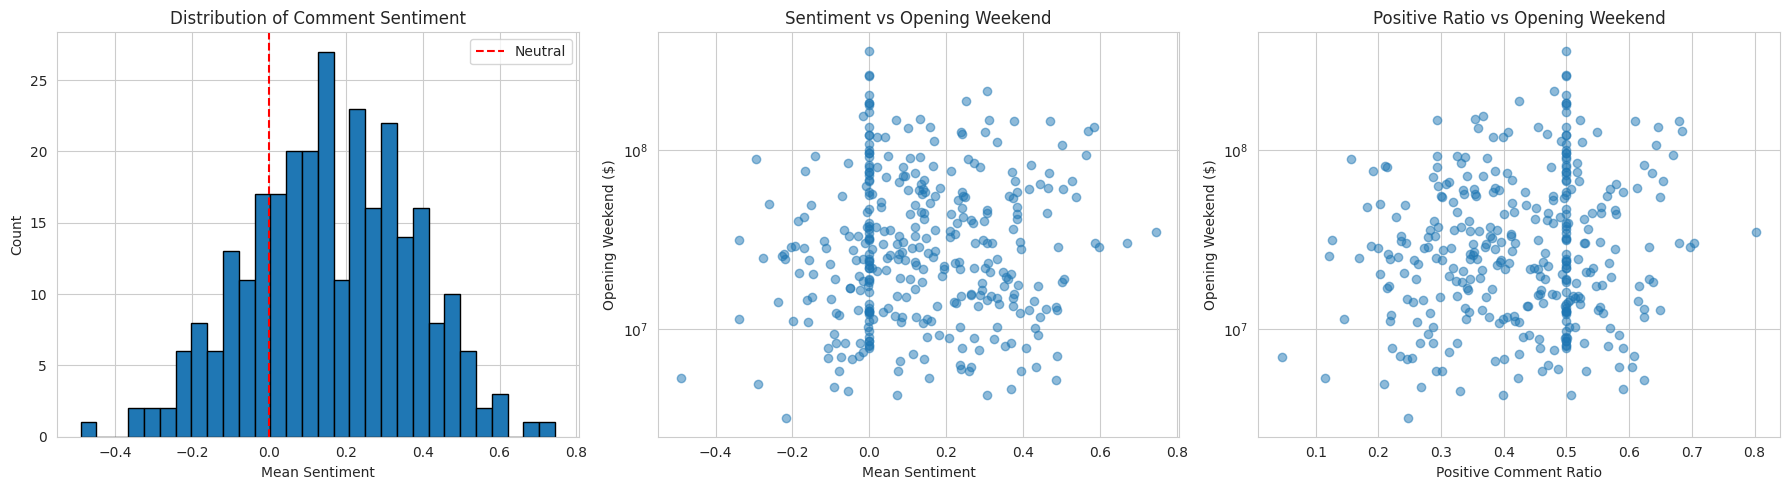

In [ ]:
# Visualize sentiment distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df[df['comment_count'] > 0]['mean_sentiment'], bins=30, edgecolor='black')
axes[0].set_xlabel('Mean Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Comment Sentiment')
axes[0].axvline(0, color='red', linestyle='--', label='Neutral')
axes[0].legend()

axes[1].scatter(df['mean_sentiment'], df['opening_weekend_domestic_usd'], alpha=0.5)
axes[1].set_xlabel('Mean Sentiment')
axes[1].set_ylabel('Opening Weekend ($)')
axes[1].set_title('Sentiment vs Opening Weekend')
axes[1].set_yscale('log')

axes[2].scatter(df['positive_ratio'], df['opening_weekend_domestic_usd'], alpha=0.5)
axes[2].set_xlabel('Positive Comment Ratio')
axes[2].set_ylabel('Opening Weekend ($)')
axes[2].set_title('Positive Ratio vs Opening Weekend')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()



These exploratory charts suggest that pre-release YouTube comment sentiment is generally mildly positive and may contain some predictive signal, but the relationship with opening weekend revenue is weak and noisy on its own. Most movies cluster slightly above neutral in mean sentiment, while both mean sentiment and positive-comment ratio show wide dispersion in box office outcomes at nearly every value.

This indicates that **sentiment should be treated as a supplementary feature rather than a strong standalone predictor**.

In addition, the visible vertical concentrations around values such as 0.0 for mean sentiment and 0.5 for positive ratio are default imputations, so these variables are better interpreted as coarse indicators of audience tone than as precise continuous measures.

## 8. Prepare Data for Multi-Input Model



In [ ]:
# Traditional tabular features for OPENING WEEKEND
# Static / safe features only
USE_OPTIONAL_DROPS = False
DROP_RELEASE_YEAR = False

cols_set = set(df.columns)

if not USE_THEATERS_FOR_OPENING and "opening_weekend_theaters" in df.columns:
    raise AssertionError(
        "opening_weekend_theaters is still present in df. "
        "Rerun the feature-construction cell after changing USE_THEATERS_FOR_OPENING."
    )

numeric_or_bool_cols = {
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c]) or pd.api.types.is_bool_dtype(df[c])
}

def existing(cols):
    return [c for c in cols if c in cols_set]

def existing_prefix(prefix, exclude=None):
    exclude = set(exclude or [])
    return [c for c in df.columns if c.startswith(prefix) and c not in exclude]

base_tabular_candidates = [
    'month',
    'month_sin',
    'month_cos',
    'day_of_week',
    'release_day',
    'is_english',
    'num_genres',
    'runtime_min',
    'trailer_days_to_release',
    'title_token_count',
    'title_has_number',
    'title_has_colon',
    'title_has_vs',
    'title_has_part',
    'is_sequel_proxy',
    'is_family_animation_core',
    'is_four_quadrant_family_like',
    'is_pandemic_distorted_release',
    'is_covid_closure_capacity_era',
    'is_delta_slowdown_era',
    'is_omicron_slowdown_era',
    'pandemic_regime_code',
    'has_video_file',
    'has_comment_file',
    'comp_all_releases_within_7d',
    'comp_same_genre_within_14d',
    'comp_family_like_within_21d',
]

base_tabular_cols = existing(base_tabular_candidates)

if USE_THEATERS_FOR_OPENING and 'opening_weekend_theaters' in cols_set:
    base_tabular_cols.append('opening_weekend_theaters')

genre_cols = existing_prefix('genre_')
rating_cols = existing_prefix('rating_', exclude={'rating_clean'})
dist_cols = existing_prefix('dist_')

timing_cols = existing([
    'is_memorial_day_corridor',
    'is_july_4_corridor',
    'is_thanksgiving_corridor',
    'is_christmas_corridor',
    'is_friday_release',
    'is_wednesday_release',
])

safe_video_numeric_cols = existing([
    'yt_duration_sec',
    'yt_tag_count',
    'yt_title_len',
    'yt_desc_len',
    'yt_title_has_official',
    'yt_title_has_trailer',
    'yt_title_has_teaser',
    'yt_title_has_final',
    'yt_title_has_trailer_num',
    'yt_channel_is_officialish',
    'yt_text_has_imax',
    'yt_text_has_plf',
])

safe_comment_numeric_cols = (
    existing([
        'yt_comment_unique_ratio_early',
        'yt_comments_per_day_mean_early',
        'yt_sent_std_early',
        'yt_sent_mean_early',
        'yt_sent_trend_slope_early',
        'yt_comment_exclamation_share_early',
        'yt_comment_like_sum_early',
        'yt_comment_like_mean_early',
        'yt_comment_like_max_early',
        'yt_comment_like_top3_share_early',
        'yt_comment_char_std_early',
        'yt_comment_bin_hhi_early',
        'yt_sent_bin_mean_std_early',
        'yt_sent_bin_mean_range_early',
        'yt_sent_bin_pos_std_early',
        'yt_sent_bin_pos_range_early',
    ])
    + existing([f'yt_comment_count_bin_{i}_early' for i in range(4)])
    + existing([f'yt_comment_share_bin_{i}_early' for i in range(4)])
    + existing([f'yt_sent_mean_bin_{i}_early' for i in range(4)])
    + existing([f'yt_sent_pos_share_bin_{i}_early' for i in range(4)])
)

candidate_tabular_cols = (
    base_tabular_cols
    + genre_cols
    + rating_cols
    + dist_cols
    + timing_cols
    + safe_video_numeric_cols
    + safe_comment_numeric_cols
)

# preserve order, remove duplicates, keep only numeric/bool cols
all_tabular_cols = []
seen = set()
for c in candidate_tabular_cols:
    if c in numeric_or_bool_cols and c not in seen:
        all_tabular_cols.append(c)
        seen.add(c)

# --------------------------------------------------
# Drop weak / redundant features from compact model
# --------------------------------------------------

DROP_FEATURES = {
    'dist_paramount_pictures',
    'genre_war',
    'dist_warner_bros_pictures',
    'is_july_4_corridor',
    'rating_PG',
    'genre_romance',
    'genre_music',
    'rating_G',
    'genre_history',
    'is_friday_release',   # redundant with day_of_week
    'has_comment_file',    # data availability artifact
    'has_video_file',      # almost constant / availability artifact
    'genre_action',
    'genre_crime',
    'genre_comedy',
}

OPTIONAL_DROP_FEATURES = {
    'release_day',
    'yt_tag_count',
    'yt_duration_sec',
    'dist_columbia_pictures',
    'is_english',
    'genre_fantasy',
    'genre_thriller',
    'genre_mystery',
    'genre_horror',
    'dist_lionsgate',
}

drop_now = set(DROP_FEATURES)

if USE_OPTIONAL_DROPS:
    drop_now |= OPTIONAL_DROP_FEATURES

if DROP_RELEASE_YEAR:
    drop_now.add('release_year')

before_drop = all_tabular_cols.copy()
all_tabular_cols = [c for c in all_tabular_cols if c not in drop_now]
dropped_cols = [c for c in before_drop if c not in all_tabular_cols]

print("\nDropped tabular features:")
print(dropped_cols if dropped_cols else "None")

print(f"Tabular features: {len(all_tabular_cols)}")
print("Using curated static + safe trailer/comment feature set:")
print(all_tabular_cols)


Dropped tabular features:
['has_video_file', 'has_comment_file', 'genre_action', 'genre_comedy', 'genre_crime', 'genre_history', 'genre_music', 'genre_romance', 'genre_war', 'rating_G', 'rating_PG', 'is_july_4_corridor', 'is_friday_release']
Tabular features: 93
Using curated static + safe trailer/comment feature set:
['month', 'month_sin', 'month_cos', 'day_of_week', 'release_day', 'is_english', 'num_genres', 'runtime_min', 'trailer_days_to_release', 'title_token_count', 'title_has_number', 'title_has_colon', 'title_has_vs', 'title_has_part', 'is_sequel_proxy', 'is_family_animation_core', 'is_four_quadrant_family_like', 'is_pandemic_distorted_release', 'is_covid_closure_capacity_era', 'is_delta_slowdown_era', 'is_omicron_slowdown_era', 'pandemic_regime_code', 'comp_all_releases_within_7d', 'comp_same_genre_within_14d', 'comp_family_like_within_21d', 'genre_adventure', 'genre_animation', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_horror', 'genre_mystery', 'genre_scifi', 'g

In [ ]:
# Remove rows with missing values in selected model inputs/targets

required_target_cols = [
    "opening_weekend_domestic_usd",
    "total_domestic_gross_usd",
]

valid_mask = df[required_target_cols].notna().all(axis=1).to_numpy()

valid_indices = np.where(valid_mask)[0]
if len(valid_indices) == 0:
    raise ValueError("No rows remain after filtering for non-missing targets.")

df_model = df.iloc[valid_indices].reset_index(drop=True).copy()
meta_cols = [
    c for c in [
        "tmdb_id",
        "title",
        "release_date_us",
        "distributor",
        "genres",
        "rating",
        "youtube_id",
    ]
    if c in df_model.columns
]
df_model_meta = df_model[meta_cols].copy()

# Clean text channels after row filtering
description_embeddings_clean = text_channels["desc"][valid_indices].astype(np.float32)
video_text_embeddings_clean = (
    text_channels["video"][valid_indices]
    * text_masks["video_has_text"][valid_indices]
).astype(np.float32)

comment_embeddings_clean = (
    text_channels["comment"][valid_indices]
    * text_masks["comment_has_text"][valid_indices]
).astype(np.float32)

# NEW: clean per-bin comment embeddings
comment_bin_embeddings_clean = {
    f"comment_bin_{i}": (
        text_channels[f"comment_bin_{i}"][valid_indices]
        * text_masks[f"comment_bin_{i}_has_text"][valid_indices]
    ).astype(np.float32)
    for i in range(4)
}

# Clean masks after row filtering
video_has_text_clean = text_masks["video_has_text"][valid_indices].astype(np.float32)
comment_has_text_clean = text_masks["comment_has_text"][valid_indices].astype(np.float32)

# NEW: clean per-bin comment masks
comment_bin_has_text_clean = {
    f"comment_bin_{i}": text_masks[f"comment_bin_{i}_has_text"][valid_indices].astype(np.float32)
    for i in range(4)
}

has_comment_file_clean = text_masks["has_comment_file"][valid_indices].astype(np.float32)
has_video_file_clean = text_masks["has_video_file"][valid_indices].astype(np.float32)

print("Rows kept for modeling:", len(valid_indices))
print("df_model shape:", df_model.shape)
print("description_embeddings_clean:", description_embeddings_clean.shape)
print("video_text_embeddings_clean:", video_text_embeddings_clean.shape)
print("comment_embeddings_clean:", comment_embeddings_clean.shape)
for i in range(4):
    print(f"comment_bin_embeddings_clean[{i}]:", comment_bin_embeddings_clean[f"comment_bin_{i}"].shape)

Rows kept for modeling: 344
df_model shape: (344, 170)
description_embeddings_clean: (344, 768)
video_text_embeddings_clean: (344, 768)
comment_embeddings_clean: (344, 768)
comment_bin_embeddings_clean[0]: (344, 768)
comment_bin_embeddings_clean[1]: (344, 768)
comment_bin_embeddings_clean[2]: (344, 768)
comment_bin_embeddings_clean[3]: (344, 768)


In [ ]:
# ------------------------------------------------------------
# Optional extra outlier filtering BEFORE split
# ------------------------------------------------------------

USE_OUTLIER_FILTER = False
OUTLIER_FILTER_MODE = "none"   # keep as "none" for the main notebook
EXTRA_TMDB_IDS_TO_DROP = set() # optional sensitivity hook only

df_model_filtered = df_model.copy()
df_model_meta_filtered = df_model_meta.copy()
keep_mask = np.ones(len(df_model_filtered), dtype=bool)

if USE_OUTLIER_FILTER:
    if OUTLIER_FILTER_MODE == "drop_specific_tmdb_ids":
        keep_mask = ~df_model_filtered["tmdb_id"].isin(EXTRA_TMDB_IDS_TO_DROP).to_numpy()
    elif OUTLIER_FILTER_MODE == "none":
        keep_mask = np.ones(len(df_model_filtered), dtype=bool)
    else:
        raise ValueError(
            "For the cleaned notebook, use OUTLIER_FILTER_MODE='none' "
            "or 'drop_specific_tmdb_ids' only."
        )

df_model_filtered = df_model_filtered.loc[keep_mask].reset_index(drop=True).copy()
df_model_meta_filtered = df_model_meta_filtered.loc[keep_mask].reset_index(drop=True).copy()

print("Extra outlier filter mode:", OUTLIER_FILTER_MODE)
print("Rows before:", len(df_model))
print("Rows after: ", len(df_model_filtered))
print("Extra dropped tmdb_ids in this cell:", sorted(EXTRA_TMDB_IDS_TO_DROP) if USE_OUTLIER_FILTER else [])


Extra outlier filter mode: none
Rows before: 344
Rows after:  344
Extra dropped tmdb_ids in this cell: []


In [ ]:
# Mild stabilization of skewed safe features

# Fallbacks only if optional outlier-filter cell was not run
if "df_model_filtered" not in globals():
    df_model_filtered = df_model.copy()

if "df_model_meta_filtered" not in globals():
    df_model_meta_filtered = df_model_meta.copy()

if "keep_mask" not in globals():
    keep_mask = np.ones(len(df_model), dtype=bool)

if 'trailer_days_to_release' in df_model_filtered.columns:
    df_model_filtered['trailer_days_to_release'] = np.log1p(
        df_model_filtered['trailer_days_to_release'].clip(lower=0)
    )

if 'runtime_min' in df_model_filtered.columns:
    df_model_filtered['runtime_min'] = df_model_filtered['runtime_min'].clip(lower=1)

# Split mode:
# - "time"   = debugging only
# - "random" = main benchmark
SPLIT_MODE = "random"
TEST_SIZE = 0.25
TAIL_Q = 0.85

# Apply same row filter to already-built arrays
X_desc_all = description_embeddings_clean.astype(np.float32)[keep_mask]
X_video_all = video_text_embeddings_clean.astype(np.float32)[keep_mask]
X_comment_all = comment_embeddings_clean.astype(np.float32)[keep_mask]
X_comment_bins_all = {
    k: v.astype(np.float32)[keep_mask]
    for k, v in comment_bin_embeddings_clean.items()
}

X_video_mask_all = video_has_text_clean.astype(np.float32)[keep_mask]
X_comment_mask_all = comment_has_text_clean.astype(np.float32)[keep_mask]
X_comment_bin_masks_all = {
    k: v.astype(np.float32)[keep_mask]
    for k, v in comment_bin_has_text_clean.items()
}
X_has_comment_file_all = has_comment_file_clean.astype(np.float32)[keep_mask]
X_has_video_file_all = has_video_file_clean.astype(np.float32)[keep_mask]

# Sanity check: rows must match after filtering
assert len(df_model_filtered) == X_desc_all.shape[0] == X_video_all.shape[0] == X_comment_all.shape[0], \
    "Filtered dataframe and text arrays are misaligned."

# Prepare tabular features from filtered df
X_tabular_full = df_model_filtered[all_tabular_cols].to_numpy(dtype=np.float32)

# Raw targets
y_opening = df_model_filtered['opening_weekend_domestic_usd'].to_numpy(dtype=np.float32)
y_total = df_model_filtered['total_domestic_gross_usd'].to_numpy(dtype=np.float32)

# Log-transformed targets for training
y_opening_log = np.log1p(y_opening)
y_total_log = np.log1p(y_total)

indices = np.arange(len(X_tabular_full))

if len(indices) == 0:
    raise ValueError("No samples available for train/test split.")

if len(indices) < 4:
    raise ValueError(f"Only {len(indices)} samples remain after filtering.")

if SPLIT_MODE == "time":
    release_dates_for_split = pd.to_datetime(
        df_model_meta_filtered["release_date_us"], errors='coerce'
    ).fillna(pd.Timestamp("1900-01-01"))
    order = np.argsort(release_dates_for_split.to_numpy())
    test_n = max(1, int(round(TEST_SIZE * len(order))))
    idx_train = order[:-test_n]
    idx_test = order[-test_n:]
else:
    stratify_arg = None
    try:
        q = min(6, max(2, pd.Series(y_opening_log).nunique()))
        y_bins = pd.qcut(
            pd.Series(y_opening_log),
            q=q,
            duplicates='drop'
        ).astype(str)

        tail_flag = pd.Series(
            (y_opening >= np.quantile(y_opening, TAIL_Q)).astype(int)
        ).astype(str)

        strat_key = y_bins + "__tail_" + tail_flag

        vc = strat_key.value_counts()
        strat_key = strat_key.where(strat_key.map(vc) >= 2, y_bins)

        if strat_key.nunique() >= 2:
            stratify_arg = strat_key
    except Exception:
        stratify_arg = None

    idx_train, idx_test = train_test_split(
        indices,
        test_size=TEST_SIZE,
        random_state=42,
        stratify=stratify_arg
    )

df_train_meta = df_model_meta_filtered.iloc[idx_train].reset_index(drop=True).copy()
df_test_meta = df_model_meta_filtered.iloc[idx_test].reset_index(drop=True).copy()

default_key_feature_cols = [
    c for c in [
        "release_year",
        "month",
        "day_of_week",
        "runtime_min",
        "rating_R",
        "rating_PG_13",
        "genre_drama",
        "genre_adventure",
        "dist_marvel_studios",
        "yt_sent_std_early",
        "yt_sent_mean_early",
        "yt_comment_unique_ratio_early",
        "yt_comment_exclamation_share_early",
        "is_wednesday_release",
        "is_christmas_corridor",
    ]
    if c in df_model_filtered.columns
]

df_test_key_features = (
    df_model_filtered.iloc[idx_test][default_key_feature_cols]
    .reset_index(drop=True)
    .copy()
)

print("Diagnostic key feature columns:")
print(default_key_feature_cols)

X_tabular_train = X_tabular_full[idx_train]
X_tabular_test = X_tabular_full[idx_test]

X_desc_train = X_desc_all[idx_train]
X_desc_test = X_desc_all[idx_test]

X_video_train = X_video_all[idx_train]
X_video_test = X_video_all[idx_test]

X_comment_train = X_comment_all[idx_train]
X_comment_test = X_comment_all[idx_test]

X_comment_bins_train = {k: v[idx_train] for k, v in X_comment_bins_all.items()}
X_comment_bins_test = {k: v[idx_test] for k, v in X_comment_bins_all.items()}

X_video_mask_train = X_video_mask_all[idx_train]
X_video_mask_test = X_video_mask_all[idx_test]

X_comment_mask_train = X_comment_mask_all[idx_train]
X_comment_mask_test = X_comment_mask_all[idx_test]

X_comment_bin_masks_train = {k: v[idx_train] for k, v in X_comment_bin_masks_all.items()}
X_comment_bin_masks_test = {k: v[idx_test] for k, v in X_comment_bin_masks_all.items()}

X_has_comment_file_train = X_has_comment_file_all[idx_train]
X_has_comment_file_test = X_has_comment_file_all[idx_test]

X_has_video_file_train = X_has_video_file_all[idx_train]
X_has_video_file_test = X_has_video_file_all[idx_test]

y_opening_train = y_opening[idx_train]
y_opening_test = y_opening[idx_test]

y_total_train = y_total[idx_train]
y_total_test = y_total[idx_test]

y_opening_log_train = y_opening_log[idx_train]
y_opening_log_test = y_opening_log[idx_test]

y_total_log_train = y_total_log[idx_train]
y_total_log_test = y_total_log[idx_test]

print(f"\nSplit mode: {SPLIT_MODE}")
print(f"Train: {len(idx_train)} movies")
print(f"Test: {len(idx_test)} movies")
print(f"Opening target range (train): ${y_opening_train.min():,.0f} to ${y_opening_train.max():,.0f}")
print(f"Opening log target range (train): {y_opening_log_train.min():.3f} to {y_opening_log_train.max():.3f}")

Diagnostic key feature columns:
['release_year', 'month', 'day_of_week', 'runtime_min', 'rating_R', 'rating_PG_13', 'genre_drama', 'genre_adventure', 'yt_sent_std_early', 'yt_sent_mean_early', 'yt_comment_unique_ratio_early', 'yt_comment_exclamation_share_early', 'is_wednesday_release', 'is_christmas_corridor']

Split mode: random
Train: 258 movies
Test: 86 movies
Opening target range (train): $3,165,349 to $357,115,008
Opening log target range (train): 14.968 to 19.694


In [ ]:
MIN_PCA = 8

# Scale tabular features
# Train-only imputation for tabular inputs
if not USE_THEATERS_FOR_OPENING and "opening_weekend_theaters" in all_tabular_cols:
    raise AssertionError(
        "opening_weekend_theaters is still present in all_tabular_cols. "
        "Rerun the feature and tabular-selection cells after changing USE_THEATERS_FOR_OPENING."
    )

tab_imputer = SimpleImputer(strategy="median")
X_tabular_train_imp = tab_imputer.fit_transform(X_tabular_train)
X_tabular_test_imp = tab_imputer.transform(X_tabular_test)

scaler_tabular = StandardScaler()
X_tabular_train_scaled = scaler_tabular.fit_transform(X_tabular_train_imp).astype(np.float32)
X_tabular_test_scaled = scaler_tabular.transform(X_tabular_test_imp).astype(np.float32)

# ------------------------------------------------------------
# Compact scalar-tab transformer feature set
# Keep this intentionally smaller and stronger than the ResNet tabular set.
# ------------------------------------------------------------
transformer_tabular_candidates = [
    "runtime_min",
    "trailer_days_to_release",
    "month_sin",
    "month_cos",
    "title_token_count",
    "title_has_number",
    "title_has_colon",
    "title_has_part",
    "is_sequel_proxy",
    "rating_PG_13",
    "rating_R",
    "genre_family",
    "genre_animation",
    "genre_adventure",
    "genre_drama",
    "genre_horror",
    "genre_scifi",
    "yt_comment_unique_ratio_early",
    "yt_comments_per_day_mean_early",
    "yt_comment_exclamation_share_early",
    "yt_comment_count_bin_0_early",
    "yt_comment_count_bin_1_early",
    "yt_comment_count_bin_2_early",
    "yt_comment_count_bin_3_early",
    "yt_sent_mean_bin_0_early",
    "yt_sent_mean_bin_1_early",
    "yt_sent_mean_bin_2_early",
    "yt_sent_mean_bin_3_early",
    "yt_title_has_teaser",
    "yt_title_has_final",
    "yt_channel_is_officialish",
]

tabular_features_tf_small = existing(transformer_tabular_candidates)

missing_tf_cols = [c for c in transformer_tabular_candidates if c not in tabular_features_tf_small]
if missing_tf_cols:
    print("Missing transformer compact-tab columns dropped:", missing_tf_cols)

if len(tabular_features_tf_small) == 0:
    raise ValueError("tabular_features_tf_small is empty after filtering to existing columns.")

tf_col_idx = [all_tabular_cols.index(c) for c in tabular_features_tf_small]

X_tabular_tf_train = X_tabular_train[:, tf_col_idx].astype(np.float32)
X_tabular_tf_test = X_tabular_test[:, tf_col_idx].astype(np.float32)

tab_imputer_tf = SimpleImputer(strategy="median")
X_tabular_tf_train_imp = tab_imputer_tf.fit_transform(X_tabular_tf_train)
X_tabular_tf_test_imp = tab_imputer_tf.transform(X_tabular_tf_test)

scaler_tabular_tf = StandardScaler()
X_tabular_tf_train_scaled = scaler_tabular_tf.fit_transform(X_tabular_tf_train_imp).astype(np.float32)
X_tabular_tf_test_scaled = scaler_tabular_tf.transform(X_tabular_tf_test_imp).astype(np.float32)

print("Transformer compact scalar-tab cols:", len(tabular_features_tf_small))
print(tabular_features_tf_small)

# Separate direct input for opening_weekend_theaters skip branch
# Keep the model signature stable: if flag is off, pass zeros.
if USE_THEATERS_FOR_OPENING and "opening_weekend_theaters" in all_tabular_cols:
    opening_weekend_theaters_idx = all_tabular_cols.index("opening_weekend_theaters")

    X_opening_theaters_train = X_tabular_train[:, [opening_weekend_theaters_idx]].astype(np.float32)
    X_opening_theaters_test = X_tabular_test[:, [opening_weekend_theaters_idx]].astype(np.float32)

    opening_theaters_imputer = SimpleImputer(strategy="median")
    X_opening_theaters_train_imp = opening_theaters_imputer.fit_transform(X_opening_theaters_train)
    X_opening_theaters_test_imp = opening_theaters_imputer.transform(X_opening_theaters_test)

    opening_theaters_scaler = StandardScaler()
    X_opening_theaters_train_scaled = opening_theaters_scaler.fit_transform(
        X_opening_theaters_train_imp
    ).astype(np.float32)
    X_opening_theaters_test_scaled = opening_theaters_scaler.transform(
        X_opening_theaters_test_imp
    ).astype(np.float32)
else:
    X_opening_theaters_train_scaled = np.zeros((X_tabular_train.shape[0], 1), dtype=np.float32)
    X_opening_theaters_test_scaled = np.zeros((X_tabular_test.shape[0], 1), dtype=np.float32)


def reduce_text_channel(Xtr, Xte, n_comp, label):
    n_comp = min(n_comp, Xtr.shape[0] - 1, Xtr.shape[1])
    if n_comp < 1:
        return (
            np.zeros((Xtr.shape[0], 0), dtype=np.float32),
            np.zeros((Xte.shape[0], 0), dtype=np.float32),
            0,
            None,
            None,
        )

    pca = PCA(n_components=n_comp, random_state=42)
    Xtr_red = pca.fit_transform(Xtr)
    Xte_red = pca.transform(Xte)

    scaler = StandardScaler()
    Xtr_red = scaler.fit_transform(Xtr_red).astype(np.float32)
    Xte_red = scaler.transform(Xte_red).astype(np.float32)

    return Xtr_red, Xte_red, n_comp, pca, scaler


X_desc_train_red, X_desc_test_red, desc_dim, pca_desc, scaler_desc = reduce_text_channel(
    X_desc_train, X_desc_test, n_comp=MIN_PCA, label="desc"
)
X_video_train_red, X_video_test_red, video_dim, pca_video, scaler_video = reduce_text_channel(
    X_video_train, X_video_test, n_comp=MIN_PCA, label="video"
)
X_comment_train_red, X_comment_test_red, comment_dim, pca_comment, scaler_comment = reduce_text_channel(
    X_comment_train, X_comment_test, n_comp=int(MIN_PCA / 2), label="comment"
)

comment_bin_reduced = {}
for i in range(4):
    key = f"comment_bin_{i}"
    Xtr_red, Xte_red, cdim, cpca, cscaler = reduce_text_channel(
        X_comment_bins_train[key],
        X_comment_bins_test[key],
        n_comp=max(2, int(MIN_PCA / 3)),
        label=key,
    )
    comment_bin_reduced[key] = {
        "train": Xtr_red,
        "test": Xte_red,
        "dim": cdim,
        "pca": cpca,
        "scaler": cscaler,
    }

X_mask_train = np.concatenate(
    [
        X_video_mask_train,
        X_comment_mask_train,
        *[X_comment_bin_masks_train[f"comment_bin_{i}"] for i in range(4)],
    ],
    axis=1,
).astype(np.float32)

X_mask_test = np.concatenate(
    [
        X_video_mask_test,
        X_comment_mask_test,
        *[X_comment_bin_masks_test[f"comment_bin_{i}"] for i in range(4)],
    ],
    axis=1,
).astype(np.float32)

X_text_train_reduced = np.concatenate(
    [
        X_desc_train_red,
        X_video_train_red,
        X_comment_train_red,
        *[comment_bin_reduced[f"comment_bin_{i}"]["train"] for i in range(4)],
        X_mask_train,
    ],
    axis=1,
).astype(np.float32)

X_text_test_reduced = np.concatenate(
    [
        X_desc_test_red,
        X_video_test_red,
        X_comment_test_red,
        *[comment_bin_reduced[f"comment_bin_{i}"]["test"] for i in range(4)],
        X_mask_test,
    ],
    axis=1,
).astype(np.float32)

# Standardize targets in log space
y_opening_mean = y_opening_log_train.mean()
y_opening_std = y_opening_log_train.std()

y_total_mean = y_total_log_train.mean()
y_total_std = y_total_log_train.std()

y_opening_train_model = ((y_opening_log_train - y_opening_mean) / y_opening_std).astype(np.float32)
y_total_train_model = ((y_total_log_train - y_total_mean) / y_total_std).astype(np.float32)

print("✓ Tabular features scaled")
print(
    f"✓ Separate text PCA dims: desc={desc_dim}, video={video_dim}, "
    f"comment={comment_dim}, masks={X_mask_train.shape[1]}"
)
print("✓ Targets standardized in log space")
print(f"Opening target mean/std: {y_opening_mean:.3f} / {y_opening_std:.3f}")
print(f"Total target mean/std:   {y_total_mean:.3f} / {y_total_std:.3f}")
print("Shapes:")
print(f"  X_tabular_train_scaled:    {X_tabular_train_scaled.shape}")
print(f"  X_text_train_reduced:      {X_text_train_reduced.shape}")
print(f"  X_tabular_test_scaled:     {X_tabular_test_scaled.shape}")

# Storage for model results across notebook runs
all_model_results = []
model_results_by_name = {}


Transformer compact scalar-tab cols: 31
['runtime_min', 'trailer_days_to_release', 'month_sin', 'month_cos', 'title_token_count', 'title_has_number', 'title_has_colon', 'title_has_part', 'is_sequel_proxy', 'rating_PG_13', 'rating_R', 'genre_family', 'genre_animation', 'genre_adventure', 'genre_drama', 'genre_horror', 'genre_scifi', 'yt_comment_unique_ratio_early', 'yt_comments_per_day_mean_early', 'yt_comment_exclamation_share_early', 'yt_comment_count_bin_0_early', 'yt_comment_count_bin_1_early', 'yt_comment_count_bin_2_early', 'yt_comment_count_bin_3_early', 'yt_sent_mean_bin_0_early', 'yt_sent_mean_bin_1_early', 'yt_sent_mean_bin_2_early', 'yt_sent_mean_bin_3_early', 'yt_title_has_teaser', 'yt_title_has_final', 'yt_channel_is_officialish']
✓ Tabular features scaled
✓ Separate text PCA dims: desc=8, video=8, comment=4, masks=6
✓ Targets standardized in log space
Opening target mean/std: 17.138 / 0.932
Total target mean/std:   18.246 / 0.974
Shapes:
  X_tabular_train_scaled:    (258, 

In [ ]:
# Shared explicit validation split for all Keras opening-weekend models

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

if SPLIT_MODE == "time":
    train_release_dates = pd.to_datetime(
        df_train_meta["release_date_us"], errors="coerce"
    ).fillna(pd.Timestamp("1900-01-01"))

    train_order = np.argsort(train_release_dates.to_numpy())
    val_n = max(1, int(round(0.20 * len(train_order))))

    train_idx_nn = train_order[:-val_n]
    val_idx_nn = train_order[-val_n:]
else:
    try:
        q = min(6, max(2, pd.Series(y_opening_log_train).nunique()))
        y_bins_train = pd.qcut(
            pd.Series(y_opening_log_train),
            q=q,
            duplicates='drop'
        ).astype(str)

        tail_flag_train = pd.Series(
            (y_opening_train >= np.quantile(y_opening_train, 0.85)).astype(int)
        ).astype(str)

        strat_labels_train = y_bins_train + "__tail_" + tail_flag_train

        vc = strat_labels_train.value_counts()
        strat_labels_train = strat_labels_train.where(
            strat_labels_train.map(vc) >= 2,
            y_bins_train
        )
    except Exception:
        strat_labels_train = None

    train_idx_nn, val_idx_nn = train_test_split(
        np.arange(len(y_opening_train_model)),
        test_size=0.2,
        random_state=42,
        stratify=strat_labels_train
    )

# targets / weights only
y_opening_tr = y_opening_train_model[train_idx_nn].astype(np.float32)
y_opening_val = y_opening_train_model[val_idx_nn].astype(np.float32)

y_total_tr = y_total_train_model[train_idx_nn].astype(np.float32)
y_total_val = y_total_train_model[val_idx_nn].astype(np.float32)

sample_weight_text = None

train_log_raw = y_opening_log_train[train_idx_nn]
q90 = np.quantile(train_log_raw, 0.90)
q97 = np.quantile(train_log_raw, 0.97)

sample_weight_nn = np.ones(len(train_log_raw), dtype=np.float32)
sample_weight_nn[train_log_raw >= q90] = 1.05
sample_weight_nn[train_log_raw >= q97] = 1.15

ensemble_seeds = [11, 22, 33, 44, 55]

print("Shared validation split sizes:")
print("  train_idx_nn:", train_idx_nn.shape)
print("  val_idx_nn:  ", val_idx_nn.shape)
print("  y_opening_tr:", y_opening_tr.shape)
print("  y_opening_val:", y_opening_val.shape)


Shared validation split sizes:
  train_idx_nn: (206,)
  val_idx_nn:   (52,)
  y_opening_tr: (206,)
  y_opening_val: (52,)


In [ ]:
# Rebuild all split-dependent model input views from the CURRENT split indices.
# Run this cell whenever upstream data / features / filters / split change.

def _split_inner(arr):
    return arr[train_idx_nn].astype(np.float32), arr[val_idx_nn].astype(np.float32)

def _assert_same_n(name, arrays):
    lens = []
    for a in arrays:
        if isinstance(a, list):
            lens.extend([len(x) for x in a])
        else:
            lens.append(len(a))
    uniq = sorted(set(lens))
    if len(uniq) != 1:
        raise AssertionError(f"{name}: inconsistent sample counts {uniq}")

# ---------- Generic Keras views ----------
X_tab_tr, X_tab_val = _split_inner(X_tabular_train_scaled)
X_text_tr, X_text_val = _split_inner(X_text_train_reduced)

# ---------- ResNet views ----------
RESNET_TAB_COLS = all_tabular_cols.copy()

X_resnet_train_scaled = X_tabular_train_scaled.astype(np.float32)
X_resnet_test_scaled = X_tabular_test_scaled.astype(np.float32)
X_resnet_tr, X_resnet_val = _split_inner(X_resnet_train_scaled)

# ---------- Transformer views ----------
COMMENT_BIN_KEYS = [f"comment_bin_{i}" for i in range(4)]

X_desc_tr_raw, X_desc_val_raw = _split_inner(X_desc_train)
X_video_tr_raw, X_video_val_raw = _split_inner(X_video_train)
X_comment_tr_raw, X_comment_val_raw = _split_inner(X_comment_train)

X_comment_bin_tr_raw = [
    X_comment_bins_train[k][train_idx_nn].astype(np.float32)
    for k in COMMENT_BIN_KEYS
]
X_comment_bin_val_raw = [
    X_comment_bins_train[k][val_idx_nn].astype(np.float32)
    for k in COMMENT_BIN_KEYS
]

X_tab_tr_tf, X_tab_val_tf = _split_inner(X_tabular_tf_train_scaled)

X_video_mask_tr_tf = X_video_mask_train[train_idx_nn].astype(np.float32).reshape(-1, 1)
X_video_mask_val_tf = X_video_mask_train[val_idx_nn].astype(np.float32).reshape(-1, 1)

X_comment_mask_tr_tf = X_comment_mask_train[train_idx_nn].astype(np.float32).reshape(-1, 1)
X_comment_mask_val_tf = X_comment_mask_train[val_idx_nn].astype(np.float32).reshape(-1, 1)

X_comment_bin_mask_tr_tf = [
    X_comment_bin_masks_train[k][train_idx_nn].astype(np.float32).reshape(-1, 1)
    for k in COMMENT_BIN_KEYS
]
X_comment_bin_mask_val_tf = [
    X_comment_bin_masks_train[k][val_idx_nn].astype(np.float32).reshape(-1, 1)
    for k in COMMENT_BIN_KEYS
]

X_desc_train_full_tf = X_desc_train.astype(np.float32)
X_desc_test_full_tf = X_desc_test.astype(np.float32)

X_video_train_full_tf = X_video_train.astype(np.float32)
X_video_test_full_tf = X_video_test.astype(np.float32)

X_comment_train_full_tf = X_comment_train.astype(np.float32)
X_comment_test_full_tf = X_comment_test.astype(np.float32)

X_comment_bin_train_full_tf = [
    X_comment_bins_train[k].astype(np.float32)
    for k in COMMENT_BIN_KEYS
]
X_comment_bin_test_full_tf = [
    X_comment_bins_test[k].astype(np.float32)
    for k in COMMENT_BIN_KEYS
]

X_tab_train_full_tf = X_tabular_tf_train_scaled.astype(np.float32)
X_tab_test_full_tf = X_tabular_tf_test_scaled.astype(np.float32)

X_video_mask_train_full_tf = X_video_mask_train.astype(np.float32).reshape(-1, 1)
X_video_mask_test_full_tf = X_video_mask_test.astype(np.float32).reshape(-1, 1)

X_comment_mask_train_full_tf = X_comment_mask_train.astype(np.float32).reshape(-1, 1)
X_comment_mask_test_full_tf = X_comment_mask_test.astype(np.float32).reshape(-1, 1)

X_comment_bin_mask_train_full_tf = [
    X_comment_bin_masks_train[k].astype(np.float32).reshape(-1, 1)
    for k in COMMENT_BIN_KEYS
]
X_comment_bin_mask_test_full_tf = [
    X_comment_bin_masks_test[k].astype(np.float32).reshape(-1, 1)
    for k in COMMENT_BIN_KEYS
]

X_opening_theaters_tr_tf = X_opening_theaters_train_scaled[train_idx_nn].astype(np.float32)
X_opening_theaters_val_tf = X_opening_theaters_train_scaled[val_idx_nn].astype(np.float32)
X_opening_theaters_train_full_tf = X_opening_theaters_train_scaled.astype(np.float32)
X_opening_theaters_test_full_tf = X_opening_theaters_test_scaled.astype(np.float32)

In [ ]:
# ---------- Cardinality checks ----------
_assert_same_n("generic keras", [X_tab_tr, X_text_tr, y_opening_tr, sample_weight_nn])
_assert_same_n("resnet", [X_resnet_tr, X_text_tr, y_opening_tr, sample_weight_nn])
_assert_same_n(
    "transformer train",
    [
        X_desc_tr_raw,
        X_video_tr_raw,
        X_comment_tr_raw,
        X_comment_bin_tr_raw,
        X_tab_tr_tf,
        X_video_mask_tr_tf,
        X_comment_mask_tr_tf,
        X_comment_bin_mask_tr_tf,
        y_opening_tr,
    ],
)

print("✓ Rebuilt all split-dependent model input views")
print("  X_tab_tr:", X_tab_tr.shape)
print("  X_text_tr:", X_text_tr.shape)
print("  X_resnet_tr:", X_resnet_tr.shape)
print("  X_desc_tr_raw:", X_desc_tr_raw.shape)
print("  X_comment_tr_raw:", X_comment_tr_raw.shape)
print("  X_tab_tr_tf:", X_tab_tr_tf.shape)
print("  X_comment_bin_tr_raw[0]:", X_comment_bin_tr_raw[0].shape)

✓ Rebuilt all split-dependent model input views
  X_tab_tr: (206, 93)
  X_text_tr: (206, 34)
  X_resnet_tr: (206, 93)
  X_desc_tr_raw: (206, 768)
  X_comment_tr_raw: (206, 768)
  X_tab_tr_tf: (206, 31)
  X_comment_bin_tr_raw[0]: (206, 768)


In [ ]:
def _pred_z_to_log(pred_z, y_log_mean, y_log_std, clip_lo, clip_hi):
    pred_log = np.asarray(pred_z, dtype=np.float32) * y_log_std + y_log_mean
    pred_log = np.clip(pred_log, clip_lo, clip_hi)
    return pred_log


def _score_log_preds(y_true_log, pred_z, y_log_mean, y_log_std, clip_lo, clip_hi):
    pred_log = _pred_z_to_log(pred_z, y_log_mean, y_log_std, clip_lo, clip_hi)
    return {
        "mae_log": float(mean_absolute_error(y_true_log, pred_log)),
        "r2_log": float(r2_score(y_true_log, pred_log)),
        "pred_log": pred_log,
    }


def fit_single_keras_candidate(
    build_model_fn,
    X_train_fit,
    y_train_fit,
    X_val_fit,
    y_val_fit,
    y_val_log_true,
    y_log_mean,
    y_log_std,
    epochs=180,
    batch_size=8,
    verbose=0,
    sample_weight_fit=None,
    seed=11,
    callbacks_fn=None,
):
    set_all_seeds(seed)

    clip_lo = float(np.min(y_opening_log_train) - 0.15)
    clip_hi = float(np.max(y_opening_log_train) + 0.15)

    model = build_model_fn()
    current_callbacks = callbacks_fn() if callbacks_fn is not None else make_nn_callbacks()

    history = model.fit(
        X_train_fit,
        y_train_fit,
        validation_data=(X_val_fit, y_val_fit),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=current_callbacks,
        verbose=verbose,
        shuffle=True,
        sample_weight=sample_weight_fit,
    )

    val_pred_z = model.predict(X_val_fit, verbose=0).ravel()
    val_scores = _score_log_preds(
        y_true_log=y_val_log_true,
        pred_z=val_pred_z,
        y_log_mean=y_log_mean,
        y_log_std=y_log_std,
        clip_lo=clip_lo,
        clip_hi=clip_hi,
    )

    return {
        "model": model,
        "history": history.history,
        "best_val_loss": float(np.min(history.history["val_loss"])),
        "val_mae_log": val_scores["mae_log"],
        "val_r2_log": val_scores["r2_log"],
    }


def score_fit_on_validation(
    fit_obj,
    X_val_fit,
    y_val_log_true,
    y_log_mean,
    y_log_std,
):
    clip_lo = float(np.min(y_opening_log_train) - 0.15)
    clip_hi = float(np.max(y_opening_log_train) + 0.15)

    val_preds_z = np.column_stack([
        m.predict(X_val_fit, verbose=0).ravel() for m in fit_obj["models"]
    ]).mean(axis=1)

    val_scores = _score_log_preds(
        y_true_log=y_val_log_true,
        pred_z=val_preds_z,
        y_log_mean=y_log_mean,
        y_log_std=y_log_std,
        clip_lo=clip_lo,
        clip_hi=clip_hi,
    )

    return {
        "val_mae_log": val_scores["mae_log"],
        "val_r2_log": val_scores["r2_log"],
    }

# ============================================================
# Cache / history helpers for stage1 + stage2 search
# ============================================================
# Bump this when you materially change:
# - feature set
# - exclusions
# - split logic
# - architecture semantics
CACHE_VERSION = "opening_weekend_nn_cache_v1"

CACHE_ROOT = Path("nn_cache")
CACHE_ROOT.mkdir(exist_ok=True)


def _json_default(x):
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    return str(x)


def _stable_json(obj):
    return json.dumps(obj, sort_keys=True, separators=(",", ":"), default=_json_default)


def _short_hash(obj, n=24):
    return hashlib.sha1(_stable_json(obj).encode("utf-8")).hexdigest()[:n]


def make_current_split_sig():
    payload = {
        "cache_version": CACHE_VERSION,
        "tmdb_ids": df_model_filtered["tmdb_id"].astype(str).tolist() if "df_model_filtered" in globals() else None,
        "train_idx": np.asarray(train_idx).tolist() if "train_idx" in globals() else None,
        "test_idx": np.asarray(test_idx).tolist() if "test_idx" in globals() else None,
        "train_idx_nn": np.asarray(train_idx_nn).tolist() if "train_idx_nn" in globals() else None,
        "val_idx_nn": np.asarray(val_idx_nn).tolist() if "val_idx_nn" in globals() else None,
        "use_theaters_for_opening": bool(USE_THEATERS_FOR_OPENING) if "USE_THEATERS_FOR_OPENING" in globals() else None,
    }
    return _short_hash(payload, n=24)


SPLIT_SIG = make_current_split_sig()
print("SPLIT_SIG:", SPLIT_SIG)


def params_key(params):
    return _short_hash(params, n=20)


def history_csv_path(model_family, stage_name):
    return CACHE_ROOT / f"{model_family}_{stage_name}_history.csv"


def load_history_df(model_family, stage_name):
    path = history_csv_path(model_family, stage_name)
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def append_history_row(model_family, stage_name, row):
    path = history_csv_path(model_family, stage_name)
    row_df = pd.DataFrame([row])

    if path.exists():
        old_df = pd.read_csv(path)
        out_df = pd.concat([old_df, row_df], ignore_index=True)
    else:
        out_df = row_df

    if {"split_sig", "params_key"}.issubset(out_df.columns):
        out_df = out_df.drop_duplicates(subset=["split_sig", "params_key"], keep="last")

    out_df.to_csv(path, index=False)
    return out_df


def get_cached_history_row(model_family, stage_name, split_sig, params):
    df = load_history_df(model_family, stage_name)
    if df.empty or not {"split_sig", "params_key"}.issubset(df.columns):
        return None

    key = params_key(params)
    hit = df[(df["split_sig"] == split_sig) & (df["params_key"] == key)]
    if len(hit) == 0:
        return None
    return hit.iloc[0].to_dict()


def model_run_dir(model_family, split_sig, params):
    return CACHE_ROOT / model_family / f"{split_sig}_{params_key(params)}"


def fit_keras_regressor_cached(
    build_model_fn,
    X_train_fit,
    y_train_fit,
    X_val_fit,
    y_val_fit,
    eval_train_inputs,
    eval_test_inputs,
    seeds,
    model_label="Keras model",
    epochs=200,
    batch_size=8,
    verbose=0,
    sample_weight_fit=None,
    model_family="nn",
    params=None,
    callbacks_fn=None,
):
    """
    Cache-aware version of fit_keras_regressor.
    Loads previously saved seed weights if they exist for the same:
      - model_family
      - split_sig
      - params
    Otherwise trains, saves weights, and writes manifest metadata.
    """

    if params is None:
        raise ValueError("fit_keras_regressor_cached requires params=... for cache keying.")

    run_dir = model_run_dir(model_family, SPLIT_SIG, params)
    manifest_path = run_dir / "manifest.json"

    # --------------------------------------------------------
    # Try cache load first
    # --------------------------------------------------------
    if manifest_path.exists():
        try:
            with open(manifest_path, "r") as f:
                meta = json.load(f)

            fitted_models = []
            histories = []
            val_losses = []

            for seed in seeds:
                weight_path = run_dir / f"seed_{seed}.weights.h5"
                if not weight_path.exists():
                    raise FileNotFoundError(f"Missing cached weights for seed {seed}: {weight_path}")

                model = build_model_fn()
                model.load_weights(str(weight_path))
                fitted_models.append(model)

                hist = meta["histories_by_seed"].get(str(seed), {})
                histories.append(hist)

                val_loss = meta["val_losses_by_seed"].get(str(seed), np.nan)
                val_losses.append(float(val_loss))

            train_pred_z_all = []
            test_pred_z_all = []

            for model in fitted_models:
                train_pred_z_all.append(model.predict(eval_train_inputs, verbose=0).ravel())
                test_pred_z_all.append(model.predict(eval_test_inputs, verbose=0).ravel())

            best_idx = int(np.nanargmin(val_losses))

            print(f"Loaded cached fit for {model_label} from {run_dir}")

            return {
                "label": model_label,
                "models": fitted_models,
                "best_model": fitted_models[best_idx],
                "best_history": histories[best_idx],
                "best_idx": best_idx,
                "best_seed": seeds[best_idx],
                "best_val_loss": float(val_losses[best_idx]),
                "avg_val_loss": float(np.nanmean(val_losses)),
                "ensemble_train_pred_z": np.mean(np.vstack(train_pred_z_all), axis=0),
                "ensemble_test_pred_z": np.mean(np.vstack(test_pred_z_all), axis=0),
                "loaded_from_cache": True,
            }

        except Exception as e:
            print(f"Cache load failed for {model_label}; retraining. Reason: {e}")

    # --------------------------------------------------------
    # Train fresh
    # --------------------------------------------------------
    fitted_models = []
    histories = []
    val_losses = []
    train_pred_z_all = []
    test_pred_z_all = []

    histories_by_seed = {}
    val_losses_by_seed = {}

    for seed in seeds:
        print(f"  Seed {seed}")
        set_all_seeds(seed)

        model = build_model_fn()
        current_callbacks = callbacks_fn() if callbacks_fn is not None else make_nn_callbacks()

        history = model.fit(
            X_train_fit,
            y_train_fit,
            validation_data=(X_val_fit, y_val_fit),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=current_callbacks,
            verbose=verbose,
            shuffle=True,
            sample_weight=sample_weight_fit,
        )

        fitted_models.append(model)
        histories.append(history.history)

        current_best_val_loss = float(np.min(history.history["val_loss"]))
        val_losses.append(current_best_val_loss)

        histories_by_seed[str(seed)] = history.history
        val_losses_by_seed[str(seed)] = current_best_val_loss

        train_pred_z_all.append(model.predict(eval_train_inputs, verbose=0).ravel())
        test_pred_z_all.append(model.predict(eval_test_inputs, verbose=0).ravel())

    best_idx = int(np.argmin(val_losses))

    # --------------------------------------------------------
    # Save cache artifacts
    # --------------------------------------------------------
    run_dir.mkdir(parents=True, exist_ok=True)

    for seed, model in zip(seeds, fitted_models):
        model.save_weights(str(run_dir / f"seed_{seed}.weights.h5"))

    meta = {
        "model_label": model_label,
        "split_sig": SPLIT_SIG,
        "params": params,
        "seeds": list(seeds),
        "batch_size": batch_size,
        "epochs": epochs,
        "histories_by_seed": histories_by_seed,
        "val_losses_by_seed": val_losses_by_seed,
    }
    with open(manifest_path, "w") as f:
        json.dump(meta, f)

    print(f"Saved cached fit for {model_label} to {run_dir}")

    return {
        "label": model_label,
        "models": fitted_models,
        "best_model": fitted_models[best_idx],
        "best_history": histories[best_idx],
        "best_idx": best_idx,
        "best_seed": seeds[best_idx],
        "best_val_loss": float(val_losses[best_idx]),
        "avg_val_loss": float(np.mean(val_losses)),
        "ensemble_train_pred_z": np.mean(np.vstack(train_pred_z_all), axis=0),
        "ensemble_test_pred_z": np.mean(np.vstack(test_pred_z_all), axis=0),
        "loaded_from_cache": False,
    }


def run_nn_param_search(
    candidates,
    build_model_from_params,
    X_train_fit,
    y_train_fit,
    X_val_fit,
    y_val_fit,
    y_val_log_true,
    eval_train_inputs,
    eval_test_inputs,
    y_log_mean,
    y_log_std,
    sample_weight_fit=None,
    fast_seed=11,
    top_k=2,
    final_seeds=(11, 22, 33),
    search_epochs=220,
    final_epochs=300,
    verbose=0,
    model_label_prefix="NN",
    model_family="nn",
    stage1_callbacks_fn=None,
    final_callbacks_fn=None,
):
    stage1_rows_current = []

    print(f"Fast search over {len(candidates)} candidates")

    # Keep original candidate dtypes so cached/DataFrame rows do not turn ints into floats
    param_keys = list(candidates[0].keys())
    param_template = {k: candidates[0][k] for k in param_keys}

    def _coerce_params(row_like):
        out = {}
        for k in param_keys:
            template_val = param_template[k]
            v = row_like[k]

            if isinstance(template_val, (bool, np.bool_)):
                out[k] = bool(v)
            elif isinstance(template_val, (int, np.integer)) and not isinstance(template_val, (bool, np.bool_)):
                out[k] = int(round(float(v)))
            elif isinstance(template_val, (float, np.floating)):
                out[k] = float(v)
            else:
                out[k] = v
        return out

    # ---------------------------
    # Stage 1: single-seed search
    # ---------------------------
    for i, params in enumerate(candidates, start=1):
        cached_row = get_cached_history_row(model_family, "stage1", SPLIT_SIG, params)

        if cached_row is not None:
            print(f"  [{i}/{len(candidates)}] stage1 cache hit: {params}")
            stage1_rows_current.append(cached_row)
            continue

        print(f"  [{i}/{len(candidates)}] training stage1: {params}")

        quick_fit = fit_single_keras_candidate(
            build_model_fn=lambda params=params: build_model_from_params(params),
            X_train_fit=X_train_fit,
            y_train_fit=y_train_fit,
            X_val_fit=X_val_fit,
            y_val_fit=y_val_fit,
            y_val_log_true=y_val_log_true,
            y_log_mean=y_log_mean,
            y_log_std=y_log_std,
            epochs=search_epochs,
            batch_size=int(params["batch_size"]),
            verbose=verbose,
            sample_weight_fit=sample_weight_fit,
            seed=fast_seed,
            callbacks_fn=stage1_callbacks_fn,
        )

        row = {
            "split_sig": SPLIT_SIG,
            "params_key": params_key(params),
            "candidate_id": i,
            **params,
            "stage1_best_val_loss": quick_fit["best_val_loss"],
            "stage1_val_mae_log": quick_fit["val_mae_log"],
            "stage1_val_r2_log": quick_fit["val_r2_log"],
        }

        append_history_row(model_family, "stage1", row)
        stage1_rows_current.append(row)

    stage1_current_df = pd.DataFrame(stage1_rows_current).sort_values(
        by=["stage1_val_r2_log", "stage1_val_mae_log", "stage1_best_val_loss"],
        ascending=[False, True, True],
    ).reset_index(drop=True)

    stage1_all_df = load_history_df(model_family, "stage1").sort_values(
        by=["split_sig", "stage1_val_r2_log"],
        ascending=[True, False],
    ).reset_index(drop=True)

    print("\n=== Stage 1 ranked ===")
    display(stage1_current_df)

    # ---------------------------
    # Pick top_k from stage 1
    # ---------------------------
    top_k = min(top_k, len(stage1_current_df))
    top_stage1_df = stage1_current_df.head(top_k).copy().reset_index(drop=True)

    print(f"\nProceeding to stage 2 for top_k={top_k} candidates")
    display(top_stage1_df)

    # ---------------------------
    # Stage 2: multi-seed refit
    # ---------------------------
    stage2_rows_current = []
    stage2_fit_map = {}

    for rank, row in enumerate(top_stage1_df.to_dict("records"), start=1):
        params = _coerce_params(row)

        print(f"\n  [stage2 rank {rank}/{top_k}] refit/check cache: {params}")

        fit_obj = fit_keras_regressor_cached(
            build_model_fn=lambda params=params: build_model_from_params(params),
            X_train_fit=X_train_fit,
            y_train_fit=y_train_fit,
            X_val_fit=X_val_fit,
            y_val_fit=y_val_fit,
            eval_train_inputs=eval_train_inputs,
            eval_test_inputs=eval_test_inputs,
            seeds=list(final_seeds),
            model_label=f"{model_label_prefix} tuned candidate {rank}",
            epochs=final_epochs,
            batch_size=int(params["batch_size"]),
            verbose=verbose,
            sample_weight_fit=sample_weight_fit,
            model_family=model_family,
            params=params,
            callbacks_fn=final_callbacks_fn,
        )

        val_scores = score_fit_on_validation(
            fit_obj=fit_obj,
            X_val_fit=X_val_fit,
            y_val_log_true=y_val_log_true,
            y_log_mean=y_log_mean,
            y_log_std=y_log_std,
        )

        stage2_row = {
            "split_sig": SPLIT_SIG,
            "params_key": params_key(params),
            "candidate_id": row["candidate_id"],
            **params,
            "stage1_val_r2_log": row["stage1_val_r2_log"],
            "stage1_val_mae_log": row["stage1_val_mae_log"],
            "stage2_best_seed": fit_obj["best_seed"],
            "stage2_best_val_loss": fit_obj["best_val_loss"],
            "stage2_avg_val_loss": fit_obj["avg_val_loss"],
            "stage2_val_mae_log": val_scores["val_mae_log"],
            "stage2_val_r2_log": val_scores["val_r2_log"],
            "loaded_from_cache": bool(fit_obj.get("loaded_from_cache", False)),
        }

        append_history_row(model_family, "stage2", stage2_row)
        stage2_rows_current.append(stage2_row)
        stage2_fit_map[stage2_row["params_key"]] = fit_obj

    stage2_current_df = pd.DataFrame(stage2_rows_current).sort_values(
        by=["stage2_val_r2_log", "stage2_val_mae_log", "stage2_avg_val_loss"],
        ascending=[False, True, True],
    ).reset_index(drop=True)

    stage2_all_df = load_history_df(model_family, "stage2").sort_values(
        by=["split_sig", "stage2_val_r2_log"],
        ascending=[True, False],
    ).reset_index(drop=True)

    print("\n=== Stage 2 ranked ===")
    display(stage2_current_df)

    # ---------------------------
    # Final winner = best stage 2
    # ---------------------------
    best_row = stage2_current_df.iloc[0].to_dict()
    best_params = _coerce_params(best_row)
    best_fit = stage2_fit_map[best_row["params_key"]]

    print("\nSelected best params from stage 2:")
    print(best_params)

    return {
        "stage1_df": stage1_current_df,
        "stage2_df": stage2_current_df,
        "stage1_current_df": stage1_current_df,
        "stage2_current_df": stage2_current_df,
        "stage1_all_df": stage1_all_df,
        "stage2_all_df": stage2_all_df,
        "best_params": best_params,
        "best_fit": best_fit,
        "split_sig": SPLIT_SIG,
        "top_k_used": top_k,
    }


# helper function to append to prior results when running hyper tuning
def merge_search_objects(old_search, new_search):
    """
    Merge two search result dicts from run_nn_param_search(...).
    Keeps all rows, deduplicates by split_sig + params_key when present.
    New rows overwrite old duplicates.
    """

    if old_search is None:
        return new_search

    merged = dict(old_search)

    def _merge_df(df_old, df_new):
        if df_old is None and df_new is None:
            return None
        if df_old is None:
            return df_new.copy()
        if df_new is None:
            return df_old.copy()

        out = pd.concat([df_old, df_new], ignore_index=True)

        dedup_cols = [c for c in ["split_sig", "params_key"] if c in out.columns]
        if len(dedup_cols) == 2:
            out = out.drop_duplicates(subset=dedup_cols, keep="last")
        else:
            fallback_cols = [c for c in ["candidate_id"] if c in out.columns]
            if fallback_cols:
                out = out.drop_duplicates(subset=fallback_cols, keep="last")

        return out.reset_index(drop=True)

    for key in [
        "stage1_df",
        "stage2_df",
        "stage1_current_df",
        "stage2_current_df",
        "stage1_all_df",
        "stage2_all_df",
    ]:
        merged[key] = _merge_df(old_search.get(key), new_search.get(key))

    for key in ["best_params", "best_fit", "split_sig"]:
        if key in new_search:
            merged[key] = new_search[key]

    return merged

SPLIT_SIG: 0044e3c9c85647577758c7ef


## 9. Model Evaluation Help Functions

In [ ]:
# Default function used for ResNet and Transformer models.
# Tiny-text only uses different (higher patience)
def make_nn_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            verbose=0,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-5,
            verbose=0,
        ),
    ]

def fit_keras_regressor(
    build_model_fn,
    X_train_fit,
    y_train_fit,
    X_val_fit,
    y_val_fit,
    eval_train_inputs,
    eval_test_inputs,
    seeds,
    model_label="Keras model",
    epochs=320,
    batch_size=8,
    verbose=0,
    sample_weight_fit=None,
    callbacks_fn=None,
):
    fitted_models = []
    histories = []
    val_losses = []
    train_pred_z_all = []
    test_pred_z_all = []

    for i, seed in enumerate(seeds):
        print(f"  Seed {seed}")
        set_all_seeds(seed)

        model = build_model_fn()
        current_callbacks = callbacks_fn() if callbacks_fn is not None else make_nn_callbacks()

        history = model.fit(
            X_train_fit,
            y_train_fit,
            validation_data=(X_val_fit, y_val_fit),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=current_callbacks,
            verbose=verbose,
            shuffle=True,
            sample_weight=sample_weight_fit,
        )

        fitted_models.append(model)
        histories.append(history.history)

        current_best_val_loss = float(np.min(history.history["val_loss"]))
        val_losses.append(current_best_val_loss)

        train_pred_z = model.predict(eval_train_inputs, verbose=0).ravel()
        test_pred_z = model.predict(eval_test_inputs, verbose=0).ravel()

        train_pred_z_all.append(train_pred_z)
        test_pred_z_all.append(test_pred_z)

    best_idx = int(np.argmin(val_losses))

    return {
        "label": model_label,
        "models": fitted_models,
        "best_model": fitted_models[best_idx],
        "best_history": histories[best_idx],
        "best_idx": best_idx,
        "best_seed": seeds[best_idx],
        "best_val_loss": val_losses[best_idx],
        "avg_val_loss": float(np.mean(val_losses)),
        "ensemble_train_pred_z": np.mean(np.vstack(train_pred_z_all), axis=0),
        "ensemble_test_pred_z": np.mean(np.vstack(test_pred_z_all), axis=0),
    }

def collect_ensemble_results(
    models_list,
    X_train,
    X_test,
    y_train_true,
    y_test_true,
    y_train_log_true,
    y_test_log_true,
    y_log_mean,
    y_log_std,
    clip_lo,
    clip_hi,
    model_name="Ensemble",
):
    train_preds_z = np.column_stack([
        m.predict(X_train, verbose=0).ravel() for m in models_list
    ])
    test_preds_z = np.column_stack([
        m.predict(X_test, verbose=0).ravel() for m in models_list
    ])

    y_train_pred_z = train_preds_z.mean(axis=1)
    y_test_pred_z = test_preds_z.mean(axis=1)

    y_train_pred_log = y_train_pred_z * y_log_std + y_log_mean
    y_test_pred_log = y_test_pred_z * y_log_std + y_log_mean

    y_train_pred_log = np.clip(y_train_pred_log, clip_lo, clip_hi)
    y_test_pred_log = np.clip(y_test_pred_log, clip_lo, clip_hi)

    y_train_pred = np.maximum(0, np.expm1(y_train_pred_log))
    y_test_pred = np.maximum(0, np.expm1(y_test_pred_log))

    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    test_mae = mean_absolute_error(y_test_true, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

    train_r2 = r2_score(y_train_true, y_train_pred)
    test_r2 = r2_score(y_test_true, y_test_pred)

    train_mae_log = mean_absolute_error(y_train_log_true, y_train_pred_log)
    test_mae_log = mean_absolute_error(y_test_log_true, y_test_pred_log)

    train_r2_log = r2_score(y_train_log_true, y_train_pred_log)
    test_r2_log = r2_score(y_test_log_true, y_test_pred_log)

    return {
        "model_name": model_name,
        "train_mae": train_mae,
        "test_mae": test_mae,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "train_mae_log": train_mae_log,
        "test_mae_log": test_mae_log,
        "train_r2_log": train_r2_log,
        "test_r2_log": test_r2_log,
        "y_train_pred_z": y_train_pred_z,
        "y_test_pred_z": y_test_pred_z,
        "y_train_pred_log": y_train_pred_log,
        "y_test_pred_log": y_test_pred_log,
        "y_train_pred": y_train_pred,
        "y_test_pred": y_test_pred,
    }

def metrics_to_notebook_result(model_name, train_metrics, test_metrics):
    return {
        "model_name": model_name,
        "train_mae": train_metrics["mae_usd"],
        "test_mae": test_metrics["mae_usd"],
        "train_rmse": train_metrics["rmse_usd"],
        "test_rmse": test_metrics["rmse_usd"],
        "train_r2": train_metrics["r2_usd"],
        "test_r2": test_metrics["r2_usd"],
        "train_mae_log": train_metrics["mae_log"],
        "test_mae_log": test_metrics["mae_log"],
        "train_r2_log": train_metrics["r2_log"],
        "test_r2_log": test_metrics["r2_log"],
        "y_train_pred_log": train_metrics["pred_log"],
        "y_test_pred_log": test_metrics["pred_log"],
        "y_train_pred": train_metrics["pred_usd"],
        "y_test_pred": test_metrics["pred_usd"],
    }

def upsert_model_result(result):
    model_results_by_name[result["model_name"]] = result
    return list(model_results_by_name.values())

def print_detailed_results(result):
    print("=" * 80)
    print(f"OPENING WEEKEND PREDICTION RESULTS - {result['model_name'].upper()}")
    print("=" * 80)

    print("\nOriginal dollar space:")
    print("Mean Absolute Error:")
    print(f"  Train: ${result['train_mae']:,.0f}")
    print(f"  Test:  ${result['test_mae']:,.0f}")

    print("\nRoot Mean Squared Error:")
    print(f"  Train: ${result['train_rmse']:,.0f}")
    print(f"  Test:  ${result['test_rmse']:,.0f}")

    print("\nR² Score:")
    print(f"  Train: {result['train_r2']:.4f}")
    print(f"  Test:  {result['test_r2']:.4f}")

    print("\nLog space:")
    print("MAE:")
    print(f"  Train: {result['train_mae_log']:.4f}")
    print(f"  Test:  {result['test_mae_log']:.4f}")

    print("\nR² Score:")
    print(f"  Train: {result['train_r2_log']:.4f}")
    print(f"  Test:  {result['test_r2_log']:.4f}")

def plot_training_history(history):
  fig, axes = plt.subplots(1, 2, figsize=(15, 5))

  axes[0].plot(history['loss'], label='Train Loss', alpha=0.8)
  axes[0].plot(history['val_loss'], label='Val Loss', alpha=0.8)
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Loss (MSE)')
  axes[0].set_title('Training History - Loss (best seed)')
  axes[0].legend()
  axes[0].grid(True, alpha=0.3)

  axes[1].plot(history['mae'], label='Train MAE', alpha=0.8)
  axes[1].plot(history['val_mae'], label='Val MAE', alpha=0.8)
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('MAE')
  axes[1].set_title('Training History - MAE (best seed)')
  axes[1].legend()
  axes[1].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

def print_model_comparison(all_results):
    print("\n" + "=" * 80)
    print("MODEL COMPARISON (Opening Weekend - Test Set Metrics)")
    print("=" * 80)

    comparison_df = pd.DataFrame([
        {
            "model": r["model_name"],
            "test_r2_log": r["test_r2_log"],
            "test_mae_log": r["test_mae_log"],
            "test_r2_usd": r["test_r2"],
            "test_mae_usd": r["test_mae"],
            "test_rmse_usd": r["test_rmse"],
        }
        for r in all_results
    ]).sort_values(
        by=["test_r2_log", "test_mae_log"],
        ascending=[False, True]
    ).reset_index(drop=True)

    display(comparison_df)
    print("\nBest model by test_r2_log:")
    display(comparison_df.iloc[0])


def make_worst_prediction_table(
    results,
    y_true_usd,
    y_true_log,
    df_test_meta=None,
    df_test_key_features=None,
    top_n=15,
    sort_by="abs_log_error",
    key_feature_cols=None,
):
    y_pred_usd = results["y_test_pred"]
    y_pred_log = results["y_test_pred_log"]

    resid_usd = y_true_usd - y_pred_usd
    resid_log = y_true_log - y_pred_log

    base = pd.DataFrame({
        "actual_usd": y_true_usd,
        "pred_usd": y_pred_usd,
        "resid_usd": resid_usd,
        "abs_usd_error": np.abs(resid_usd),
        "actual_log": y_true_log,
        "pred_log": y_pred_log,
        "resid_log": resid_log,
        "abs_log_error": np.abs(resid_log),
        "pct_error": 100.0 * (y_pred_usd - y_true_usd) / np.maximum(y_true_usd, 1.0),
    })

    base["abs_pct_error"] = np.abs(base["pct_error"])
    base["direction"] = np.where(base["resid_usd"] > 0, "underpredicted", "overpredicted")

    pieces = []

    if df_test_meta is not None:
        pieces.append(df_test_meta.reset_index(drop=True).copy())

    metric_cols = [
        "actual_usd",
        "pred_usd",
        "resid_usd",
        "abs_usd_error",
        "pct_error",
        "abs_pct_error",
        "actual_log",
        "pred_log",
        "resid_log",
        "abs_log_error",
        "direction",
    ]
    pieces.append(base[metric_cols].reset_index(drop=True))

    if df_test_key_features is not None:
        feat_df = df_test_key_features.reset_index(drop=True).copy()
        if key_feature_cols is not None:
            keep_cols = [c for c in key_feature_cols if c in feat_df.columns]
            feat_df = feat_df[keep_cols]
        pieces.append(feat_df)

    worst_df = pd.concat(pieces, axis=1)

    # remove duplicate columns, keep first occurrence
    worst_df = worst_df.loc[:, ~worst_df.columns.duplicated()]

    if sort_by not in worst_df.columns:
        raise ValueError(f"sort_by='{sort_by}' not found. Choose from: {list(worst_df.columns)}")

    worst_df = worst_df.sort_values(sort_by, ascending=False).head(top_n).reset_index(drop=True)

    front_cols = [
        c for c in [
            "tmdb_id",
            "title",
            "release_date_us",
            "distributor",
            "genres",
            "rating",
            "youtube_id",
            "actual_usd",
            "pred_usd",
            "resid_usd",
            "abs_usd_error",
            "pct_error",
            "abs_pct_error",
            "actual_log",
            "pred_log",
            "resid_log",
            "abs_log_error",
            "direction",
        ]
        if c in worst_df.columns
    ]

    other_cols = [c for c in worst_df.columns if c not in front_cols]
    worst_df = worst_df[front_cols + other_cols]

    return worst_df

def plot_regression_diagnostics(
    results,
    y_true_usd,
    y_true_log,
    title,
    show_worst=True,
    top_n=15,
    sort_by="abs_log_error",   # "abs_log_error" or "abs_usd_error"
    df_test_meta=None,
    df_test_key_features=None,
    key_feature_cols=None,
):
    y_pred_usd = results["y_test_pred"]
    y_pred_log = results["y_test_pred_log"]

    resid_usd = y_true_usd - y_pred_usd
    resid_log = y_true_log - y_pred_log

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # USD actual vs predicted
    lo_usd = min(y_true_usd.min(), y_pred_usd.min())
    hi_usd = max(y_true_usd.max(), y_pred_usd.max())
    axes[0, 0].scatter(y_true_usd, y_pred_usd, alpha=0.6, s=45)
    axes[0, 0].plot([lo_usd, hi_usd], [lo_usd, hi_usd], "r--", lw=2)
    axes[0, 0].set_title(f"{title} — USD actual vs predicted")
    axes[0, 0].set_xlabel("Actual opening weekend ($)")
    axes[0, 0].set_ylabel("Predicted opening weekend ($)")
    axes[0, 0].grid(True, alpha=0.3)

    # Log actual vs predicted
    lo_log = min(y_true_log.min(), y_pred_log.min())
    hi_log = max(y_true_log.max(), y_pred_log.max())
    axes[0, 1].scatter(y_true_log, y_pred_log, alpha=0.6, s=45)
    axes[0, 1].plot([lo_log, hi_log], [lo_log, hi_log], "r--", lw=2)
    axes[0, 1].set_title(f"{title} — log actual vs predicted")
    axes[0, 1].set_xlabel("Actual log opening")
    axes[0, 1].set_ylabel("Predicted log opening")
    axes[0, 1].grid(True, alpha=0.3)

    # USD residuals vs actual
    axes[1, 0].scatter(y_true_usd, resid_usd, alpha=0.6, s=45)
    axes[1, 0].axhline(0, color="r", linestyle="--", lw=2)
    axes[1, 0].set_title(f"{title} — USD residuals vs actual")
    axes[1, 0].set_xlabel("Actual opening weekend ($)")
    axes[1, 0].set_ylabel("Residual ($)")
    axes[1, 0].grid(True, alpha=0.3)

    # Log residuals vs actual
    axes[1, 1].scatter(y_true_log, resid_log, alpha=0.6, s=45)
    axes[1, 1].axhline(0, color="r", linestyle="--", lw=2)
    axes[1, 1].set_title(f"{title} — log residuals vs actual")
    axes[1, 1].set_xlabel("Actual log opening")
    axes[1, 1].set_ylabel("Residual (log)")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    worst_df = None
    if show_worst:
        worst_df = make_worst_prediction_table(
            results=results,
            y_true_usd=y_true_usd,
            y_true_log=y_true_log,
            df_test_meta=df_test_meta,
            df_test_key_features=df_test_key_features,
            top_n=top_n,
            sort_by=sort_by,
            key_feature_cols=key_feature_cols,
        )
        print(f"\nTop {top_n} worst predicted movies for {title} (sorted by {sort_by})")
        display(worst_df)

    return worst_df

clip_lo = y_opening_log_train.min() - 0.15
clip_hi = y_opening_log_train.max() + 0.15

## 10. Modeling Approach 1 - Text-only simple NN model

It is helpful to reason about baseline model that only depends on text embeddings (comments, trailer description and title)

Training Opening Weekend Model (5-seed tiny text-only ensemble)...
  Seed 11
  Seed 22
  Seed 33
  Seed 44
  Seed 55

✓ Training complete
Best seed: 55
Best validation loss across seeds: 0.2835
Average validation loss across seeds: 0.3304
Stored best single model in: tiny_text_model
Stored all fitted seed models in: tiny_text_models


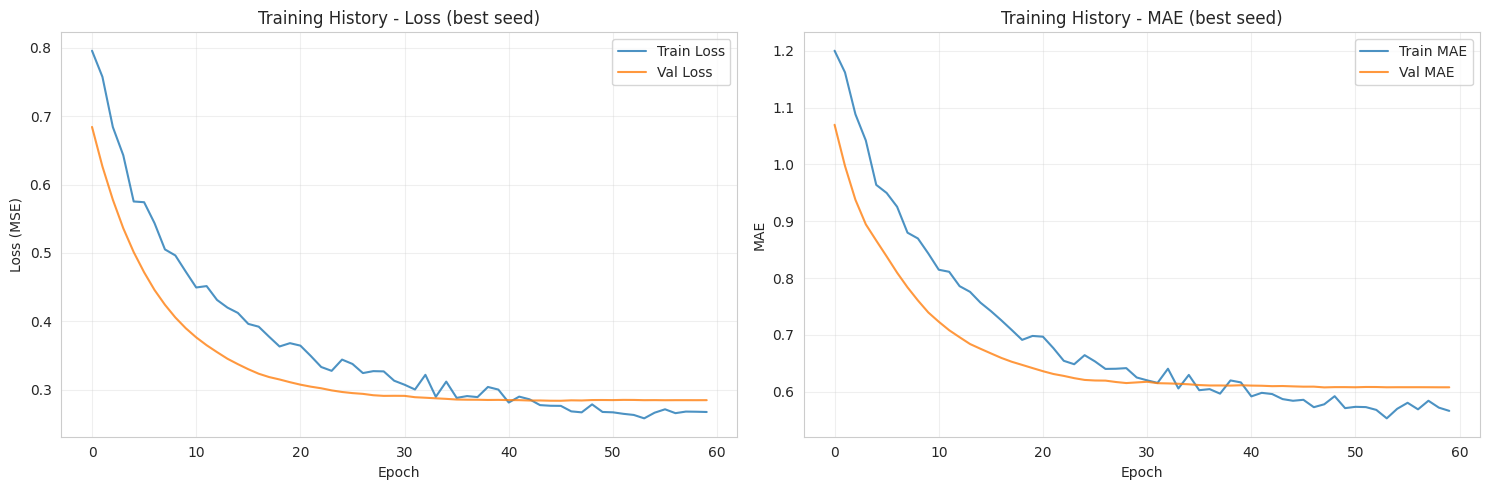

OPENING WEEKEND PREDICTION RESULTS - TINY TEXT-ONLY MLP (5-SEED ENSEMBLE)

Original dollar space:
Mean Absolute Error:
  Train: $17,793,588
  Test:  $20,561,230

Root Mean Squared Error:
  Train: $28,521,351
  Test:  $33,901,226

R² Score:
  Train: 0.6253
  Test:  0.3759

Log space:
MAE:
  Train: 0.4612
  Test:  0.5402

R² Score:
  Train: 0.6021
  Test:  0.4696


In [ ]:
def make_tiny_text_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=14,
            restore_best_weights=True,
            verbose=0,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-5,
            verbose=0,
        ),
    ]

def create_tiny_text_model(
    text_dim,
    learning_rate=1e-4,
    l2_strength=2e-3,
    dropout_rate=0.10,
):
    inputs = tf.keras.layers.Input(shape=(text_dim,), name="text_input")

    x = tf.keras.layers.Dense(
        16,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
        kernel_initializer="he_normal",
    )(inputs)
    x = tf.keras.layers.Dropout(dropout_rate)(x)

    outputs = tf.keras.layers.Dense(1, name="output")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="tiny_text_model")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model

print("Training Opening Weekend Model (5-seed tiny text-only ensemble)...")

tiny_text_fit = fit_keras_regressor(
    build_model_fn=lambda: create_tiny_text_model(
        text_dim=X_text_train_reduced.shape[1],
        learning_rate=3e-4,
        l2_strength=7.5e-4,
        dropout_rate=0.03,
    ),
    X_train_fit=X_text_tr,
    y_train_fit=y_opening_tr,
    X_val_fit=X_text_val,
    y_val_fit=y_opening_val,
    eval_train_inputs=X_text_train_reduced,
    eval_test_inputs=X_text_test_reduced,
    seeds=ensemble_seeds,
    model_label="Tiny Text-Only MLP",
    epochs=300,
    batch_size=8,
    verbose=0,
    sample_weight_fit=sample_weight_text,
    callbacks_fn=make_tiny_text_callbacks,
)

tiny_text_models = tiny_text_fit["models"]
tiny_text_model = tiny_text_fit["best_model"]
history_opening = tiny_text_fit["best_history"]

print("\n✓ Training complete")
print(f"Best seed: {tiny_text_fit['best_seed']}")
print(f"Best validation loss across seeds: {tiny_text_fit['best_val_loss']:.4f}")
print(f"Average validation loss across seeds: {tiny_text_fit['avg_val_loss']:.4f}")
print("Stored best single model in: tiny_text_model")
print("Stored all fitted seed models in: tiny_text_models")

plot_training_history(history_opening)

tiny_text_results = collect_ensemble_results(
    models_list=tiny_text_models,
    X_train=X_text_train_reduced,
    X_test=X_text_test_reduced,
    y_train_true=y_opening_train,
    y_test_true=y_opening_test,
    y_train_log_true=y_opening_log_train,
    y_test_log_true=y_opening_log_test,
    y_log_mean=y_opening_mean,
    y_log_std=y_opening_std,
    clip_lo=clip_lo,
    clip_hi=clip_hi,
    model_name="Tiny Text-Only MLP (5-seed ensemble)",
)

all_model_results = upsert_model_result(tiny_text_results)
print_detailed_results(tiny_text_results)

## 11. Modeling Approach 2 - Residual Text plus tabular data (ResNet Model) Multi-Model

Includes hyperparameter tuning on the most promising configurations

In [ ]:
def residual_mlp_block(x, hidden_dim, dropout, l2_strength, block_name):
    shortcut = x

    h = layers.LayerNormalization(name=f"{block_name}_ln1")(x)
    h = layers.Dense(
        hidden_dim,
        activation="gelu",
        kernel_regularizer=regularizers.l2(l2_strength),
        kernel_initializer="he_normal",
        name=f"{block_name}_dense1",
    )(h)
    h = layers.Dropout(dropout, name=f"{block_name}_drop1")(h)

    h = layers.Dense(
        int(x.shape[-1]),
        activation=None,
        kernel_regularizer=regularizers.l2(l2_strength),
        kernel_initializer="he_normal",
        name=f"{block_name}_dense2",
    )(h)
    h = layers.Dropout(dropout, name=f"{block_name}_drop2")(h)

    return layers.Add(name=f"{block_name}_add")([shortcut, h])

def create_tabtext_resnet_model(
    tab_dim,
    text_dim,
    learning_rate=1.2e-4,
    l2_strength=2e-3,
    dropout=0.15,
    width=96,
    n_blocks=2,
    noise_std=0.0,
):
    tab_input = layers.Input(shape=(tab_dim,), name="tabular")
    text_input = layers.Input(shape=(text_dim,), name="text")

    xtab = layers.LayerNormalization(name="tab_ln")(tab_input)
    xtab = layers.GaussianNoise(noise_std, name="tab_noise")(xtab)
    xtab = layers.Dense(
        48,
        activation="gelu",
        kernel_regularizer=regularizers.l2(l2_strength),
        kernel_initializer="he_normal",
        name="tab_dense",
    )(xtab)
    xtab = layers.Dropout(dropout, name="tab_drop")(xtab)

    xtext = layers.LayerNormalization(name="text_ln")(text_input)
    xtext = layers.GaussianNoise(noise_std, name="text_noise")(xtext)
    xtext = layers.Dense(
        48,
        activation="gelu",
        kernel_regularizer=regularizers.l2(l2_strength),
        kernel_initializer="he_normal",
        name="text_dense",
    )(xtext)
    xtext = layers.Dropout(dropout, name="text_drop")(xtext)

    x = layers.Concatenate(name="fuse")([xtab, xtext])

    x = layers.Dense(
        width,
        activation=None,
        kernel_regularizer=regularizers.l2(l2_strength),
        kernel_initializer="he_normal",
        name="stem_dense",
    )(x)

    for i in range(n_blocks):
        x = residual_mlp_block(
            x,
            hidden_dim=width * 2,
            dropout=dropout,
            l2_strength=l2_strength,
            block_name=f"resblock_{i+1}",
        )

    x = layers.LayerNormalization(name="head_ln")(x)
    x = layers.Dense(
        24,
        activation="gelu",
        kernel_regularizer=regularizers.l2(l2_strength),
        kernel_initializer="he_normal",
        name="head_dense",
    )(x)
    x = layers.Dropout(dropout, name="head_drop")(x)

    output = layers.Dense(1, name="output")(x)

    model = models.Model(
        inputs=[tab_input, text_input],
        outputs=output,
        name="tabtext_resnet_model",
    )

    model.compile(
        optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse"), "mae"],
    )
    return model

In [ ]:
# ------------------------------------------------------------
# ResNet hyperparameter tuning
# Tune on validation only, then keep the best ensemble fit
# ------------------------------------------------------------

# Short list of prior winners and runner ups
resnet_candidates = [
    # strongest current stage-1 winner
    {"width": 120, "n_blocks": 2, "dropout": 0.15, "l2_strength": 1.5e-3, "learning_rate": 1.6e-4, "batch_size": 8, "noise_std": 0.0},
    # second-best current width-120 variant
    {"width": 120, "n_blocks": 2, "dropout": 0.14, "l2_strength": 1.5e-3, "learning_rate": 1.6e-4, "batch_size": 8, "noise_std": 0.0},
    # width-120 with slightly stronger l2, very competitive
    {"width": 120, "n_blocks": 2, "dropout": 0.15, "l2_strength": 2.0e-3, "learning_rate": 1.6e-4, "batch_size": 8, "noise_std": 0.0},
    # one missing cross-combination worth checking
    {"width": 120, "n_blocks": 2, "dropout": 0.14, "l2_strength": 2.0e-3, "learning_rate": 1.6e-4, "batch_size": 8, "noise_std": 0.0},
    # latest filtered-benchmark stage-2 winner
    {"width": 112, "n_blocks": 2, "dropout": 0.14, "l2_strength": 1.5e-3, "learning_rate": 1.6e-4, "batch_size": 8, "noise_std": 0.0},
    # strongest historical 112 anchor
    {"width": 112, "n_blocks": 2, "dropout": 0.15, "l2_strength": 2.0e-3, "learning_rate": 1.6e-4, "batch_size": 8, "noise_std": 0.0},
]

print(f"ResNet local refinement candidates: {len(resnet_candidates)}")

def build_resnet_from_params(params):
    return create_tabtext_resnet_model(
        tab_dim=X_resnet_train_scaled.shape[1],
        text_dim=X_text_train_reduced.shape[1],
        learning_rate=params["learning_rate"],
        l2_strength=params["l2_strength"],
        dropout=params["dropout"],
        width=params["width"],
        n_blocks=params["n_blocks"],
        noise_std=params["noise_std"],
    )

print("Running ResNet hyperparameter search...")

new_resnet_search = run_nn_param_search(
    candidates=resnet_candidates,
    build_model_from_params=build_resnet_from_params,
    X_train_fit=[X_resnet_tr, X_text_tr],
    y_train_fit=y_opening_tr,
    X_val_fit=[X_resnet_val, X_text_val],
    y_val_fit=y_opening_val,
    y_val_log_true=y_opening_log_train[val_idx_nn],
    eval_train_inputs=[X_resnet_train_scaled, X_text_train_reduced],
    eval_test_inputs=[X_resnet_test_scaled, X_text_test_reduced],
    y_log_mean=y_opening_mean,
    y_log_std=y_opening_std,
    sample_weight_fit=sample_weight_nn,
    fast_seed=11,
    top_k=3,
    final_seeds=(11, 22, 33),
    search_epochs=220,
    final_epochs=360,
    verbose=0,
    model_label_prefix="ResNet-style tab+text NN",
)


ResNet local refinement candidates: 6
Running ResNet hyperparameter search...
Fast search over 6 candidates
  [1/6] training stage1: {'width': 120, 'n_blocks': 2, 'dropout': 0.15, 'l2_strength': 0.0015, 'learning_rate': 0.00016, 'batch_size': 8, 'noise_std': 0.0}
  [2/6] training stage1: {'width': 120, 'n_blocks': 2, 'dropout': 0.14, 'l2_strength': 0.0015, 'learning_rate': 0.00016, 'batch_size': 8, 'noise_std': 0.0}
  [3/6] training stage1: {'width': 120, 'n_blocks': 2, 'dropout': 0.15, 'l2_strength': 0.002, 'learning_rate': 0.00016, 'batch_size': 8, 'noise_std': 0.0}
  [4/6] training stage1: {'width': 120, 'n_blocks': 2, 'dropout': 0.14, 'l2_strength': 0.002, 'learning_rate': 0.00016, 'batch_size': 8, 'noise_std': 0.0}
  [5/6] training stage1: {'width': 112, 'n_blocks': 2, 'dropout': 0.14, 'l2_strength': 0.0015, 'learning_rate': 0.00016, 'batch_size': 8, 'noise_std': 0.0}
  [6/6] training stage1: {'width': 112, 'n_blocks': 2, 'dropout': 0.15, 'l2_strength': 0.002, 'learning_rate': 0.0

,split_sig,params_key,candidate_id,width,n_blocks,dropout,l2_strength,learning_rate,batch_size,noise_std,stage1_best_val_loss,stage1_val_mae_log,stage1_val_r2_log
0,0044e3c9c85647577758c7ef,c35264b7265456505d43,4,120,2,0.14,0.0020,0.00016,8,0.0,0.695191,0.442501,0.638784
1,0044e3c9c85647577758c7ef,dbea2bcaed18b304b671,2,120,2,0.14,0.0015,0.00016,8,0.0,0.736229,0.439127,0.638609
2,0044e3c9c85647577758c7ef,196e0addb2e2c7afc5c0,1,120,2,0.15,0.0015,0.00016,8,0.0,0.751618,0.441102,0.637760
3,0044e3c9c85647577758c7ef,87edb5b727ea2c5dcccb,3,120,2,0.15,0.0020,0.00016,8,0.0,0.711233,0.455121,0.628399
4,0044e3c9c85647577758c7ef,70b4bca16cb0d8bb4ebd,5,112,2,0.14,0.0015,0.00016,8,0.0,0.818736,0.508231,0.490541
5,0044e3c9c85647577758c7ef,a0c90bbdd94140a0f77b,6,112,2,0.15,0.0020,0.00016,8,0.0,0.796167,0.517527,0.475645



Proceeding to stage 2 for top_k=3 candidates


,split_sig,params_key,candidate_id,width,n_blocks,dropout,l2_strength,learning_rate,batch_size,noise_std,stage1_best_val_loss,stage1_val_mae_log,stage1_val_r2_log
0,0044e3c9c85647577758c7ef,c35264b7265456505d43,4,120,2,0.14,0.0020,0.00016,8,0.0,0.695191,0.442501,0.638784
1,0044e3c9c85647577758c7ef,dbea2bcaed18b304b671,2,120,2,0.14,0.0015,0.00016,8,0.0,0.736229,0.439127,0.638609
2,0044e3c9c85647577758c7ef,196e0addb2e2c7afc5c0,1,120,2,0.15,0.0015,0.00016,8,0.0,0.751618,0.441102,0.637760



  [stage2 rank 1/3] refit/check cache: {'width': 120, 'n_blocks': 2, 'dropout': 0.14, 'l2_strength': 0.002, 'learning_rate': 0.00016, 'batch_size': 8, 'noise_std': 0.0}
  Seed 11
  Seed 22
  Seed 33
Saved cached fit for ResNet-style tab+text NN tuned candidate 1 to nn_cache/nn/0044e3c9c85647577758c7ef_c35264b7265456505d43

  [stage2 rank 2/3] refit/check cache: {'width': 120, 'n_blocks': 2, 'dropout': 0.14, 'l2_strength': 0.0015, 'learning_rate': 0.00016, 'batch_size': 8, 'noise_std': 0.0}
  Seed 11
  Seed 22
  Seed 33
Saved cached fit for ResNet-style tab+text NN tuned candidate 2 to nn_cache/nn/0044e3c9c85647577758c7ef_dbea2bcaed18b304b671

  [stage2 rank 3/3] refit/check cache: {'width': 120, 'n_blocks': 2, 'dropout': 0.15, 'l2_strength': 0.0015, 'learning_rate': 0.00016, 'batch_size': 8, 'noise_std': 0.0}
  Seed 11
  Seed 22
  Seed 33
Saved cached fit for ResNet-style tab+text NN tuned candidate 3 to nn_cache/nn/0044e3c9c85647577758c7ef_196e0addb2e2c7afc5c0

=== Stage 2 ranked ===

,split_sig,params_key,candidate_id,width,n_blocks,dropout,l2_strength,learning_rate,batch_size,noise_std,stage1_val_r2_log,stage1_val_mae_log,stage2_best_seed,stage2_best_val_loss,stage2_avg_val_loss,stage2_val_mae_log,stage2_val_r2_log,loaded_from_cache
0,0044e3c9c85647577758c7ef,196e0addb2e2c7afc5c0,1,120,2,0.15,0.0015,0.00016,8,0.0,0.637760,0.441102,11,0.408510,0.473902,0.447611,0.644635,False
1,0044e3c9c85647577758c7ef,c35264b7265456505d43,4,120,2,0.14,0.0020,0.00016,8,0.0,0.638784,0.442501,11,0.373658,0.439156,0.450643,0.642507,False
2,0044e3c9c85647577758c7ef,dbea2bcaed18b304b671,2,120,2,0.14,0.0015,0.00016,8,0.0,0.638609,0.439127,22,0.492195,0.515324,0.453309,0.634287,False



Selected best params from stage 2:
{'width': 120, 'n_blocks': 2, 'dropout': 0.15, 'l2_strength': 0.0015, 'learning_rate': 0.00016, 'batch_size': 8, 'noise_std': 0.0}



Best ResNet params selected:
{'width': 120, 'n_blocks': 2, 'dropout': 0.15, 'l2_strength': 0.0015, 'learning_rate': 0.00016, 'batch_size': 8, 'noise_std': 0.0}

Best ResNet model structure:


Model: "tabtext_resnet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tabular             │ (None, 93)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text (InputLayer)   │ (None, 34)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_ln              │ (None, 93)        │        186 │ tabular[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_ln             │ (None, 34)        │         68 │ text[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_noise           │ (None, 93)        │          0 │ tab_ln[0][0]      │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_noise          │ (None, 34)        │          0 │ text_ln[0][0]     │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dense (Dense)   │ (None, 48)        │      4,512 │ tab_noise[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_dense (Dense)  │ (None, 48)        │      1,680 │ text_noise[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_drop (Dropout)  │ (None, 48)        │          0 │ tab_dense[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_drop (Dropout) │ (None, 48)        │          0 │ text_dense[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fuse (Concatenate)  │ (None, 96)        │          0 │ tab_drop[0][0],   │
│                     │                   │            │ text_drop[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_dense (Dense)  │ (None, 120)       │     11,640 │ fuse[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resblock_1_ln1      │ (None, 120)       │        240 │ stem_dense[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resblock_1_dense1   │ (None, 240)       │     29,040 │ resblock_1_ln1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resblock_1_drop1    │ (None, 240)       │          0 │ resblock_1_dense… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resblock_1_dense2   │ (None, 120)       │     28,920 │ resblock_1_drop1… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resblock_1_drop2    │ (None, 120)       │          0 │ resblock_1_dense… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resblock_1_add      │ (None, 120)       │          0 │ stem_dense[0][0], │
│ (Add)               │                   │            │ resblock_1_drop2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resblock_2_ln1      │ (None, 120)       │        240 │ resblock_1_add[0

 Total params: 137,655 (537.71 KB)

 Trainable params: 137,655 (537.71 KB)

 Non-trainable params: 0 (0.00 B)

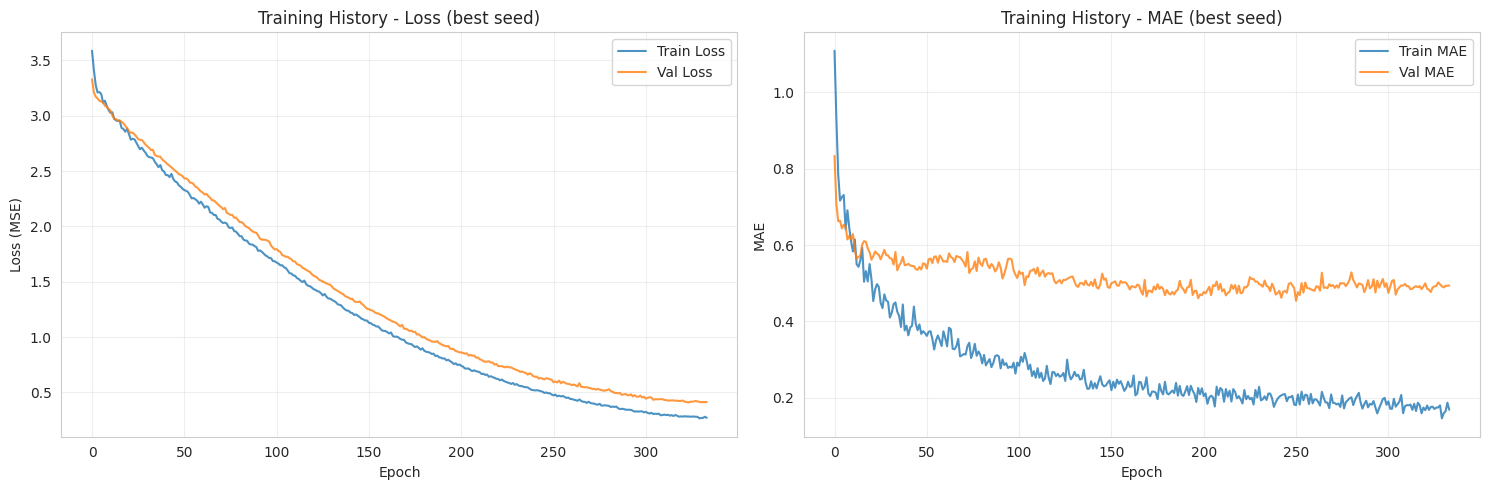

OPENING WEEKEND PREDICTION RESULTS - RESNET-STYLE TAB+TEXT NN (FULL CURRENT TAB SET, 3-SEED ENSEMBLE)

Original dollar space:
Mean Absolute Error:
  Train: $5,190,464
  Test:  $18,793,602

Root Mean Squared Error:
  Train: $11,631,653
  Test:  $28,818,743

R² Score:
  Train: 0.9377
  Test:  0.5490

Log space:
MAE:
  Train: 0.1234
  Test:  0.4890

R² Score:
  Train: 0.9338
  Test:  0.5861


In [ ]:
resnet_search = merge_search_objects(
    globals().get("resnet_search", None),
    new_resnet_search,
)

resnet_tuning_stage1_df = resnet_search["stage1_df"]
resnet_tuning_stage2_df = resnet_search["stage2_df"]
best_resnet_params = resnet_search["best_params"]
tabtext_resnet_fit = resnet_search["best_fit"]

print("\nBest ResNet params selected:")
print(best_resnet_params)

tabtext_resnet_model = create_tabtext_resnet_model(
    tab_dim=X_resnet_train_scaled.shape[1],
    text_dim=X_text_train_reduced.shape[1],
    learning_rate=best_resnet_params["learning_rate"],
    l2_strength=best_resnet_params["l2_strength"],
    dropout=best_resnet_params["dropout"],
    width=best_resnet_params["width"],
    n_blocks=best_resnet_params["n_blocks"],
    noise_std=best_resnet_params["noise_std"],
)

print("\nBest ResNet model structure:")
tabtext_resnet_model.summary()

tabtext_resnet_best = tabtext_resnet_fit["best_model"]
tabtext_resnet_history = tabtext_resnet_fit["best_history"]

plot_training_history(tabtext_resnet_history)

tabtext_resnet_results = collect_ensemble_results(
    models_list=tabtext_resnet_fit["models"],
    X_train=[X_resnet_train_scaled, X_text_train_reduced],
    X_test=[X_resnet_test_scaled, X_text_test_reduced],
    y_train_true=y_opening_train,
    y_test_true=y_opening_test,
    y_train_log_true=y_opening_log_train,
    y_test_log_true=y_opening_log_test,
    y_log_mean=y_opening_mean,
    y_log_std=y_opening_std,
    clip_lo=clip_lo,
    clip_hi=clip_hi,
    model_name="ResNet-style tab+text NN (full current tab set, 3-seed ensemble)",
)

all_model_results = upsert_model_result(tabtext_resnet_results)
print_detailed_results(tabtext_resnet_results)


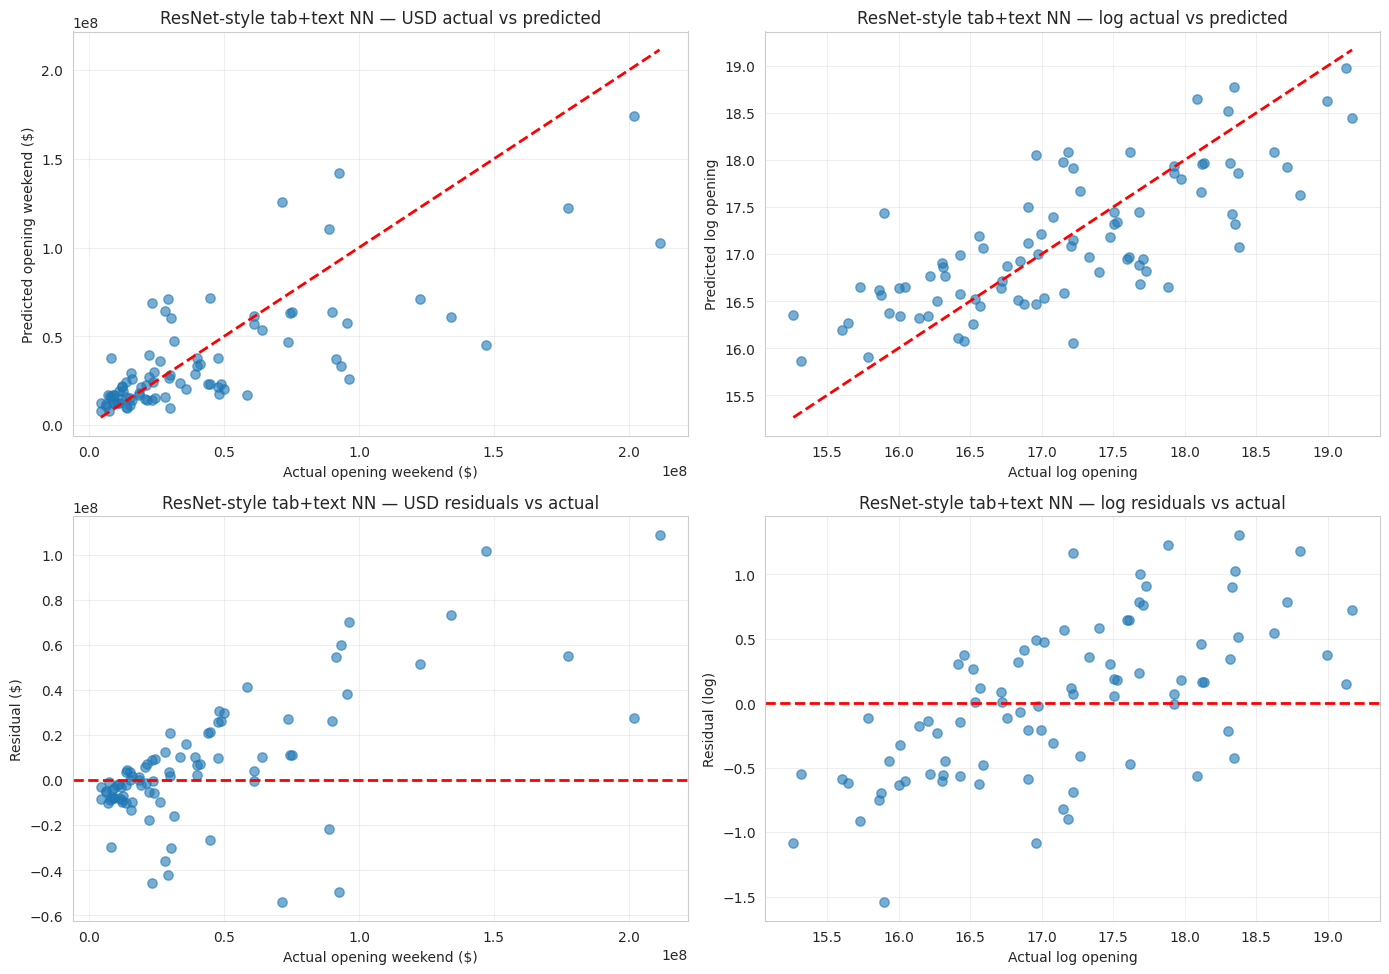


Top 20 worst predicted movies for ResNet-style tab+text NN (sorted by abs_log_error)


,tmdb_id,title,release_date_us,distributor,genres,rating,youtube_id,actual_usd,pred_usd,resid_usd,abs_usd_error,pct_error,abs_pct_error,actual_log,pred_log,resid_log,abs_log_error,direction,release_year,month,day_of_week,runtime_min,rating_R,rating_PG_13,genre_drama,genre_adventure,yt_sent_std_early,yt_sent_mean_early,yt_comment_unique_ratio_early,yt_comment_exclamation_share_early,is_wednesday_release,is_christmas_corridor
0,567609,Ready or Not,2019-08-21,Mythology Entertainment,"Horror, Comedy",R,lsGU_h_0Qiw,8015590.0,37576332.0,-29560742.0,29560742.0,368.790588,368.790588,15.896899,17.441885,-1.544986,1.544986,overpredicted,2019,8,2,95.0,1,0,0,0,0.000000,0.000000,0.000000,0.000000,1,0
1,475557,Joker,2019-10-01,Warner Bros,"Crime, Thriller, Drama",R,zAGVQLHvwOY,96202336.0,26039638.0,70162696.0,70162696.0,-72.932426,72.932426,18.381964,17.075130,1.306833,1.306833,underpredicted,2019,10,1,122.0,1,0,1,0,0.000000,0.000000,0.000000,0.000000,0,0
2,677179,Creed III,2023-03-01,MGM/Amazon,"Drama, Action",PG-13,xTaIZo8OJYE,58370008.0,17116406.0,41253600.0,41253600.0,-70.676025,70.676025,17.882313,16.655548,1.226765,1.226765,underpredicted,2023,3,2,116.0,0,1,1,0,0.617801,0.241793,0.920110,0.204301,1,0
3,967941,Wicked: For Good,2025-11-19,Universal,"Fantasy, Adventure, Romance",PG,R2Xubj7lazE,147004640.0,45281036.0,101723600.0,101723600.0,-69.197540,69.197540,18.805975,17.628399,1.177576,1.177576,underpredicted,2025,11,2,137.0,0,0,0,1,0.670062,0.311008,0.973749,0.258427,1,0
4,718930,Bullet Train,2022-08-03,87North Productions,"Action, Comedy, Thriller",R,EGeJczJvWns,30030156.0,9349564.0,20680592.0,20680592.0,-68.866081,68.866081,17.217712,16.050840,1.166872,1.166872,underpredicted,2022,8,2,126.0,1,0,0,0,0.601805,0.587051,0.802071,0.195402,1,0
5,460465,Mortal Kombat,2021-04-07,Atomic Monster,"Action, Fantasy, Adventure",R,NYH2sLid0Zc,23302504.0,68913376.0,-45610872.0,45610872.0,195.733765,195.733765,16.964071,18.048361,-1.084290,1.084290,overpredicted,2021,4,2,110.0,1,0,0,1,0.606235,0.221735,0.950281,0.276596,1,0
6,1325678,Sarah's Oil,2025-11-06,MGM/Amazon,Drama,PG,lcEOKJm_aLY,4261446.0,12589207.0,-8327761.0,8327761.0,195.421021,195.421021,15.265120,16.348351,-1.083231,1.083231,overpredicted,2025,11,3,103.0,0,0,1,0,0.725089,0.071836,0.997211,0.159420,0,0
7,1160164,TAYLOR SWIFT | THE ERAS TOUR,2023-10-13,Taylor Swift Productions,Music,PG-13,KudedLV0tP0,93224752.0,33372480.0,59852272.0,59852272.0,-64.202126,64.202126,18.350523,17.323242,1.027281,1.027281,underpredicted,2023,10,4,169.0,0,1,0,0,0.557075,0.563269,0.959677,0.270833,0,0
8,1233413,Sinners,2025-04-16,Warner Bros,"Horror, Action, Thriller",R,0z8GC0VScco,48007468.0,17611368.0,30396100.0,30396100.0,-63.315361,63.315361,17.686867,16.684055,1.002811,1.002811,underpredicted,2025,4,2,138.0,1,0,0,0,0.358044,0.029899,1.000000,0.055556,1,0
9,559907,The Green Knight,2021-07-29,A24,"Adventure, Drama, Fantasy",R,sS6ksY8xWCY,6790917.0,16971094.0,-10180177.0,10180177.0,149.908722,149.908722,15.731096,16.647022,-0.915926,0.915926,overpredicted,2021,7,3,130.0,1,0,1,1,0.644861,0.140921,0.993717,0.134328,0,0


In [ ]:
analyze_give_worst_N_resnet = plot_regression_diagnostics(
    tabtext_resnet_results,
    y_opening_test,
    y_opening_log_test,
    "ResNet-style tab+text NN",
    show_worst=True,
    top_n=20,
    sort_by="abs_log_error",
    df_test_meta=df_test_meta,
    df_test_key_features=df_test_key_features,
)

##12. Modeling Approach 3 - Late-Fusion Transformer

Late-fusion Transformer:
- Transformer attends only over text/comment tokens
- Compact tabular features go through a separate MLP branch
- The two branches are fused late for prediction

This replaces the older scalar-tab tokenized Transformer.

In [ ]:
# ------------------------------------------------------------
# Late-fusion transformer:
# text/comment transformer + separate tabular MLP branch
# ------------------------------------------------------------

class LFScalarCLSToken(tf.keras.layers.Layer):
    def __init__(self, token_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_dim = token_dim

    def build(self, input_shape):
        self.cls = self.add_weight(
            name="cls",
            shape=(1, 1, self.token_dim),
            initializer="zeros",
            trainable=True,
        )

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        return tf.broadcast_to(self.cls, [batch_size, 1, self.token_dim])


class LFAddPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_tokens, token_dim, **kwargs):
        super().__init__(**kwargs)
        self.max_tokens = max_tokens
        self.token_dim = token_dim

    def build(self, input_shape):
        self.pos_embedding = self.add_weight(
            name="pos_embedding",
            shape=(self.max_tokens, self.token_dim),
            initializer="random_normal",
            trainable=True,
        )

    def call(self, inputs):
        seq_len = tf.shape(inputs)[1]
        return inputs + self.pos_embedding[None, :seq_len, :]


def lf_transformer_encoder_block(x, token_dim, num_heads, ff_dim, dropout, l2_strength, block_name):
    attn_out = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=token_dim // num_heads,
        dropout=dropout,
        name=f"{block_name}_mha",
    )(x, x)

    x = tf.keras.layers.Add(name=f"{block_name}_attn_add")([x, attn_out])
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6, name=f"{block_name}_attn_ln")(x)

    ff = tf.keras.layers.Dense(
        ff_dim,
        activation="gelu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
        name=f"{block_name}_ff1",
    )(x)
    ff = tf.keras.layers.Dropout(dropout, name=f"{block_name}_ff_dropout")(ff)
    ff = tf.keras.layers.Dense(
        token_dim,
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
        name=f"{block_name}_ff2",
    )(ff)

    x = tf.keras.layers.Add(name=f"{block_name}_ff_add")([x, ff])
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6, name=f"{block_name}_ff_ln")(x)
    return x


def lf_build_text_token(raw_input, token_dim, l2_strength, name_prefix):
    x = tf.keras.layers.LayerNormalization(name=f"{name_prefix}_input_ln")(raw_input)
    x = tf.keras.layers.Dense(
        token_dim,
        activation=None,
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
        name=f"{name_prefix}_proj",
    )(x)
    return x


def create_late_fusion_transformer_regressor(
    desc_dim,
    video_dim,
    comment_dim,
    comment_bin_dim,
    num_tab_features,
    n_comment_bins=4,
    token_dim=32,
    num_heads=2,
    num_transformer_blocks=2,
    ff_dim=128,
    dropout=0.10,
    l2_strength=1.0e-3,
    learning_rate=8e-5,
    tab_hidden_1=64,
    tab_hidden_2=32,
    use_opening_theaters_skip=USE_THEATERS_FOR_OPENING,
):
    desc_input = tf.keras.layers.Input(shape=(desc_dim,), name="desc_embedding")
    video_input = tf.keras.layers.Input(shape=(video_dim,), name="video_embedding")
    comment_input = tf.keras.layers.Input(shape=(comment_dim,), name="comment_embedding")

    comment_bin_inputs = [
        tf.keras.layers.Input(shape=(comment_bin_dim,), name=f"comment_bin_{i}_embedding")
        for i in range(n_comment_bins)
    ]

    tab_input = tf.keras.layers.Input(shape=(num_tab_features,), name="tabular_features")
    opening_theaters_input = tf.keras.layers.Input(shape=(1,), name="opening_theaters_scalar")

    has_video_input = tf.keras.layers.Input(shape=(1,), name="has_video")
    has_comment_input = tf.keras.layers.Input(shape=(1,), name="has_comment")
    comment_bin_mask_inputs = [
        tf.keras.layers.Input(shape=(1,), name=f"has_comment_bin_{i}")
        for i in range(n_comment_bins)
    ]

    # text/comment tokens only
    desc_token = lf_build_text_token(desc_input, token_dim, l2_strength, "desc")
    desc_token = tf.keras.layers.Reshape((1, token_dim), name="desc_token")(desc_token)

    video_token = lf_build_text_token(video_input, token_dim, l2_strength, "video")
    video_token = tf.keras.layers.Lambda(
        lambda xs: xs[0] * tf.cast(xs[1], xs[0].dtype),
        name="apply_video_mask",
    )([video_token, has_video_input])
    video_token = tf.keras.layers.Reshape((1, token_dim), name="video_token")(video_token)

    comment_token = lf_build_text_token(comment_input, token_dim, l2_strength, "comment")
    comment_token = tf.keras.layers.Lambda(
        lambda xs: xs[0] * tf.cast(xs[1], xs[0].dtype),
        name="apply_comment_mask",
    )([comment_token, has_comment_input])
    comment_token = tf.keras.layers.Reshape((1, token_dim), name="comment_token")(comment_token)

    comment_tokens = []
    for i, (comment_input_i, comment_mask_i) in enumerate(zip(comment_bin_inputs, comment_bin_mask_inputs)):
        token = lf_build_text_token(comment_input_i, token_dim, l2_strength, f"comment_bin_{i}")
        token = tf.keras.layers.Lambda(
            lambda xs: xs[0] * tf.cast(xs[1], xs[0].dtype),
            name=f"apply_comment_bin_{i}_mask",
        )([token, comment_mask_i])
        token = tf.keras.layers.Reshape((1, token_dim), name=f"comment_bin_{i}_token")(token)
        comment_tokens.append(token)

    text_tokens = tf.keras.layers.Concatenate(axis=1, name="text_tokens")(
        [desc_token, video_token, comment_token] + comment_tokens
    )

    cls_token = LFScalarCLSToken(token_dim=token_dim, name="cls_token")(text_tokens)
    x_text = tf.keras.layers.Concatenate(axis=1, name="tokens_with_cls")([cls_token, text_tokens])

    total_text_tokens = 1 + 3 + n_comment_bins
    x_text = LFAddPositionEmbedding(
        max_tokens=total_text_tokens,
        token_dim=token_dim,
        name="pos_embedding",
    )(x_text)
    x_text = tf.keras.layers.Dropout(dropout, name="token_dropout")(x_text)

    for i in range(num_transformer_blocks):
        x_text = lf_transformer_encoder_block(
            x=x_text,
            token_dim=token_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            dropout=dropout,
            l2_strength=l2_strength,
            block_name=f"transformer_{i+1}",
        )

    cls_out = tf.keras.layers.Lambda(lambda t: t[:, 0, :], name="cls_pool")(x_text)

    # separate tabular MLP branch
    x_tab = tf.keras.layers.LayerNormalization(name="tab_input_ln")(tab_input)
    x_tab = tf.keras.layers.Dense(
        tab_hidden_1,
        activation="gelu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
        name="tab_dense_1",
    )(x_tab)
    x_tab = tf.keras.layers.Dropout(dropout, name="tab_dropout_1")(x_tab)

    x_tab = tf.keras.layers.Dense(
        tab_hidden_2,
        activation="gelu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
        name="tab_dense_2",
    )(x_tab)

    fused = tf.keras.layers.Concatenate(name="late_fusion")([cls_out, x_tab])

    head = tf.keras.layers.Dense(
        64,
        activation="gelu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
        name="head_dense_1",
    )(fused)
    head = tf.keras.layers.Dropout(dropout, name="head_dropout_1")(head)

    head = tf.keras.layers.Dense(
        32,
        activation="gelu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
        name="head_dense_2",
    )(head)

    transformer_pred = tf.keras.layers.Dense(1, name="transformer_pred")(head)

    if use_opening_theaters_skip:
        theaters_skip = tf.keras.layers.Dense(
            1,
            use_bias=False,
            kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
            name="opening_theaters_skip",
        )(opening_theaters_input)

        theaters_resid = tf.keras.layers.Dense(
            4,
            activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
            name="opening_theaters_hidden",
        )(opening_theaters_input)
        theaters_resid = tf.keras.layers.Dense(
            1,
            kernel_regularizer=tf.keras.regularizers.l2(l2_strength),
            name="opening_theaters_resid",
        )(theaters_resid)

        output = tf.keras.layers.Add(name="final_pred")(
            [transformer_pred, theaters_skip, theaters_resid]
        )

        model_inputs = [
            desc_input,
            video_input,
            comment_input,
            *comment_bin_inputs,
            tab_input,
            opening_theaters_input,
            has_video_input,
            has_comment_input,
            *comment_bin_mask_inputs,
        ]
    else:
        output = transformer_pred
        model_inputs = [
            desc_input,
            video_input,
            comment_input,
            *comment_bin_inputs,
            tab_input,
            has_video_input,
            has_comment_input,
            *comment_bin_mask_inputs,
        ]

    model = tf.keras.Model(
        inputs=model_inputs,
        outputs=output,
        name="late_fusion_transformer_regressor",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=[
            "mae",
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        ],
    )
    return model

In [ ]:
def _normalize_search_object(obj):
    """
    Accepts:
      - None
      - dict search object
      - list of dict search objects
    Returns a single merged dict search object.
    """
    if obj is None:
        return None

    if isinstance(obj, dict):
        return obj

    if isinstance(obj, list):
        merged = None
        for item in obj:
            if item is None:
                continue
            if not isinstance(item, dict):
                raise TypeError(f"Unsupported item inside search-object list: {type(item)}")
            merged = merge_search_objects(merged, item)
        return merged

    raise TypeError(f"Unsupported search object type: {type(obj)}")

In [ ]:
# ------------------------------------------------------------
# Late-fusion transformer hyperparameter tuning
# ------------------------------------------------------------

late_fusion_transformer_candidates = [
    # current winner
    {"token_dim": 32, "num_heads": 2, "num_transformer_blocks": 2, "ff_dim": 128, "dropout": 0.10, "l2_strength": 1.0e-3, "learning_rate": 8.0e-5, "batch_size": 20, "tab_hidden_1": 64, "tab_hidden_2": 32},

    # same model, 4 heads
    {"token_dim": 32, "num_heads": 4, "num_transformer_blocks": 2, "ff_dim": 128, "dropout": 0.10, "l2_strength": 1.0e-3, "learning_rate": 8.0e-5, "batch_size": 20, "tab_hidden_1": 64, "tab_hidden_2": 32},

    # same model, slightly higher LR
    {"token_dim": 32, "num_heads": 2, "num_transformer_blocks": 2, "ff_dim": 128, "dropout": 0.10, "l2_strength": 1.0e-3, "learning_rate": 1.0e-4, "batch_size": 20, "tab_hidden_1": 64, "tab_hidden_2": 32},

    # same model, slightly larger tab branch
    {"token_dim": 32, "num_heads": 2, "num_transformer_blocks": 2, "ff_dim": 128, "dropout": 0.10, "l2_strength": 1.0e-3, "learning_rate": 8.0e-5, "batch_size": 20, "tab_hidden_1": 96, "tab_hidden_2": 48},

    # same model, slightly lower dropout
    {"token_dim": 32, "num_heads": 2, "num_transformer_blocks": 2, "ff_dim": 128, "dropout": 0.08, "l2_strength": 1.0e-3, "learning_rate": 8.0e-5, "batch_size": 20, "tab_hidden_1": 64, "tab_hidden_2": 32},
]

def _normalize_search_object(obj):
    """
    Accepts:
      - None
      - dict search object
      - list of dict search objects
    Returns a single merged dict search object.
    """
    if obj is None:
        return None

    if isinstance(obj, dict):
        return obj

    if isinstance(obj, list):
        merged = None
        for item in obj:
            if item is None:
                continue
            if not isinstance(item, dict):
                raise TypeError(f"Unsupported item inside search-object list: {type(item)}")
            merged = merge_search_objects(merged, item)
        return merged

    raise TypeError(f"Unsupported search object type: {type(obj)}")

def build_late_fusion_transformer_from_params(params):
    return create_late_fusion_transformer_regressor(
        desc_dim=X_desc_train.shape[1],
        video_dim=X_video_train.shape[1],
        comment_dim=X_comment_train.shape[1],
        comment_bin_dim=X_comment_bins_train["comment_bin_0"].shape[1],
        num_tab_features=X_tabular_tf_train_scaled.shape[1],
        n_comment_bins=4,
        token_dim=params["token_dim"],
        num_heads=params["num_heads"],
        num_transformer_blocks=params["num_transformer_blocks"],
        ff_dim=params["ff_dim"],
        dropout=params["dropout"],
        l2_strength=params["l2_strength"],
        learning_rate=params["learning_rate"],
        tab_hidden_1=params["tab_hidden_1"],
        tab_hidden_2=params["tab_hidden_2"],
        use_opening_theaters_skip=USE_THEATERS_FOR_OPENING,
    )


if USE_THEATERS_FOR_OPENING:
    late_fusion_train_inputs = [
        X_desc_tr_raw,
        X_video_tr_raw,
        X_comment_tr_raw,
        *X_comment_bin_tr_raw,
        X_tab_tr_tf,
        X_opening_theaters_tr_tf,
        X_video_mask_tr_tf,
        X_comment_mask_tr_tf,
        *X_comment_bin_mask_tr_tf,
    ]
    late_fusion_val_inputs = [
        X_desc_val_raw,
        X_video_val_raw,
        X_comment_val_raw,
        *X_comment_bin_val_raw,
        X_tab_val_tf,
        X_opening_theaters_val_tf,
        X_video_mask_val_tf,
        X_comment_mask_val_tf,
        *X_comment_bin_mask_val_tf,
    ]
    late_fusion_eval_train_inputs = [
        X_desc_train_full_tf,
        X_video_train_full_tf,
        X_comment_train_full_tf,
        *X_comment_bin_train_full_tf,
        X_tab_train_full_tf,
        X_opening_theaters_train_full_tf,
        X_video_mask_train_full_tf,
        X_comment_mask_train_full_tf,
        *X_comment_bin_mask_train_full_tf,
    ]
    late_fusion_eval_test_inputs = [
        X_desc_test_full_tf,
        X_video_test_full_tf,
        X_comment_test_full_tf,
        *X_comment_bin_test_full_tf,
        X_tab_test_full_tf,
        X_opening_theaters_test_full_tf,
        X_video_mask_test_full_tf,
        X_comment_mask_test_full_tf,
        *X_comment_bin_mask_test_full_tf,
    ]
else:
    late_fusion_train_inputs = [
        X_desc_tr_raw,
        X_video_tr_raw,
        X_comment_tr_raw,
        *X_comment_bin_tr_raw,
        X_tab_tr_tf,
        X_video_mask_tr_tf,
        X_comment_mask_tr_tf,
        *X_comment_bin_mask_tr_tf,
    ]
    late_fusion_val_inputs = [
        X_desc_val_raw,
        X_video_val_raw,
        X_comment_val_raw,
        *X_comment_bin_val_raw,
        X_tab_val_tf,
        X_video_mask_val_tf,
        X_comment_mask_val_tf,
        *X_comment_bin_mask_val_tf,
    ]
    late_fusion_eval_train_inputs = [
        X_desc_train_full_tf,
        X_video_train_full_tf,
        X_comment_train_full_tf,
        *X_comment_bin_train_full_tf,
        X_tab_train_full_tf,
        X_video_mask_train_full_tf,
        X_comment_mask_train_full_tf,
        *X_comment_bin_mask_train_full_tf,
    ]
    late_fusion_eval_test_inputs = [
        X_desc_test_full_tf,
        X_video_test_full_tf,
        X_comment_test_full_tf,
        *X_comment_bin_test_full_tf,
        X_tab_test_full_tf,
        X_video_mask_test_full_tf,
        X_comment_mask_test_full_tf,
        *X_comment_bin_mask_test_full_tf,
    ]


print("Running late-fusion transformer hyperparameter search...")

new_transformer_search = run_nn_param_search(
    candidates=late_fusion_transformer_candidates,
    build_model_from_params=build_late_fusion_transformer_from_params,
    X_train_fit=late_fusion_train_inputs,
    y_train_fit=y_opening_tr,
    X_val_fit=late_fusion_val_inputs,
    y_val_fit=y_opening_val,
    y_val_log_true=y_opening_log_train[val_idx_nn],
    eval_train_inputs=late_fusion_eval_train_inputs,
    eval_test_inputs=late_fusion_eval_test_inputs,
    y_log_mean=y_opening_mean,
    y_log_std=y_opening_std,
    sample_weight_fit=None,
    fast_seed=11,
    top_k=2,
    final_seeds=(11, 22, 33),
    search_epochs=220,
    final_epochs=300,
    verbose=0,
    model_label_prefix="Late-fusion transformer",
    model_family=f"late_fusion_transformer_{BENCHMARK_NAME}" if "BENCHMARK_NAME" in globals() else "late_fusion_transformer",
)

existing_transformer_search = globals().get("transformer_search", None)
existing_transformer_search = _normalize_search_object(existing_transformer_search) if "_normalize_search_object" in globals() else existing_transformer_search

transformer_search = merge_search_objects(
    existing_transformer_search,
    new_transformer_search,
)

transformer_tuning_stage1_df = transformer_search["stage1_df"]
transformer_tuning_stage2_df = transformer_search["stage2_df"]
best_transformer_params = new_transformer_search["best_params"]
transformer_fit = new_transformer_search["best_fit"]

print("\nBest late-fusion transformer params selected:")
print(best_transformer_params)

transformer_model = create_late_fusion_transformer_regressor(
    desc_dim=X_desc_train.shape[1],
    video_dim=X_video_train.shape[1],
    comment_dim=X_comment_train.shape[1],
    comment_bin_dim=X_comment_bins_train["comment_bin_0"].shape[1],
    num_tab_features=X_tabular_tf_train_scaled.shape[1],
    n_comment_bins=4,
    token_dim=best_transformer_params["token_dim"],
    num_heads=best_transformer_params["num_heads"],
    num_transformer_blocks=best_transformer_params["num_transformer_blocks"],
    ff_dim=best_transformer_params["ff_dim"],
    dropout=best_transformer_params["dropout"],
    l2_strength=best_transformer_params["l2_strength"],
    learning_rate=best_transformer_params["learning_rate"],
    tab_hidden_1=best_transformer_params["tab_hidden_1"],
    tab_hidden_2=best_transformer_params["tab_hidden_2"],
    use_opening_theaters_skip=USE_THEATERS_FOR_OPENING,
)

Running late-fusion transformer hyperparameter search...
Fast search over 5 candidates
  [1/5] training stage1: {'token_dim': 32, 'num_heads': 2, 'num_transformer_blocks': 2, 'ff_dim': 128, 'dropout': 0.1, 'l2_strength': 0.001, 'learning_rate': 8e-05, 'batch_size': 20, 'tab_hidden_1': 64, 'tab_hidden_2': 32}
  [2/5] training stage1: {'token_dim': 32, 'num_heads': 4, 'num_transformer_blocks': 2, 'ff_dim': 128, 'dropout': 0.1, 'l2_strength': 0.001, 'learning_rate': 8e-05, 'batch_size': 20, 'tab_hidden_1': 64, 'tab_hidden_2': 32}
  [3/5] training stage1: {'token_dim': 32, 'num_heads': 2, 'num_transformer_blocks': 2, 'ff_dim': 128, 'dropout': 0.1, 'l2_strength': 0.001, 'learning_rate': 0.0001, 'batch_size': 20, 'tab_hidden_1': 64, 'tab_hidden_2': 32}
  [4/5] training stage1: {'token_dim': 32, 'num_heads': 2, 'num_transformer_blocks': 2, 'ff_dim': 128, 'dropout': 0.1, 'l2_strength': 0.001, 'learning_rate': 8e-05, 'batch_size': 20, 'tab_hidden_1': 96, 'tab_hidden_2': 48}
  [5/5] training sta

,split_sig,params_key,candidate_id,token_dim,num_heads,num_transformer_blocks,ff_dim,dropout,l2_strength,learning_rate,batch_size,tab_hidden_1,tab_hidden_2,stage1_best_val_loss,stage1_val_mae_log,stage1_val_r2_log
0,0044e3c9c85647577758c7ef,03d8a15396180638b8bd,4,32,2,2,128,0.10,0.001,0.00008,20,96,48,1.084806,0.553215,0.391595
1,0044e3c9c85647577758c7ef,09a2e884ff89973d1212,3,32,2,2,128,0.10,0.001,0.00010,20,64,32,1.086971,0.610217,0.282408
2,0044e3c9c85647577758c7ef,bf116192f8e1e6683709,2,32,4,2,128,0.10,0.001,0.00008,20,64,32,1.103289,0.610307,0.280338
3,0044e3c9c85647577758c7ef,9463a83626d5560d1d44,1,32,2,2,128,0.10,0.001,0.00008,20,64,32,1.103160,0.613627,0.280068
4,0044e3c9c85647577758c7ef,a3cce0c31e8419f9eea1,5,32,2,2,128,0.08,0.001,0.00008,20,64,32,1.109318,0.626499,0.259914



Proceeding to stage 2 for top_k=2 candidates


,split_sig,params_key,candidate_id,token_dim,num_heads,num_transformer_blocks,ff_dim,dropout,l2_strength,learning_rate,batch_size,tab_hidden_1,tab_hidden_2,stage1_best_val_loss,stage1_val_mae_log,stage1_val_r2_log
0,0044e3c9c85647577758c7ef,03d8a15396180638b8bd,4,32,2,2,128,0.1,0.001,0.00008,20,96,48,1.084806,0.553215,0.391595
1,0044e3c9c85647577758c7ef,09a2e884ff89973d1212,3,32,2,2,128,0.1,0.001,0.00010,20,64,32,1.086971,0.610217,0.282408



  [stage2 rank 1/2] refit/check cache: {'token_dim': 32, 'num_heads': 2, 'num_transformer_blocks': 2, 'ff_dim': 128, 'dropout': 0.1, 'l2_strength': 0.001, 'learning_rate': 8e-05, 'batch_size': 20, 'tab_hidden_1': 96, 'tab_hidden_2': 48}
  Seed 11
  Seed 22
  Seed 33
Saved cached fit for Late-fusion transformer tuned candidate 1 to nn_cache/late_fusion_transformer/0044e3c9c85647577758c7ef_03d8a15396180638b8bd

  [stage2 rank 2/2] refit/check cache: {'token_dim': 32, 'num_heads': 2, 'num_transformer_blocks': 2, 'ff_dim': 128, 'dropout': 0.1, 'l2_strength': 0.001, 'learning_rate': 0.0001, 'batch_size': 20, 'tab_hidden_1': 64, 'tab_hidden_2': 32}
  Seed 11
  Seed 22
  Seed 33
Saved cached fit for Late-fusion transformer tuned candidate 2 to nn_cache/late_fusion_transformer/0044e3c9c85647577758c7ef_09a2e884ff89973d1212

=== Stage 2 ranked ===


,split_sig,params_key,candidate_id,token_dim,num_heads,num_transformer_blocks,ff_dim,dropout,l2_strength,learning_rate,batch_size,tab_hidden_1,tab_hidden_2,stage1_val_r2_log,stage1_val_mae_log,stage2_best_seed,stage2_best_val_loss,stage2_avg_val_loss,stage2_val_mae_log,stage2_val_r2_log,loaded_from_cache
0,0044e3c9c85647577758c7ef,03d8a15396180638b8bd,4,32,2,2,128,0.1,0.001,0.00008,20,96,48,0.391595,0.553215,22,1.082713,1.090021,0.515833,0.477224,False
1,0044e3c9c85647577758c7ef,09a2e884ff89973d1212,3,32,2,2,128,0.1,0.001,0.00010,20,64,32,0.282408,0.610217,22,1.056175,1.075881,0.540390,0.427528,False



Selected best params from stage 2:
{'token_dim': 32, 'num_heads': 2, 'num_transformer_blocks': 2, 'ff_dim': 128, 'dropout': 0.1, 'l2_strength': 0.001, 'learning_rate': 8e-05, 'batch_size': 20, 'tab_hidden_1': 96, 'tab_hidden_2': 48}

Best late-fusion transformer params selected:
{'token_dim': 32, 'num_heads': 2, 'num_transformer_blocks': 2, 'ff_dim': 128, 'dropout': 0.1, 'l2_strength': 0.001, 'learning_rate': 8e-05, 'batch_size': 20, 'tab_hidden_1': 96, 'tab_hidden_2': 48}


OPENING WEEKEND PREDICTION RESULTS - LATE-FUSION TRANSFORMER (TEXT TRANSFORMER + TAB MLP, 3-SEED ENSEMBLE)

Original dollar space:
Mean Absolute Error:
  Train: $11,222,315
  Test:  $21,504,842

Root Mean Squared Error:
  Train: $20,697,576
  Test:  $32,596,116

R² Score:
  Train: 0.8027
  Test:  0.4230

Log space:
MAE:
  Train: 0.2638
  Test:  0.5316

R² Score:
  Train: 0.8403
  Test:  0.5345


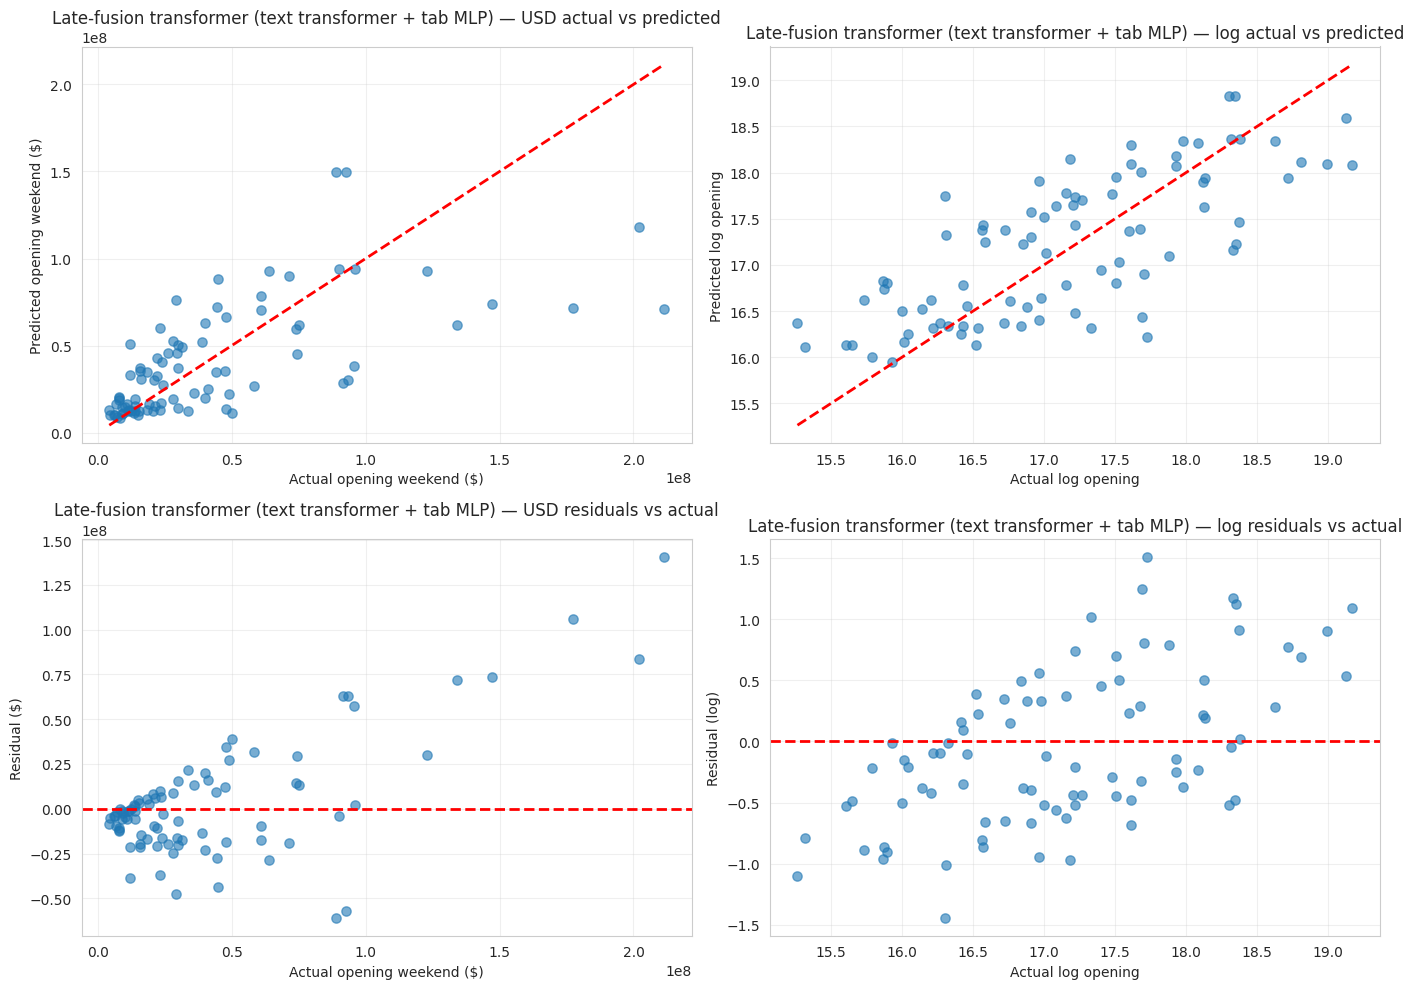


Top 15 worst predicted movies for Late-fusion transformer (text transformer + tab MLP) (sorted by abs_log_error)


,tmdb_id,title,release_date_us,distributor,genres,rating,youtube_id,actual_usd,pred_usd,resid_usd,abs_usd_error,pct_error,abs_pct_error,actual_log,pred_log,resid_log,abs_log_error,direction,release_year,month,day_of_week,runtime_min,rating_R,rating_PG_13,genre_drama,genre_adventure,yt_sent_std_early,yt_sent_mean_early,yt_comment_unique_ratio_early,yt_comment_exclamation_share_early,is_wednesday_release,is_christmas_corridor
0,1079091,It Ends with Us,2024-08-07,Sony,"Drama, Romance",PG-13,r-GQvSc5ZGw,50016652.0,11060039.0,38956612.0,38956612.0,-77.887283,77.887283,17.727867,16.218849,1.509018,1.509018,underpredicted,2024,8,2,131.0,0,1,1,0,0.626905,-0.260585,0.930189,0.089888,1,0
1,511987,Crawl,2019-07-10,Raimi Productions,"Horror, Thriller",R,H6MLJG0RdDE,12005210.0,50776428.0,-38771216.0,38771216.0,322.953247,322.953247,16.300852,17.742943,-1.442091,1.442091,overpredicted,2019,7,2,87.0,1,0,0,0,0.554431,-0.078501,1.000000,0.130435,1,0
2,1233413,Sinners,2025-04-16,Warner Bros,"Horror, Action, Thriller",R,0z8GC0VScco,48007468.0,13737951.0,34269516.0,34269516.0,-71.383720,71.383720,17.686867,16.435673,1.251194,1.251194,underpredicted,2025,4,2,138.0,1,0,0,0,0.358044,0.029899,1.000000,0.055556,1,0
3,420817,Aladdin,2019-05-22,Disney,"Adventure, Fantasy, Romance, Family",PG,JcMtWwiyzpU,91500928.0,28333174.0,63167752.0,63167752.0,-69.035095,69.035095,18.331860,17.159544,1.172316,1.172316,underpredicted,2019,5,2,127.0,0,0,0,1,0.000000,0.000000,0.000000,0.000000,1,0
4,1160164,TAYLOR SWIFT | THE ERAS TOUR,2023-10-13,Taylor Swift Productions,Music,PG-13,KudedLV0tP0,93224752.0,30391320.0,62833432.0,62833432.0,-67.399948,67.399948,18.350523,17.229668,1.120855,1.120855,underpredicted,2023,10,4,169.0,0,1,0,0,0.557075,0.563269,0.959677,0.270833,0,0
5,1325678,Sarah's Oil,2025-11-06,MGM/Amazon,Drama,PG,lcEOKJm_aLY,4261446.0,12832122.0,-8570676.0,8570676.0,201.121307,201.121307,15.265120,16.367462,-1.102343,1.102343,overpredicted,2025,11,3,103.0,0,0,1,0,0.725089,0.071836,0.997211,0.159420,0,0
6,533535,Deadpool & Wolverine,2024-07-24,Disney,"Action, Comedy, Science Fiction",R,cen0rBKLuYE,211435296.0,70876424.0,140558880.0,140558880.0,-66.478439,66.478439,19.169430,18.076448,1.092981,1.092981,underpredicted,2024,7,2,128.0,1,0,0,0,0.571752,0.304864,0.957132,0.138298,1,0
7,639720,IF,2024-05-08,Paramount,"Comedy, Fantasy, Family",PG,mb2187ZQtBE,33715800.0,12218390.0,21497410.0,21497410.0,-63.760643,63.760643,17.333477,16.318453,1.015024,1.015024,underpredicted,2024,5,2,104.0,0,0,0,0,0.599738,0.223428,0.977509,0.228916,1,0
8,877269,Strange World,2022-11-23,Disney,"Action, Adventure, Animation, Comedy, Family, Fantasy, Science Fiction",PG,bKh2G73gCCs,12151384.0,33374964.0,-21223580.0,21223580.0,174.659775,174.659775,16.312954,17.323317,-1.010363,1.010363,overpredicted,2022,11,2,102.0,0,0,0,1,0.000000,0.000000,0.000000,0.000000,1,0
9,290859,Terminator: Dark Fate,2019-10-23,20th Century,"Science Fiction, Action, Adventure, Thriller",R,oxy8udgWRmo,29033832.0,76449840.0,-47416008.0,47416008.0,163.312958,163.312958,17.183973,18.152145,-0.968172,0.968172,overpredicted,2019,10,2,128.0,1,0,0,1,0.548174,-0.192090,0.987711,0.083333,1,0


In [ ]:
transformer_results = collect_ensemble_results(
    models_list=transformer_fit["models"],
    X_train=late_fusion_eval_train_inputs,
    X_test=late_fusion_eval_test_inputs,
    y_train_true=y_opening_train,
    y_test_true=y_opening_test,
    y_train_log_true=y_opening_log_train,
    y_test_log_true=y_opening_log_test,
    y_log_mean=y_opening_mean,
    y_log_std=y_opening_std,
    clip_lo=clip_lo,
    clip_hi=clip_hi,
    model_name="Late-fusion transformer (text transformer + tab MLP, 3-seed ensemble)",
)

all_model_results = upsert_model_result(transformer_results)
print_detailed_results(transformer_results)

analyze_give_worst_N_transformer = plot_regression_diagnostics(
    transformer_results,
    y_opening_test,
    y_opening_log_test,
    "Late-fusion transformer (text transformer + tab MLP)",
    show_worst=True,
    top_n=15,
    sort_by="abs_log_error",
    df_test_meta=df_test_meta,
    df_test_key_features=df_test_key_features,
)

## 13. Modeling Approach 4 - XGBoost Benchmark (with Cross-Validation)

In [ ]:
# Tuned XGBoost benchmarks
# Change for priority #4:
# - DO NOT retune tab-only XGB anymore
# - KEEP a cheap tab-only XGB only for cell 59 feature-importance diagnostics
# - Only report / compare TEXT_ONLY and TAB_PLUS_TEXT

def opening_metrics_from_log_preds(y_true_usd, y_true_log, pred_log):
    pred_log = np.asarray(pred_log, dtype=np.float32)
    pred_log = np.clip(pred_log, clip_lo, clip_hi)
    pred_usd = np.maximum(0, np.expm1(pred_log))

    return {
        "mae_usd": mean_absolute_error(y_true_usd, pred_usd),
        "rmse_usd": np.sqrt(mean_squared_error(y_true_usd, pred_usd)),
        "r2_usd": r2_score(y_true_usd, pred_usd),
        "mae_log": mean_absolute_error(y_true_log, pred_log),
        "r2_log": r2_score(y_true_log, pred_log),
        "pred_usd": pred_usd,
        "pred_log": pred_log,
    }

def build_model_row(name, train_metrics, test_metrics):
    return {
        "model": name,
        "train_r2_log": train_metrics["r2_log"],
        "test_r2_log": test_metrics["r2_log"],
        "train_mae_log": train_metrics["mae_log"],
        "test_mae_log": test_metrics["mae_log"],
        "train_r2_usd": train_metrics["r2_usd"],
        "test_r2_usd": test_metrics["r2_usd"],
        "train_mae_usd": train_metrics["mae_usd"],
        "test_mae_usd": test_metrics["mae_usd"],
        "train_rmse_usd": train_metrics["rmse_usd"],
        "test_rmse_usd": test_metrics["rmse_usd"],
    }

def tune_xgb_on_train(
    X_train,
    y_train,
    label,
    param_distributions,
    n_iter=20,
    n_splits=5,
    random_state=42,
):
    if SPLIT_MODE == "time":
        cv = TimeSeriesSplit(n_splits=n_splits)
    else:
        cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    sampled_params = list(
        ParameterSampler(param_distributions, n_iter=n_iter, random_state=random_state)
    )
    rows = []

    for i, params in enumerate(sampled_params, start=1):
        fold_r2 = []
        fold_mae = []

        for tr_idx, va_idx in cv.split(X_train):
            model = XGBRegressor(
                objective="reg:squarederror",
                tree_method="hist",
                random_state=random_state,
                n_jobs=2,
                eval_metric="rmse",
                **params,
            )

            model.fit(
                X_train[tr_idx],
                y_train[tr_idx],
                verbose=False,
            )

            pred = model.predict(X_train[va_idx])
            fold_r2.append(r2_score(y_train[va_idx], pred))
            fold_mae.append(mean_absolute_error(y_train[va_idx], pred))

        row = dict(params)
        row["label"] = label
        row["cv_mean_r2_log"] = float(np.mean(fold_r2))
        row["cv_std_r2_log"] = float(np.std(fold_r2, ddof=1))
        row["cv_mean_mae_log"] = float(np.mean(fold_mae))
        row["cv_std_mae_log"] = float(np.std(fold_mae, ddof=1))
        rows.append(row)

    results_df = pd.DataFrame(rows).sort_values(
        by=["cv_mean_r2_log", "cv_mean_mae_log"],
        ascending=[False, True],
    ).reset_index(drop=True)

    print(f"\nTop tuning results for {label}:")
    display(results_df.head(10))

    best_row = results_df.iloc[0].to_dict()
    best_params = {k: best_row[k] for k in param_distributions.keys()}
    return best_params, results_df

# Feature sets
X_tab_train = X_tabular_train_scaled.astype(np.float32)
X_tab_test = X_tabular_test_scaled.astype(np.float32)

X_text_train = X_text_train_reduced.astype(np.float32)
X_text_test = X_text_test_reduced.astype(np.float32)

X_both_train = np.hstack([X_tab_train, X_text_train]).astype(np.float32)
X_both_test = np.hstack([X_tab_test, X_text_test]).astype(np.float32)

# Search space tuned for this dataset size
param_distributions = {
    "n_estimators": [80, 120, 160, 220, 300],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.02, 0.03, 0.05, 0.08],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.65, 0.80, 0.95],
    "colsample_bytree": [0.65, 0.80, 0.95],
    "reg_alpha": [0.0, 0.1, 0.3, 0.7],
    "reg_lambda": [1.0, 2.0, 4.0, 6.0],
    "gamma": [0.0, 0.1, 0.3],
}

if SPLIT_MODE == "time":
    train_order_for_cv = np.argsort(
        pd.to_datetime(df_train_meta["release_date_us"], errors="coerce")
        .fillna(pd.Timestamp("1900-01-01"))
        .to_numpy()
    )
    X_text_train_cv = X_text_train[train_order_for_cv]
    X_both_train_cv = X_both_train[train_order_for_cv]
    y_opening_log_train_cv = y_opening_log_train[train_order_for_cv]
else:
    X_text_train_cv = X_text_train
    X_both_train_cv = X_both_train
    y_opening_log_train_cv = y_opening_log_train

print("Retuning XGBoost on current training split only (TEXT_ONLY and TAB_PLUS_TEXT only)...")

# Keep only the promising XGB directions
best_text_params, text_tuning_df = tune_xgb_on_train(
    X_text_train_cv,
    y_opening_log_train_cv,
    "TEXT_ONLY",
    param_distributions,
    n_iter=20,
)

best_both_params, both_tuning_df = tune_xgb_on_train(
    X_both_train_cv,
    y_opening_log_train_cv,
    "TAB_PLUS_TEXT",
    param_distributions,
    n_iter=16,
)

print("\nBest params:")
print("TEXT_ONLY:", best_text_params)
print("TAB_PLUS_TEXT:", best_both_params)

# Cheap untuned tab-only XGB kept ONLY for feature importance in cell 59
xgb_tab_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=2,
    eval_metric="rmse",
    n_estimators=120,
    max_depth=2,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.3,
    reg_lambda=2.0,
    gamma=0.1,
)

xgb_text_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=2,
    eval_metric="rmse",
    **best_text_params,
)

xgb_both_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=2,
    eval_metric="rmse",
    **best_both_params,
)

# Fit models
xgb_tab_model.fit(X_tab_train, y_opening_log_train, verbose=False)   # diagnostics only
xgb_text_model.fit(X_text_train, y_opening_log_train, verbose=False)
xgb_both_model.fit(X_both_train, y_opening_log_train, verbose=False)

# Predict
xgb_tab_train_pred_log = xgb_tab_model.predict(X_tab_train)
xgb_tab_test_pred_log = xgb_tab_model.predict(X_tab_test)

xgb_text_train_pred_log = xgb_text_model.predict(X_text_train)
xgb_text_test_pred_log = xgb_text_model.predict(X_text_test)

xgb_both_train_pred_log = xgb_both_model.predict(X_both_train)
xgb_both_test_pred_log = xgb_both_model.predict(X_both_test)

# Metrics
xgb_tab_train_metrics = opening_metrics_from_log_preds(
    y_opening_train, y_opening_log_train, xgb_tab_train_pred_log
)
xgb_tab_test_metrics = opening_metrics_from_log_preds(
    y_opening_test, y_opening_log_test, xgb_tab_test_pred_log
)

xgb_text_train_metrics = opening_metrics_from_log_preds(
    y_opening_train, y_opening_log_train, xgb_text_train_pred_log
)
xgb_text_test_metrics = opening_metrics_from_log_preds(
    y_opening_test, y_opening_log_test, xgb_text_test_pred_log
)

xgb_both_train_metrics = opening_metrics_from_log_preds(
    y_opening_train, y_opening_log_train, xgb_both_train_pred_log
)
xgb_both_test_metrics = opening_metrics_from_log_preds(
    y_opening_test, y_opening_log_test, xgb_both_test_pred_log
)

# Only add promising XGB models to notebook-wide comparison
xgb_text_results = metrics_to_notebook_result(
    "XGB Text-Only Tuned",
    xgb_text_train_metrics,
    xgb_text_test_metrics,
)

xgb_both_results = metrics_to_notebook_result(
    "XGB Tab+Text Tuned",
    xgb_both_train_metrics,
    xgb_both_test_metrics,
)

for result in [xgb_text_results, xgb_both_results]:
    all_model_results = upsert_model_result(result)

xgb_df = pd.DataFrame([
    build_model_row("XGB Text-Only Tuned", xgb_text_train_metrics, xgb_text_test_metrics),
    build_model_row("XGB Tab+Text Tuned", xgb_both_train_metrics, xgb_both_test_metrics),
]).sort_values(
    by=["test_r2_log", "test_mae_log"],
    ascending=[False, True],
).reset_index(drop=True)

print("\nXGBOOST MODEL COMPARISON")
display(xgb_df)

print("\nTab-only XGB kept only for diagnostics / feature importance, not for final model comparison.")
print_detailed_results(xgb_both_results)

Retuning XGBoost on current training split only (TEXT_ONLY and TAB_PLUS_TEXT only)...

Top tuning results for TEXT_ONLY:


,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree,label,cv_mean_r2_log,cv_std_r2_log,cv_mean_mae_log,cv_std_mae_log
0,0.65,2.0,0.7,220,5,3,0.03,0.1,0.65,TEXT_ONLY,0.378409,0.086454,0.590424,0.020104
1,0.65,2.0,0.3,120,5,4,0.03,0.3,0.80,TEXT_ONLY,0.369263,0.085726,0.596287,0.016945
2,0.80,1.0,0.0,120,7,3,0.08,0.3,0.80,TEXT_ONLY,0.367208,0.097555,0.594370,0.021392
3,0.65,4.0,0.7,300,5,4,0.02,0.0,0.80,TEXT_ONLY,0.365633,0.099021,0.596554,0.028657
4,0.80,1.0,0.3,80,5,2,0.05,0.0,0.65,TEXT_ONLY,0.359745,0.084651,0.602162,0.019290
5,0.80,4.0,0.3,80,5,4,0.03,0.0,0.65,TEXT_ONLY,0.357980,0.065912,0.605141,0.018573
6,0.65,4.0,0.7,160,1,3,0.05,0.1,0.95,TEXT_ONLY,0.357153,0.102052,0.601269,0.026543
7,0.65,6.0,0.1,80,1,3,0.08,0.3,0.80,TEXT_ONLY,0.357011,0.084265,0.600847,0.022370
8,0.65,2.0,0.0,300,3,3,0.03,0.1,0.65,TEXT_ONLY,0.356741,0.092928,0.598570,0.018361
9,0.95,4.0,0.1,80,5,3,0.05,0.3,0.80,TEXT_ONLY,0.348479,0.079373,0.606009,0.020150



Top tuning results for TAB_PLUS_TEXT:


,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree,label,cv_mean_r2_log,cv_std_r2_log,cv_mean_mae_log,cv_std_mae_log
0,0.65,2.0,0.0,300,3,3,0.03,0.1,0.65,TAB_PLUS_TEXT,0.527725,0.080823,0.505984,0.043426
1,0.80,6.0,0.1,220,1,2,0.08,0.1,0.80,TAB_PLUS_TEXT,0.524884,0.065065,0.508787,0.037661
2,0.65,4.0,0.7,300,5,4,0.02,0.0,0.80,TAB_PLUS_TEXT,0.512014,0.062819,0.519673,0.033343
3,0.65,4.0,0.7,160,1,3,0.05,0.1,0.95,TAB_PLUS_TEXT,0.509325,0.062450,0.525946,0.037691
4,0.65,2.0,0.7,220,5,3,0.03,0.1,0.65,TAB_PLUS_TEXT,0.503054,0.062535,0.521320,0.034005
5,0.65,6.0,0.1,80,1,3,0.08,0.3,0.80,TAB_PLUS_TEXT,0.502508,0.070855,0.521848,0.036151
6,0.80,4.0,0.1,300,7,2,0.08,0.0,0.80,TAB_PLUS_TEXT,0.500283,0.078438,0.527438,0.038452
7,0.95,1.0,0.0,120,7,2,0.05,0.0,0.80,TAB_PLUS_TEXT,0.495160,0.063030,0.531104,0.027999
8,0.95,6.0,0.1,300,1,4,0.02,0.3,0.80,TAB_PLUS_TEXT,0.487995,0.059387,0.536196,0.043316
9,0.95,4.0,0.1,80,1,4,0.05,0.0,0.95,TAB_PLUS_TEXT,0.479945,0.028255,0.542840,0.037516



Best params:
TEXT_ONLY: {'n_estimators': 220, 'max_depth': 3, 'learning_rate': 0.03, 'min_child_weight': 5, 'subsample': 0.65, 'colsample_bytree': 0.65, 'reg_alpha': 0.7, 'reg_lambda': 2.0, 'gamma': 0.1}
TAB_PLUS_TEXT: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'min_child_weight': 3, 'subsample': 0.65, 'colsample_bytree': 0.65, 'reg_alpha': 0.0, 'reg_lambda': 2.0, 'gamma': 0.1}

XGBOOST MODEL COMPARISON


,model,train_r2_log,test_r2_log,train_mae_log,test_mae_log,train_r2_usd,test_r2_usd,train_mae_usd,test_mae_usd,train_rmse_usd,test_rmse_usd
0,XGB Tab+Text Tuned,0.955138,0.577097,0.151666,0.494968,0.922638,0.364815,6767834.5,20356180.0,1.295915e+07,3.420002e+07
1,XGB Text-Only Tuned,0.839710,0.404994,0.294102,0.571635,0.754242,0.263039,12481318.0,22303206.0,2.309755e+07,3.683821e+07



Tab-only XGB kept only for diagnostics / feature importance, not for final model comparison.
OPENING WEEKEND PREDICTION RESULTS - XGB TAB+TEXT TUNED

Original dollar space:
Mean Absolute Error:
  Train: $6,767,834
  Test:  $20,356,180

Root Mean Squared Error:
  Train: $12,959,150
  Test:  $34,200,021

R² Score:
  Train: 0.9226
  Test:  0.3648

Log space:
MAE:
  Train: 0.1517
  Test:  0.4950

R² Score:
  Train: 0.9551
  Test:  0.5771


## 14. Feature Importance Analysis



TABULAR FEATURE PREDICTIVE POWER


,feature,perm_importance_test_r2_mean,perm_importance_test_r2_std,mutual_info_train,abs_spearman_train,xgb_gain_importance,rank_score
0,runtime_min,0.246857,0.045922,0.196454,0.435046,0.037829,4.306345
1,is_four_quadrant_family_like,0.105915,0.026514,0.128753,0.407284,0.068189,3.079329
2,yt_comment_unique_ratio_early,0.042256,0.014587,0.079183,0.171427,0.017116,0.788901
3,is_sequel_proxy,0.039712,0.023816,0.047300,0.346953,0.037363,1.320991
4,yt_title_has_official,0.018926,0.003509,0.013677,0.196118,0.012100,0.143991
5,yt_sent_mean_early,0.015495,0.009629,0.000000,0.064320,0.012615,-0.276395
6,genre_scifi,0.011280,0.004051,0.008363,0.310164,0.012787,0.324870
7,rating_PG_13,0.007443,0.003518,0.061595,0.305698,0.019522,0.729471
8,genre_drama,0.005400,0.004869,0.005636,0.180698,0.013524,-0.038745
9,release_day,0.005204,0.002078,0.000000,0.045052,0.009504,-0.465041


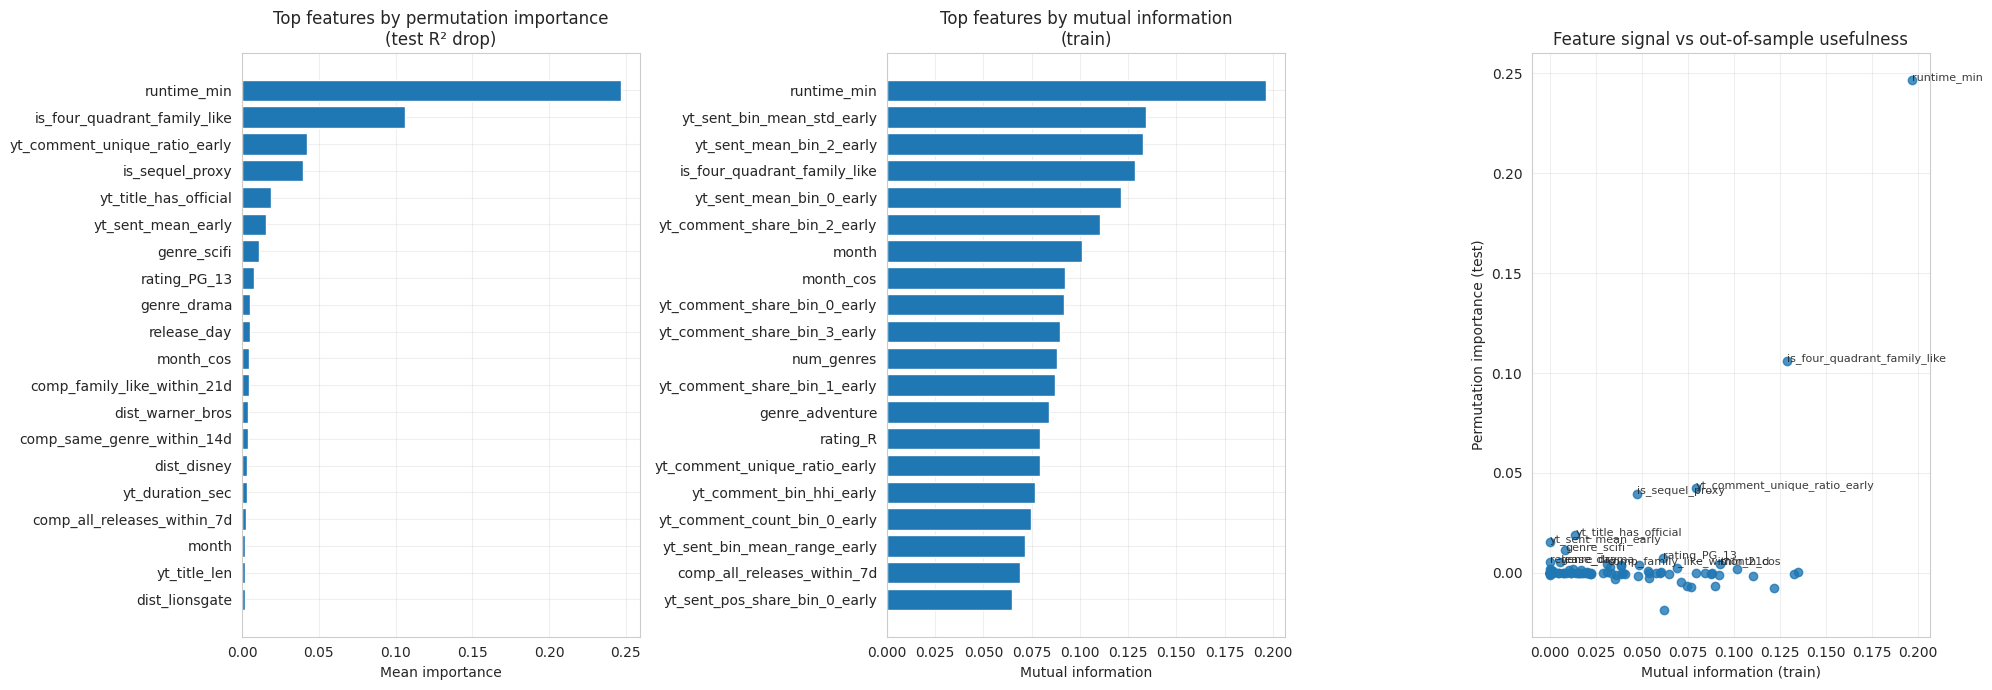


Features with positive out-of-sample permutation importance:


,feature,perm_importance_test_r2_mean,perm_importance_test_r2_std,mutual_info_train,abs_spearman_train,xgb_gain_importance,rank_score
0,runtime_min,0.246857,0.045922,0.196454,0.435046,0.037829,4.306345
1,is_four_quadrant_family_like,0.105915,0.026514,0.128753,0.407284,0.068189,3.079329
2,yt_comment_unique_ratio_early,0.042256,0.014587,0.079183,0.171427,0.017116,0.788901
3,is_sequel_proxy,0.039712,0.023816,0.047300,0.346953,0.037363,1.320991
4,yt_title_has_official,0.018926,0.003509,0.013677,0.196118,0.012100,0.143991
5,yt_sent_mean_early,0.015495,0.009629,0.000000,0.064320,0.012615,-0.276395
6,genre_scifi,0.011280,0.004051,0.008363,0.310164,0.012787,0.324870
7,rating_PG_13,0.007443,0.003518,0.061595,0.305698,0.019522,0.729471
8,genre_drama,0.005400,0.004869,0.005636,0.180698,0.013524,-0.038745
9,release_day,0.005204,0.002078,0.000000,0.045052,0.009504,-0.465041


In [ ]:
# Feature predictive power — tabular features only
# Add this RIGHT AFTER the tuned XGBoost comparison cell

# Safety checks
required_vars = [
    "all_tabular_cols",
    "X_tabular_train_scaled",
    "X_tabular_test_scaled",
    "y_opening_log_train",
    "y_opening_log_test",
    "xgb_tab_model",
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(f"Missing required variables: {missing_vars}")

feature_names = list(all_tabular_cols)

Xtr = np.asarray(X_tabular_train_scaled, dtype=np.float32)
Xte = np.asarray(X_tabular_test_scaled, dtype=np.float32)
ytr = np.asarray(y_opening_log_train, dtype=np.float32)
yte = np.asarray(y_opening_log_test, dtype=np.float32)

if Xtr.shape[1] != len(feature_names):
    raise ValueError(
        f"Feature-name mismatch: Xtr has {Xtr.shape[1]} columns but all_tabular_cols has {len(feature_names)} names"
    )

# 1) Univariate signal: absolute Spearman correlation on TRAIN
abs_spearman = []
for j in range(Xtr.shape[1]):
    try:
        rho, _ = spearmanr(Xtr[:, j], ytr)
        rho = 0.0 if rho is None or not np.isfinite(rho) else float(abs(rho))
    except Exception:
        rho = 0.0
    abs_spearman.append(rho)

# 2) Univariate non-linear signal: mutual information on TRAIN
try:
    mi = mutual_info_regression(
        Xtr,
        ytr,
        random_state=42,
        discrete_features=False,
    )
    mi = np.asarray(mi, dtype=np.float32)
except Exception:
    mi = np.zeros(Xtr.shape[1], dtype=np.float32)

# 3) Model-based importance from tuned XGBoost
# feature_importances_ is split/gain-like model importance
try:
    xgb_gain = np.asarray(xgb_tab_model.feature_importances_, dtype=np.float32)
except Exception:
    xgb_gain = np.zeros(Xtr.shape[1], dtype=np.float32)

# 4) Permutation importance on TEST (best for "what helps out-of-sample")
perm = permutation_importance(
    xgb_tab_model,
    Xte,
    yte,
    n_repeats=20,
    random_state=42,
    scoring="r2",
    n_jobs=1,
)

perm_mean = np.asarray(perm.importances_mean, dtype=np.float32)
perm_std = np.asarray(perm.importances_std, dtype=np.float32)

# Build results table
feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "abs_spearman_train": abs_spearman,
    "mutual_info_train": mi,
    "xgb_gain_importance": xgb_gain,
    "perm_importance_test_r2_mean": perm_mean,
    "perm_importance_test_r2_std": perm_std,
})

# Standardized ranking score
metric_cols = [
    "abs_spearman_train",
    "mutual_info_train",
    "xgb_gain_importance",
    "perm_importance_test_r2_mean",
]

for c in metric_cols:
    col = feat_imp_df[c].to_numpy(dtype=np.float32)
    if np.allclose(col.std(), 0):
        feat_imp_df[c + "_z"] = 0.0
    else:
        feat_imp_df[c + "_z"] = (col - col.mean()) / max(col.std(), 1e-8)

feat_imp_df["rank_score"] = feat_imp_df[[c + "_z" for c in metric_cols]].mean(axis=1)

feat_imp_df = feat_imp_df.sort_values(
    by=["perm_importance_test_r2_mean", "rank_score", "mutual_info_train"],
    ascending=[False, False, False]
).reset_index(drop=True)

top_n = min(20, len(feat_imp_df))
top_df = feat_imp_df.head(top_n).copy()

print("=" * 100)
print("TABULAR FEATURE PREDICTIVE POWER")
print("=" * 100)
display(
    feat_imp_df[[
        "feature",
        "perm_importance_test_r2_mean",
        "perm_importance_test_r2_std",
        "mutual_info_train",
        "abs_spearman_train",
        "xgb_gain_importance",
        "rank_score",
    ]].head(30)
)

# Nice visual
fig, axes = plt.subplots(1, 3, figsize=(20, max(6, top_n * 0.35)))

# Panel 1 — permutation importance on TEST
ypos = np.arange(top_n)
axes[0].barh(ypos, top_df["perm_importance_test_r2_mean"].values)
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(top_df["feature"].values)
axes[0].invert_yaxis()
axes[0].set_title("Top features by permutation importance\n(test R² drop)")
axes[0].set_xlabel("Mean importance")
axes[0].grid(True, alpha=0.3)

# Panel 2 — mutual information on TRAIN
top_df_mi = feat_imp_df.sort_values("mutual_info_train", ascending=False).head(top_n)
ypos2 = np.arange(len(top_df_mi))
axes[1].barh(ypos2, top_df_mi["mutual_info_train"].values)
axes[1].set_yticks(ypos2)
axes[1].set_yticklabels(top_df_mi["feature"].values)
axes[1].invert_yaxis()
axes[1].set_title("Top features by mutual information\n(train)")
axes[1].set_xlabel("Mutual information")
axes[1].grid(True, alpha=0.3)

# Panel 3 — scatter: MI vs permutation importance
axes[2].scatter(
    feat_imp_df["mutual_info_train"].values,
    feat_imp_df["perm_importance_test_r2_mean"].values,
    alpha=0.8
)
for _, row in feat_imp_df.head(12).iterrows():
    axes[2].annotate(
        row["feature"],
        (row["mutual_info_train"], row["perm_importance_test_r2_mean"]),
        fontsize=8,
        alpha=0.9
    )
axes[2].set_title("Feature signal vs out-of-sample usefulness")
axes[2].set_xlabel("Mutual information (train)")
axes[2].set_ylabel("Permutation importance (test)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: keep only positive permutation features
positive_perm_df = feat_imp_df[feat_imp_df["perm_importance_test_r2_mean"] > 0].copy()

print("\nFeatures with positive out-of-sample permutation importance:")
display(positive_perm_df[[
    "feature",
    "perm_importance_test_r2_mean",
    "perm_importance_test_r2_std",
    "mutual_info_train",
    "abs_spearman_train",
    "xgb_gain_importance",
    "rank_score",
]].head(30))

## 15. Best Model Selection

Compare all models and pick winner/runner-up based on primary ranking: test R^2 in log space. For tie-breakers: lower test MAE in log space, then higher test R^2 in $

In [ ]:

PRIMARY_SORT = "test_r2_log"   # main metric
SECONDARY_SORT = "test_mae_log"
TERTIARY_SORT = "test_r2"

def _safe_get(d, keys, default=np.nan):
    for k in keys:
        if isinstance(d, dict) and k in d and d[k] is not None:
            return d[k]
    return default

def _to_float(x):
    try:
        if x is None:
            return np.nan
        return float(x)
    except Exception:
        return np.nan

def extract_model_summary(result):
    """
    Tries to be robust to slightly different result dict shapes.
    """
    model_name = _safe_get(result, ["model_name", "name", "label"], default="UNKNOWN_MODEL")

    summary = {
        "model_name": model_name,

        # Dollar-space metrics
        "train_mae": _to_float(_safe_get(result, ["train_mae", "mae_train", "train_mae_usd"])),
        "test_mae": _to_float(_safe_get(result, ["test_mae", "mae_test", "test_mae_usd"])),
        "train_rmse": _to_float(_safe_get(result, ["train_rmse", "rmse_train", "train_rmse_usd"])),
        "test_rmse": _to_float(_safe_get(result, ["test_rmse", "rmse_test", "test_rmse_usd"])),
        "train_r2": _to_float(_safe_get(result, ["train_r2", "r2_train"])),
        "test_r2": _to_float(_safe_get(result, ["test_r2", "r2_test"])),

        # Log-space metrics
        "train_mae_log": _to_float(_safe_get(result, ["train_mae_log", "mae_log_train"])),
        "test_mae_log": _to_float(_safe_get(result, ["test_mae_log", "mae_log_test"])),
        "train_r2_log": _to_float(_safe_get(result, ["train_r2_log", "r2_log_train"])),
        "test_r2_log": _to_float(_safe_get(result, ["test_r2_log", "r2_log_test"])),
    }

    # Simple overfit diagnostics
    if not np.isnan(summary["train_r2_log"]) and not np.isnan(summary["test_r2_log"]):
        summary["gap_r2_log"] = summary["train_r2_log"] - summary["test_r2_log"]
    else:
        summary["gap_r2_log"] = np.nan

    if not np.isnan(summary["train_mae_log"]) and not np.isnan(summary["test_mae_log"]):
        summary["gap_mae_log"] = summary["test_mae_log"] - summary["train_mae_log"]
    else:
        summary["gap_mae_log"] = np.nan

    return summary

# Build comparison table
comparison_rows = [extract_model_summary(r) for r in all_model_results]
comparison_df = pd.DataFrame(comparison_rows)

# Remove duplicate model names, keep latest occurrence
comparison_df = comparison_df.drop_duplicates(subset=["model_name"], keep="last").reset_index(drop=True)

# Ranking:
# - higher test_r2_log is better
# - lower test_mae_log is better
# - higher test_r2 is better
comparison_ranked = comparison_df.sort_values(
    by=[PRIMARY_SORT, SECONDARY_SORT, TERTIARY_SORT],
    ascending=[False, True, False],
).reset_index(drop=True)

print("=== All model results ranked ===")
display(
    comparison_ranked[
        [
            "model_name",
            "test_r2_log",
            "test_mae_log",
            "test_r2",
            "test_mae",
            "train_r2_log",
            "gap_r2_log",
        ]
    ]
)

winner = comparison_ranked.iloc[0].to_dict() if len(comparison_ranked) >= 1 else None
runner_up = comparison_ranked.iloc[1].to_dict() if len(comparison_ranked) >= 2 else None

def format_money(x):
    if pd.isna(x):
        return "NA"
    return f"${x:,.0f}"

def format_num(x, digits=4):
    if pd.isna(x):
        return "NA"
    return f"{x:.{digits}f}"

def explain_choice(row, label):
    print(f"\n=== {label} ===")
    print(row["model_name"])
    print(f"  Test R² (log): {format_num(row['test_r2_log'])}")
    print(f"  Test MAE (log): {format_num(row['test_mae_log'])}")
    print(f"  Test R² ($):    {format_num(row['test_r2'])}")
    print(f"  Test MAE ($):   {format_money(row['test_mae'])}")
    print(f"  Train R² (log): {format_num(row['train_r2_log'])}")
    print(f"  Gap R² (log):   {format_num(row['gap_r2_log'])}")

if winner is not None:
    explain_choice(winner, "WINNER")

if runner_up is not None:
    explain_choice(runner_up, "RUNNER-UP")

# Short comparison reasoning
if winner is not None and runner_up is not None:
    print("\n=== Why winner beat runner-up ===")
    print(
        f"- Higher test R² (log): {format_num(winner['test_r2_log'])} vs {format_num(runner_up['test_r2_log'])}"
    )
    print(
        f"- Test MAE (log):       {format_num(winner['test_mae_log'])} vs {format_num(runner_up['test_mae_log'])}"
    )
    print(
        f"- Test R² ($):          {format_num(winner['test_r2'])} vs {format_num(runner_up['test_r2'])}"
    )

# Optional: best by dollar-space too
comparison_ranked_dollar = comparison_df.sort_values(
    by=["test_r2", "test_mae", "test_r2_log"],
    ascending=[False, True, False],
).reset_index(drop=True)

print("\n=== Best by dollar-space R² ===")
display(
    comparison_ranked_dollar[
        [
            "model_name",
            "test_r2",
            "test_mae",
            "test_r2_log",
            "test_mae_log",
        ]
    ].head(5)
)


=== All model results ranked ===


,model_name,test_r2_log,test_mae_log,test_r2,test_mae,train_r2_log,gap_r2_log
0,"ResNet-style tab+text NN (full current tab set, 3-seed ensemble)",0.586069,0.489028,0.548978,18793602.0,0.933751,0.347682
1,XGB Tab+Text Tuned,0.577097,0.494968,0.364815,20356180.0,0.955138,0.378041
2,"Late-fusion transformer (text transformer + tab MLP, 3-seed ensemble)",0.534528,0.531636,0.422995,21504842.0,0.840300,0.305772
3,Tiny Text-Only MLP (5-seed ensemble),0.469616,0.540232,0.375865,20561230.0,0.602117,0.132501
4,XGB Text-Only Tuned,0.404994,0.571635,0.263039,22303206.0,0.839710,0.434716



=== WINNER ===
ResNet-style tab+text NN (full current tab set, 3-seed ensemble)
  Test R² (log): 0.5861
  Test MAE (log): 0.4890
  Test R² ($):    0.5490
  Test MAE ($):   $18,793,602
  Train R² (log): 0.9338
  Gap R² (log):   0.3477

=== RUNNER-UP ===
XGB Tab+Text Tuned
  Test R² (log): 0.5771
  Test MAE (log): 0.4950
  Test R² ($):    0.3648
  Test MAE ($):   $20,356,180
  Train R² (log): 0.9551
  Gap R² (log):   0.3780

=== Why winner beat runner-up ===
- Higher test R² (log): 0.5861 vs 0.5771
- Test MAE (log):       0.4890 vs 0.4950
- Test R² ($):          0.5490 vs 0.3648

=== Best by dollar-space R² ===


,model_name,test_r2,test_mae,test_r2_log,test_mae_log
0,"ResNet-style tab+text NN (full current tab set, 3-seed ensemble)",0.548978,18793602.0,0.586069,0.489028
1,"Late-fusion transformer (text transformer + tab MLP, 3-seed ensemble)",0.422995,21504842.0,0.534528,0.531636
2,Tiny Text-Only MLP (5-seed ensemble),0.375865,20561230.0,0.469616,0.540232
3,XGB Tab+Text Tuned,0.364815,20356180.0,0.577097,0.494968
4,XGB Text-Only Tuned,0.263039,22303206.0,0.404994,0.571635


## 16. Summary and Next Steps

## Summary

This notebook predicts **U.S. domestic opening weekend gross** using a multimodal feature set built from:
- movie metadata,
- trailer/video metadata and text,
- YouTube comments,
- engineered social-signal features.

The main modeling setup in this final notebook is:
- **target**: U.S. domestic opening weekend,
- **primary split**: random split,
- **core setup excludes number of theaters** as a main feature,
- models evaluated mainly in **log space** (`R²_log`, `MAE_log`), with dollar-space metrics used as a secondary calibration check.

### Main findings

Data cleanup and better upstream feature quality mattered a lot. Performance improved materially after:
- tightening movie filtering and joins,
- using better trailer candidates,
- improving comment selection,
- adding title / franchise proxy features,
- adding comment-bin count / share / sentiment features.

These feature improvements were more important than most late-stage architecture tweaks.

### Final model ranking in the current notebook state

**1. ResNet-style tab+text neural model — final winner**
- Best saved configuration is in the region:
  - 2 residual blocks
  - width around 120
  - dropout around 0.15
  - L2 around `1.5e-3`
  - learning rate around `1.6e-4`
  - batch size = 8
  - no input noise
- Best current saved performance:
  - **Test R²_log ≈ 0.586**
  - **Test MAE_log ≈ 0.489**
- This is the strongest overall model in the notebook and the best final incumbent.

**2. XGBoost with tabular + text — strongest non-neural benchmark / runner-up**
- Best current saved performance:
  - **Test R²_log ≈ 0.577**
  - **Test MAE_log ≈ 0.495**
- XGB nearly matches ResNet in log-space ranking performance, which confirms that the engineered tabular and text features contain substantial signal.
- However, XGB is weaker in dollar-space calibration, suggesting it still struggles more on the largest openings.

**3. Late-fusion Transformer — best Transformer direction, but not final winner**
- The best meaningful Transformer direction was **late fusion**, where:
  - text/comment embeddings are processed in a Transformer-style branch,
  - compact tabular features go through a separate MLP branch,
  - branches are fused late.
- This architecture clearly outperformed the older scalar-tab tokenized Transformer family.
- Best current saved performance:
  - **Test R²_log ≈ 0.535**
  - **Test MAE_log ≈ 0.532**
- This is strong enough to keep as the main Transformer result, but it does not beat ResNet or XGB tab+text.

**4. Tiny text-only MLP — useful baseline**
- Best current saved performance:
  - **Test R²_log ≈ 0.470**
  - **Test MAE_log ≈ 0.540**
- This baseline is meaningfully better than a weak text-only toy model and shows that the text pipeline alone is already informative.
- Still, multimodal models materially outperform it.

### Architecture conclusions

The notebook supports the following conclusions:

- **ResNet-style tab+text** is the best overall modeling direction for this project.
- **Late-fusion Transformer** is the only Transformer family worth keeping.
- The older **scalar-tab tokenized Transformer** should be considered deprecated.
- Moderate regularization worked better than aggressive regularization.
- Reducing capacity generally hurt performance.
- Batch size mattered for ResNet: **8** consistently worked better than 12 or 16.
- Grouped / tokenized tabular preprocessing for Transformer models underperformed simpler compact scalar-tab branches.

### What the errors and residuals suggest

The remaining modeling errors are concentrated in unusually hard movies, especially:
- very large franchise / event-style releases,
- movies whose social signal is sparse, misleading, or structurally different from normal releases.

This suggests the remaining gap is driven more by:
- imperfect **franchise / eventness / mass-awareness** proxies,
- and top-end calibration,
than by missing broad hyperparameter search.

### Reporting interpretation

The most trustworthy final interpretation is:

- the project successfully built a multimodal opening-weekend predictor without using theater count as a core feature,
- feature quality and feature engineering drove a large share of the gains,
- the best final model is a **ResNet-style multimodal regressor**,
- **XGB tab+text** is a strong benchmark and validates the feature set,
- **late-fusion Transformer** improved substantially over older Transformer approaches but did not become the final winner.

## Next Steps

This notebook is being frozen in its current state, so the goal of next steps is not broad new experimentation. The priority is to document the final result cleanly and preserve only the highest-value follow-on work.

### Immediate wrap-up actions

1. **Freeze the primary benchmark definition**
   - Primary benchmark should remain:
     - random split,
     - opening weekend target,
     - no theater count in the core main-feature setup,
     - no extra outlier filtering beyond standard data cleanup.
   - Any filtered benchmark should be presented separately as a sensitivity analysis, not as the main score.

2. **Freeze the final model lineup**
   - Keep:
     - Tiny text-only baseline
     - ResNet tab+text winner
     - XGB tab+text benchmark
     - Late-fusion Transformer as the only Transformer result worth reporting
   - Deprecate:
     - old scalar-tab tokenized Transformer branch
     - stale comparison outputs from older intermediate runs
     - redundant experimental branches that no longer affect the conclusion

3. **Write the final report around the correct story**
   - The main contribution is not just “trying many models.”
   - The main contribution is:
     - building a useful multimodal dataset,
     - cleaning and aligning the data carefully,
     - engineering stronger social and franchise-related features,
     - showing that these features materially improve opening-weekend prediction,
     - and demonstrating that a ResNet-style multimodal model performs best under the project constraints.

### Highest-value technical follow-up, if any future work is done

If this project were extended after the freeze, the most valuable next work would be narrow and targeted:

**1. Improve event / franchise / blockbuster calibration**
- The biggest remaining gap appears to be underprediction or unstable calibration on unusually large openings.
- Future feature work should focus on stronger proxies for:
  - franchise intensity,
  - event-film behavior,
  - cultural awareness,
  - pre-release momentum quality.

**2. Keep Transformer work limited to late-fusion only**
- Do not return to scalar-tab tokenized Transformer variants.
- If Transformer work continues, it should stay within the late-fusion design family.

**3. Use filtered analysis only as sensitivity analysis**
- A filtered benchmark can still be useful for showing how much extreme outliers affect performance.
- However, those results should remain clearly labeled as sensitivity checks and not replace the main benchmark.

### Final project takeaways

The final frozen conclusion of the notebook is:

- multimodal prediction of opening weekend is feasible without relying on theater count as the main feature,
- feature quality and data preparation had first-order impact,
- engineered social and title/franchise features materially improved results,
- ResNet tab+text is the strongest final model,
- XGB tab+text is the strongest non-neural benchmark,
- late-fusion Transformer is the only Transformer direction that remains worth mentioning,
- and the remaining errors are concentrated in structurally difficult blockbuster / event-like cases rather than in a simple lack of model complexity.

### Suggested final presentation order

For slides, report, or class discussion, present results in this order:
1. problem and benchmark definition,
2. data sources and feature groups,
3. main feature engineering improvements,
4. baseline text-only result,
5. XGB tab+text benchmark,
6. ResNet tab+text final winner,
7. late-fusion Transformer as secondary architecture,
8. residual analysis and outlier sensitivity,
9. final conclusion and future work.